# LẤY DỮ LIỆU VÀ CHUẨN BỊ

In [112]:
# pip install matplotlib

In [113]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [114]:
# from google.colab import drive
# drive.mount('/content/drive')

# file_path = "/content/drive/MyDrive/Colab Notebooks/DM/csv/en.openfoodfacts.org.products.csv.gz"



In [115]:
file_path = "en.openfoodfacts.org.products.csv.gz"


In [116]:
import pandas as pd


# Chỉ đọc thử 5 dòng đầu tiên để kiểm tra
df = pd.read_csv(file_path, compression='gzip', sep='\t', nrows=5)

print("✅ File đọc được, số cột:", len(df.columns))
# print(df.head())
print(df.columns.tolist())
print(df)


✅ File đọc được, số cột: 211
['code', 'url', 'creator', 'created_t', 'created_datetime', 'last_modified_t', 'last_modified_datetime', 'last_modified_by', 'last_updated_t', 'last_updated_datetime', 'product_name', 'abbreviated_product_name', 'generic_name', 'quantity', 'packaging', 'packaging_tags', 'packaging_en', 'packaging_text', 'brands', 'brands_tags', 'brands_en', 'categories', 'categories_tags', 'categories_en', 'origins', 'origins_tags', 'origins_en', 'manufacturing_places', 'manufacturing_places_tags', 'labels', 'labels_tags', 'labels_en', 'emb_codes', 'emb_codes_tags', 'first_packaging_code_geo', 'cities', 'cities_tags', 'purchase_places', 'stores', 'countries', 'countries_tags', 'countries_en', 'ingredients_text', 'ingredients_tags', 'ingredients_analysis_tags', 'allergens', 'allergens_en', 'traces', 'traces_tags', 'traces_en', 'serving_size', 'serving_quantity', 'no_nutrition_data', 'additives_n', 'additives', 'additives_tags', 'additives_en', 'nutriscore_score', 'nutriscore

In [117]:
df['completeness']

0    0.1625
1    0.6625
2    0.4750
3    0.1625
4    0.6750
Name: completeness, dtype: float64

#### Lựa chọn các cột dữ liệu sử dụng:
- code: Mã sản phẩm duy nhất
- categories_en: Danh mục sản phẩm
- labels_en: Nhãn đặc biệt (organic, fair trade, halal...)
- countries_en: Quốc gia có mua bán sản phẩm
- additives_n: Số lượng chất phụ gia
- nutriscore_score: Điểm Nutriscore bằng số, càng thấp càng tốt (Các chất có hại - Các chất có lợi)
- nutriscore_grade: Xếp hạng Nutriscore (A -> E)
- nova_group: Mức đô chế biến (1: Ít chế biến -> 4: Chế biến nhiều)
- food_groups_en: Nhóm thực phẩm chính
- unique_scans_n: Số lần người dùng quét mã sản phẩm -> Mức độ phổ biến sản phẩm
- completenss: Tỉ lệ hoàn thiện dữ liệu
Trong các nhóm thành phần dinh dưỡng cụ thể, nhóm tiến hành lựa chọn ra các thành phần dinh dưỡng chính (loại trừ các thành phần vi dinh dưỡng) theo tiêu chuẩn quốc tế, trong đó bao gồm các thành phần dinh dưỡng sau:
- energy_100g: Tổng năng lượng chất béo có trong 100g thực phẩm
- fat_100g: Tổng lượng chất béo có trong 100g thực phẩm
- saturated-fat_100g: Tổng lượng chất béo bão hòa có trong 100g thực phẩm
- carbohydrates_100g: Tổng lượng carbohydrates có trong 100g thực phẩm
- sugars_100g: Tổng lượng đường có trong 100g thực phẩm
- proteins_100g: Tổng lượng proteins trong 100g thực phẩm
- salts_100g: Tổng lượng muối trong 100g thực phẩm
- fiber_100g: Tổng lượng chất xơ trong 100g thực phẩm


In [118]:
import pandas as pd



count_fr = 0

for chunk in pd.read_csv(
    file_path,
    sep="\t",
    compression="gzip",
    usecols=["countries_en"],
    chunksize=200_000,
    low_memory=False
):
    count_fr += chunk["countries_en"].str.contains(
        "France", na=False
    ).sum()

print("Number of products in France:", count_fr)

Number of products in France: 1261274


In [119]:
count_us = 0

for chunk in pd.read_csv(
    file_path,
    sep="\t",
    compression="gzip",
    usecols=["countries_en"],
    chunksize=200_000,
    low_memory=False
):
    count_us += chunk["countries_en"].str.contains(
        "United States", na=False
    ).sum()

print("Number of products in USA:", count_us)

Number of products in USA: 911302


In [120]:


selected_columns = [
'code','categories_en','labels_en','countries_en','additives_n','nutriscore_score','nutriscore_grade','nova_group','food_groups_en','unique_scans_n','completeness','energy_100g','fat_100g','saturated-fat_100g','carbohydrates_100g','sugars_100g','proteins_100g','salts_100g','fiber_100g']
target_countries = ["France", "United States"]

chunk_size = 200_000

# =========================
# 2. LOAD + LỌC COUNTRY
# =========================

chunks = []

for chunk in pd.read_csv(
    file_path,
    sep="\t",
    compression="gzip",
    usecols=lambda c: c in selected_columns,
    chunksize=chunk_size,
    low_memory=False
):
    mask = chunk["countries_en"].apply(
        lambda x: any(c in x for c in target_countries)
        if pd.notna(x) else False
    )

    filtered = chunk[mask]
    chunks.append(filtered)

    # Có thể giới hạn tổng số dòng để tránh quá lớn
    if sum(len(c) for c in chunks) >= 1_700_000:
        break

df = pd.concat(chunks, ignore_index=True)

print("Dataframe 2 quốc gia France và United States:", df.shape)

# =========================
# 3. TÁCH RIÊNG THEO COUNTRY
# =========================

df_fr = df[df["countries_en"].str.contains("France", na=False)]
df_us = df[df["countries_en"].str.contains("United States", na=False)]

print("France:", len(df_fr))
print("United States:", len(df_us))

# =========================
# 4. CÂN BẰNG SỐ DÒNG
# =========================

# Lấy số nhỏ nhất làm mốc
n_target = min(len(df_fr), len(df_us))


df_fr_bal = df_fr.sample(n=n_target, random_state=42)
df_us_bal = df_us.sample(n=n_target, random_state=42)

df_balanced = pd.concat(
    [df_fr_bal, df_us_bal],
    ignore_index=True
)

print("Dataframe 2 quốc gia France và United States được cân bằng:", df_balanced.shape)

# =========================
# 5. KIỂM TRA LẠI PHÂN BỐ
# =========================

for c in target_countries:
    print(
        c,
        df_balanced["countries_en"].str.contains(c, na=False).sum()
    )



Dataframe 2 quốc gia France và United States: (1719500, 18)
France: 921389
United States: 802734
Dataframe 2 quốc gia France và United States được cân bằng: (1605468, 18)
France 807357
United States 806744


In [121]:
# print(df_balanced['salts_100g'])

In [122]:
# =========================
# 6. LƯU DATASET CUỐI
# =========================

df_balanced.to_csv(
    "openfoodfacts_fr_us_final.csv",
    index=False
)


In [123]:
df_balanced.info()

<class 'pandas.DataFrame'>
RangeIndex: 1605468 entries, 0 to 1605467
Data columns (total 18 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   code                1605468 non-null  object 
 1   categories_en       804190 non-null   str    
 2   labels_en           470101 non-null   str    
 3   countries_en        1605468 non-null  str    
 4   additives_n         645323 non-null   object 
 5   nutriscore_score    650841 non-null   object 
 6   nutriscore_grade    1587659 non-null  str    
 7   nova_group          593710 non-null   object 
 8   food_groups_en      630308 non-null   str    
 9   unique_scans_n      469093 non-null   object 
 10  completeness        1605434 non-null  object 
 11  energy_100g         633822 non-null   object 
 12  fat_100g            628494 non-null   object 
 13  saturated-fat_100g  620858 non-null   object 
 14  carbohydrates_100g  628468 non-null   float64
 15  sugars_100g         623747

In [124]:
df_balanced.iloc[0:,]

,code,categories_en,labels_en,countries_en,additives_n,nutriscore_score,nutriscore_grade,nova_group,food_groups_en,unique_scans_n,completeness,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g
0,3760250740312,"Beverages,Alcoholic beverages,Beers,Artisan pr...","Not advised for specific people,Not advised fo...",France,0.0,NaN,not-applicable,3.0,Alcoholic beverages,NaN,0.8875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3608580793359,"Plant-based foods and beverages,Plant-based fo...",NaN,France,1,17,d,4,"Sugary snacks,Sweets",3,0.7875,1012.6,0.1,0.1,58.000000,58.000000,1.800000,0.500000
2,3329480012424,"Plant-based foods and beverages,Plant-based fo...","Organic,EU Organic,AB Agriculture Biologique",France,NaN,-7.0,a,NaN,"Cereals and potatoes,Cereals",NaN,0.5875,1411.7,1.8,0.3,63.600000,2.100000,11.100000,10.300000
3,3481291022815,NaN,Made in France,France,NaN,NaN,unknown,NaN,NaN,NaN,0.075,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3701091702138,NaN,"Organic,EU Organic,FR-BIO-01,AB Agriculture Bi...",France,NaN,NaN,unknown,NaN,NaN,1,0.3625,698.2,2.1,0.5,30.300000,0.500000,NaN,6.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605463,70152400027,Salted-snacks,NaN,United States,4.0,16.0,d,4.0,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1605464,83703701566,NaN,Source of fibre,United States,NaN,NaN,unknown,NaN,NaN,NaN,0.275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1605465,36800467156,Frozen foods,No artificial flavors,United States,4.0,7.0,c,4.0,NaN,NaN,0.475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1605466,850013947027,NaN,NaN,United States,NaN,NaN,unknown,NaN,NaN,NaN,0.1625,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Kiểm tra và chuyển đổi kiểu các đặc trưng số

In [125]:
df_balanced['additives_n'] = pd.to_numeric(df_balanced['additives_n'], errors='coerce') ### gặp DL không chuyển thành float được thì chuyển sang NaN
df_balanced['additives_n'] = df_balanced['additives_n'].astype(float)

In [126]:
df_balanced['nutriscore_score'] = pd.to_numeric(df_balanced['nutriscore_score'], errors='coerce')
df_balanced['nutriscore_score'] = df_balanced['nutriscore_score'].astype(float)

In [127]:
df_balanced['nova_group'] = pd.to_numeric(df_balanced['nova_group'], errors='coerce')
df_balanced['nova_group'] = df_balanced['nova_group'].astype(float)

In [128]:
df_balanced['unique_scans_n'] = pd.to_numeric(df_balanced['unique_scans_n'], errors='coerce')
df_balanced['unique_scans_n'] = df_balanced['unique_scans_n'].astype(float)

In [129]:
df_balanced['completeness'] = pd.to_numeric(df_balanced['completeness'], errors='coerce')
df_balanced['completeness'] = df_balanced['completeness'].astype(float)

In [130]:
df_balanced['energy_100g'] = pd.to_numeric(df_balanced['energy_100g'], errors='coerce')
df_balanced['energy_100g'] = df_balanced['energy_100g'].astype(float)

In [131]:
df_balanced['fat_100g'] = pd.to_numeric(df_balanced['fat_100g'], errors='coerce')
df_balanced['fat_100g'] = df_balanced['fat_100g'].astype(float)

In [132]:
df_balanced['saturated-fat_100g'] = pd.to_numeric(df_balanced['saturated-fat_100g'], errors='coerce')
df_balanced['saturated-fat_100g'] = df_balanced['saturated-fat_100g'].astype(float)

In [133]:
df_balanced.info()

<class 'pandas.DataFrame'>
RangeIndex: 1605468 entries, 0 to 1605467
Data columns (total 18 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   code                1605468 non-null  object 
 1   categories_en       804190 non-null   str    
 2   labels_en           470101 non-null   str    
 3   countries_en        1605468 non-null  str    
 4   additives_n         645322 non-null   float64
 5   nutriscore_score    650840 non-null   float64
 6   nutriscore_grade    1587659 non-null  str    
 7   nova_group          593709 non-null   float64
 8   food_groups_en      630308 non-null   str    
 9   unique_scans_n      469092 non-null   float64
 10  completeness        1605433 non-null  float64
 11  energy_100g         633821 non-null   float64
 12  fat_100g            628493 non-null   float64
 13  saturated-fat_100g  620857 non-null   float64
 14  carbohydrates_100g  628468 non-null   float64
 15  sugars_100g         623747

### Rút gọn danh mục sản phẩm

In [134]:
import re

In [135]:
# Tách chuỗi thành danh sách
df_balanced['categories_list'] = df_balanced['categories_en'].fillna('').str.split(', ')

# Lấy danh mục tổng quát nhất
df_balanced['main_category_raw'] = df_balanced['categories_list'].apply(lambda x: x[0] if len(x) > 0 and x[0] != '' else None)


### Một loại sản phẩm được người dùng nhập thủ công nên xếp vào nhiều danh mục tuy nhiên khá chi tiết và không được tổng quát. Nhóm nghiên cứu đề xuất lựa chọn danh mục được nhập vào đầu tiên (tổng quát nhất) để chọn làm danh mục phân loại chính của sản phẩm

In [136]:
df_balanced['main_category_raw'].unique()

<StringArray>
[                                                                                                            'Beverages,Alcoholic beverages,Beers,Artisan products,Country specific beers,Artisanal spirits,French beers,Amber beers,Craft beers',
    'Plant-based foods and beverages,Plant-based foods,Fruits and vegetables based foods,Breakfasts,Spreads,Fruits based foods,Plant-based spreads,Sweet spreads,Fruit and vegetable preserves,Jams,Berry jams,Mixed fruit jams,Mixed berry jams',
                                                                                                    'Plant-based foods and beverages,Plant-based foods,Cereals and potatoes,Seeds,Cereals and their products,Cereal grains,Barley,Pearled barley',
                                                                                                                                                                                                                                              nan,
              

In [137]:
def map_to_general_category(text):
    if not text:
        return 'Other'


    categories = [c.strip().lower() for c in text.split(',')]


    mapping_rules = {
        'snack': ['snack', 'chip', 'crisp'],
        'drink': ['drink', 'beverage', 'soda', 'water', 'juice', 'tea'],
        'dairy': ['milk', 'cheese', 'dairy', 'fermented', 'cream', 'dairies'],
        'green product': ['fruit', 'vegetable', 'salad', 'green', 'potato'],
        'bakery and sweets': ['biscuit', 'cake', 'pastry', 'chocolate', 'cocoa', 'baking', 'syrup', 'desserts', 'sugar', 'pie', 'candies', 'cracker', 'sweet'],
        'condiment': ['condiment', 'sauce', 'spice', 'additives', 'sweeten'],
        'meat and fish': ['meat', 'fish', 'seafood', 'poultry', 'beef', 'chicken', 'egg', 'fresh', 'duck', 'animal', 'pork'],
        'breakfast and starch': ['cereal', 'breakfast', 'grain', 'pasta', 'rice', 'crepe', 'sandwich', 'hamburger', 'soup'],
        'baby food': ['baby', 'infant'],
        'frozen food': ['frozen'],
        'canned food': ['canned']
    }


    for group, keywords in mapping_rules.items():
        # Kiểm tra xem có bất kỳ từ khóa nào nằm trong các category đã tách không
        # Dùng any() lồng nhau để tối ưu tốc độ
        if any(any(k in c for k in keywords) for c in categories):
            return group

    return 'Other'



In [138]:

print(map_to_general_category("  BEVERAGE , Juice"))
print(map_to_general_category("potato chips"))
print(map_to_general_category("boiled pork"))


drink
snack
meat and fish


In [139]:
df_balanced['general_category'] = df_balanced['main_category_raw'].fillna('').astype(str).apply(map_to_general_category)

df_balanced['general_category'].value_counts()

general_category
Other                   875117
drink                   256388
snack                   166008
meat and fish           112692
dairy                    75169
bakery and sweets        43181
condiment                42696
breakfast and starch     14019
green product            10697
frozen food               7955
baby food                 1344
canned food                202
Name: count, dtype: int64

In [140]:
other_categories = (
    df_balanced[df_balanced['general_category'] == 'Other']
    ['main_category_raw']
    .value_counts()
    .head(10)
    # .unique()
)

other_categories


main_category_raw
Undefined                                                       34685
Dietary supplements                                              4276
Meals                                                            2645
Toppings-ingredients                                             2417
Dietary supplements,Bodybuilding supplements,Protein powders     1714
Cooking helpers                                                  1358
Entrees                                                          1309
Null                                                             1189
Fats                                                             1146
Mexican-dinner-mixes                                              867
Name: count, dtype: int64

#### Kiểm tra sơ qua nhận thấy các giá trị còn lại trong Others khá bao quát hoặc thuộc về các thực phẩm bổ sung,... khó để phân vào các loại chính và không cần thiết cho mục tiêu phân tích nhóm thực phẩm phổ biến của đồ án
#### => Để tránh phân nhóm nhầm và đảm bảo độ chính xác cho dữ liệu, loại bỏ Others để tránh mất cân bằng dữ liệu của dataset

In [141]:
df_categorize = df_balanced[df_balanced['general_category'] != 'Other'].copy()

In [142]:
df_categorize

,code,categories_en,labels_en,countries_en,additives_n,nutriscore_score,nutriscore_grade,nova_group,food_groups_en,unique_scans_n,...,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,categories_list,main_category_raw,general_category
0,3760250740312,"Beverages,Alcoholic beverages,Beers,Artisan pr...","Not advised for specific people,Not advised fo...",France,0.0,NaN,not-applicable,3.0,Alcoholic beverages,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Beverages,Alcoholic beverages,Beers,Artisan p...","Beverages,Alcoholic beverages,Beers,Artisan pr...",drink
1,3608580793359,"Plant-based foods and beverages,Plant-based fo...",NaN,France,1.0,17.0,d,4.0,"Sugary snacks,Sweets",3.0,...,1012.60,0.10,0.100000,58.000000,58.0,1.8,0.500000,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
2,3329480012424,"Plant-based foods and beverages,Plant-based fo...","Organic,EU Organic,AB Agriculture Biologique",France,NaN,-7.0,a,NaN,"Cereals and potatoes,Cereals",NaN,...,1411.70,1.80,0.300000,63.600000,2.1,11.1,10.300000,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
5,3596710437139,"Plant-based foods and beverages,Plant-based fo...",NaN,France,0.0,-4.0,a,1.0,"Cereals and potatoes,Cereals",4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
7,20240028,"Plant-based foods and beverages,Plant-based fo...","Organic,EU Organic,ES-ECO-002-AN,ES-ECO-003-AN...",France,0.0,NaN,unknown,NaN,"Fruits and vegetables,Vegetables",2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605457,687456225067,"Plant-based foods and beverages,Plant-based fo...","Organic,USDA Organic,No nuts",United States,0.0,NaN,unknown,4.0,"Cereals and potatoes,Breakfast cereals",NaN,...,1968.75,18.75,4.166667,66.666667,25.0,NaN,8.333333,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
1605459,17077317061,"Dairies,Fermented foods,Fermented milk product...",Organic,United States,2.0,-3.0,a,4.0,"Milk and dairy products,Cheese",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Dairies,Fermented foods,Fermented milk produc...","Dairies,Fermented foods,Fermented milk product...",dairy
1605461,31506689307,"Meats and their products,Prepared meats",NaN,United States,0.0,34.0,e,4.0,"Fish‚ Meat‚ Eggs,Processed meat",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Meats and their products,Prepared meats]","Meats and their products,Prepared meats",meat and fish
1605463,70152400027,Salted-snacks,NaN,United States,4.0,16.0,d,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Salted-snacks],Salted-snacks,snack


In [143]:
df_categorize.info()

<class 'pandas.DataFrame'>
Index: 730351 entries, 0 to 1605465
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   code                730351 non-null  object 
 1   categories_en       730351 non-null  str    
 2   labels_en           282150 non-null  str    
 3   countries_en        730351 non-null  str    
 4   additives_n         501188 non-null  float64
 5   nutriscore_score    593548 non-null  float64
 6   nutriscore_grade    730324 non-null  str    
 7   nova_group          488467 non-null  float64
 8   food_groups_en      621892 non-null  str    
 9   unique_scans_n      308244 non-null  float64
 10  completeness        730335 non-null  float64
 11  energy_100g         359934 non-null  float64
 12  fat_100g            357938 non-null  float64
 13  saturated-fat_100g  354898 non-null  float64
 14  carbohydrates_100g  357586 non-null  float64
 15  sugars_100g         356519 non-null  float64
 16 

In [144]:
#Reset lại index
df_categorize = df_categorize.reset_index(drop=True)
df_categorize

,code,categories_en,labels_en,countries_en,additives_n,nutriscore_score,nutriscore_grade,nova_group,food_groups_en,unique_scans_n,...,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,categories_list,main_category_raw,general_category
0,3760250740312,"Beverages,Alcoholic beverages,Beers,Artisan pr...","Not advised for specific people,Not advised fo...",France,0.0,NaN,not-applicable,3.0,Alcoholic beverages,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Beverages,Alcoholic beverages,Beers,Artisan p...","Beverages,Alcoholic beverages,Beers,Artisan pr...",drink
1,3608580793359,"Plant-based foods and beverages,Plant-based fo...",NaN,France,1.0,17.0,d,4.0,"Sugary snacks,Sweets",3.0,...,1012.60,0.10,0.100000,58.000000,58.0,1.8,0.500000,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
2,3329480012424,"Plant-based foods and beverages,Plant-based fo...","Organic,EU Organic,AB Agriculture Biologique",France,NaN,-7.0,a,NaN,"Cereals and potatoes,Cereals",NaN,...,1411.70,1.80,0.300000,63.600000,2.1,11.1,10.300000,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
3,3596710437139,"Plant-based foods and beverages,Plant-based fo...",NaN,France,0.0,-4.0,a,1.0,"Cereals and potatoes,Cereals",4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
4,20240028,"Plant-based foods and beverages,Plant-based fo...","Organic,EU Organic,ES-ECO-002-AN,ES-ECO-003-AN...",France,0.0,NaN,unknown,NaN,"Fruits and vegetables,Vegetables",2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730346,687456225067,"Plant-based foods and beverages,Plant-based fo...","Organic,USDA Organic,No nuts",United States,0.0,NaN,unknown,4.0,"Cereals and potatoes,Breakfast cereals",NaN,...,1968.75,18.75,4.166667,66.666667,25.0,NaN,8.333333,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
730347,17077317061,"Dairies,Fermented foods,Fermented milk product...",Organic,United States,2.0,-3.0,a,4.0,"Milk and dairy products,Cheese",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Dairies,Fermented foods,Fermented milk produc...","Dairies,Fermented foods,Fermented milk product...",dairy
730348,31506689307,"Meats and their products,Prepared meats",NaN,United States,0.0,34.0,e,4.0,"Fish‚ Meat‚ Eggs,Processed meat",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Meats and their products,Prepared meats]","Meats and their products,Prepared meats",meat and fish
730349,70152400027,Salted-snacks,NaN,United States,4.0,16.0,d,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Salted-snacks],Salted-snacks,snack


#### Biến label_en không có ý nghĩa và không cần thiết cho các mục tiêu phân tích của đề tài => loại bỏ

In [145]:
df_categorize = df_categorize.drop('labels_en', axis=1)

In [146]:
df_categorize

,code,categories_en,countries_en,additives_n,nutriscore_score,nutriscore_grade,nova_group,food_groups_en,unique_scans_n,completeness,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,categories_list,main_category_raw,general_category
0,3760250740312,"Beverages,Alcoholic beverages,Beers,Artisan pr...",France,0.0,NaN,not-applicable,3.0,Alcoholic beverages,NaN,0.8875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Beverages,Alcoholic beverages,Beers,Artisan p...","Beverages,Alcoholic beverages,Beers,Artisan pr...",drink
1,3608580793359,"Plant-based foods and beverages,Plant-based fo...",France,1.0,17.0,d,4.0,"Sugary snacks,Sweets",3.0,0.7875,1012.60,0.10,0.100000,58.000000,58.0,1.8,0.500000,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
2,3329480012424,"Plant-based foods and beverages,Plant-based fo...",France,NaN,-7.0,a,NaN,"Cereals and potatoes,Cereals",NaN,0.5875,1411.70,1.80,0.300000,63.600000,2.1,11.1,10.300000,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
3,3596710437139,"Plant-based foods and beverages,Plant-based fo...",France,0.0,-4.0,a,1.0,"Cereals and potatoes,Cereals",4.0,0.7875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
4,20240028,"Plant-based foods and beverages,Plant-based fo...",France,0.0,NaN,unknown,NaN,"Fruits and vegetables,Vegetables",2.0,0.9750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730346,687456225067,"Plant-based foods and beverages,Plant-based fo...",United States,0.0,NaN,unknown,4.0,"Cereals and potatoes,Breakfast cereals",NaN,0.4875,1968.75,18.75,4.166667,66.666667,25.0,NaN,8.333333,"[Plant-based foods and beverages,Plant-based f...","Plant-based foods and beverages,Plant-based fo...",drink
730347,17077317061,"Dairies,Fermented foods,Fermented milk product...",United States,2.0,-3.0,a,4.0,"Milk and dairy products,Cheese",NaN,0.4000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Dairies,Fermented foods,Fermented milk produc...","Dairies,Fermented foods,Fermented milk product...",dairy
730348,31506689307,"Meats and their products,Prepared meats",United States,0.0,34.0,e,4.0,"Fish‚ Meat‚ Eggs,Processed meat",NaN,0.6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Meats and their products,Prepared meats]","Meats and their products,Prepared meats",meat and fish
730349,70152400027,Salted-snacks,United States,4.0,16.0,d,4.0,NaN,NaN,0.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Salted-snacks],Salted-snacks,snack


In [147]:
df_categorize.info()

<class 'pandas.DataFrame'>
RangeIndex: 730351 entries, 0 to 730350
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   code                730351 non-null  object 
 1   categories_en       730351 non-null  str    
 2   countries_en        730351 non-null  str    
 3   additives_n         501188 non-null  float64
 4   nutriscore_score    593548 non-null  float64
 5   nutriscore_grade    730324 non-null  str    
 6   nova_group          488467 non-null  float64
 7   food_groups_en      621892 non-null  str    
 8   unique_scans_n      308244 non-null  float64
 9   completeness        730335 non-null  float64
 10  energy_100g         359934 non-null  float64
 11  fat_100g            357938 non-null  float64
 12  saturated-fat_100g  354898 non-null  float64
 13  carbohydrates_100g  357586 non-null  float64
 14  sugars_100g         356519 non-null  float64
 15  fiber_100g          207451 non-null  float64


In [148]:
df_categorize.isnull().sum()

code                       0
categories_en              0
countries_en               0
additives_n           229163
nutriscore_score      136803
nutriscore_grade          27
nova_group            241884
food_groups_en        108459
unique_scans_n        422107
completeness              16
energy_100g           370417
fat_100g              372413
saturated-fat_100g    375453
carbohydrates_100g    372765
sugars_100g           373832
fiber_100g            522900
proteins_100g         372048
categories_list            0
main_category_raw          0
general_category           0
dtype: int64

#### Xử lý với từng cột có dữ liệu thiếu

### nutriscore_grade theo mục tiêu đồ án là biến phân loại => tiến hành loại bỏ các dòng dữ liệu không được phân lớp

In [149]:
# Loại bỏ các dòng mà cột nutriscore_grade bị Null
df_categorize = df_categorize.dropna(subset=['nutriscore_grade'])

print(f"Số lượng dòng sau khi xóa dòng thiếu nhãn: {len(df_categorize)}")
print(df_categorize.info())

Số lượng dòng sau khi xóa dòng thiếu nhãn: 730324
<class 'pandas.DataFrame'>
Index: 730324 entries, 0 to 730350
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   code                730324 non-null  object 
 1   categories_en       730324 non-null  str    
 2   countries_en        730324 non-null  str    
 3   additives_n         501170 non-null  float64
 4   nutriscore_score    593548 non-null  float64
 5   nutriscore_grade    730324 non-null  str    
 6   nova_group          488450 non-null  float64
 7   food_groups_en      621892 non-null  str    
 8   unique_scans_n      308237 non-null  float64
 9   completeness        730323 non-null  float64
 10  energy_100g         359934 non-null  float64
 11  fat_100g            357938 non-null  float64
 12  saturated-fat_100g  354898 non-null  float64
 13  carbohydrates_100g  357586 non-null  float64
 14  sugars_100g         356519 non-null  float64
 15  

In [150]:
df_categorize = df_categorize.drop('categories_list', axis=1)
df_categorize = df_categorize.drop('main_category_raw', axis=1)


In [151]:
# 2. Định nghĩa hàm để lấy Mode của một Series
def get_mode(x):
    m = x.mode()
    if not m.empty:
        return m[0]

# 3. Sử dụng groupby và transform để điền giá trị thiếu
# Transform sẽ tính toán mode cho từng nhóm và ánh xạ ngược lại các dòng bị Null của nhóm đó
df_categorize['nova_group'] = df_categorize.groupby('general_category')['nova_group'].transform(
    lambda x: x.fillna(get_mode(x))
)

# 4. Kiểm tra lại kết quả
print("Số lượng giá trị Null còn lại trong nova_group:", df_categorize['nova_group'].isnull().sum())

Số lượng giá trị Null còn lại trong nova_group: 0


In [153]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [154]:
import matplotlib.pyplot as plt
import seaborn as sns

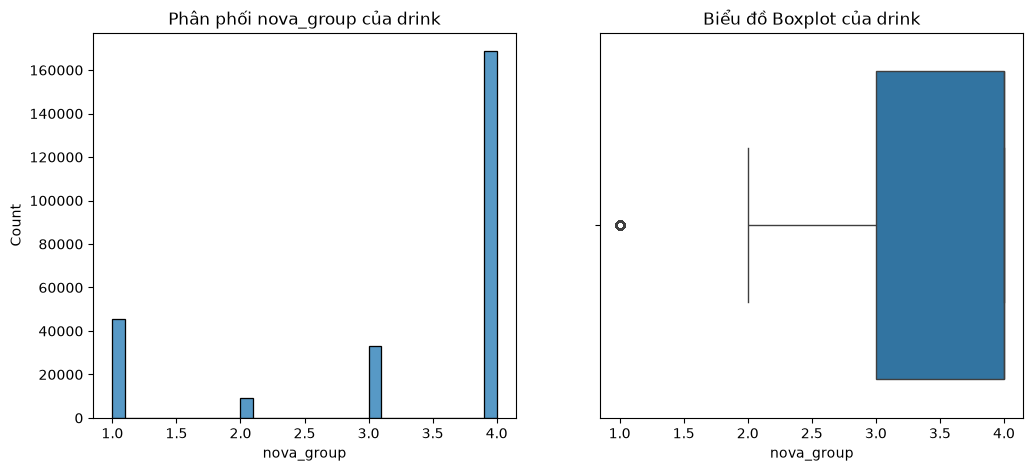

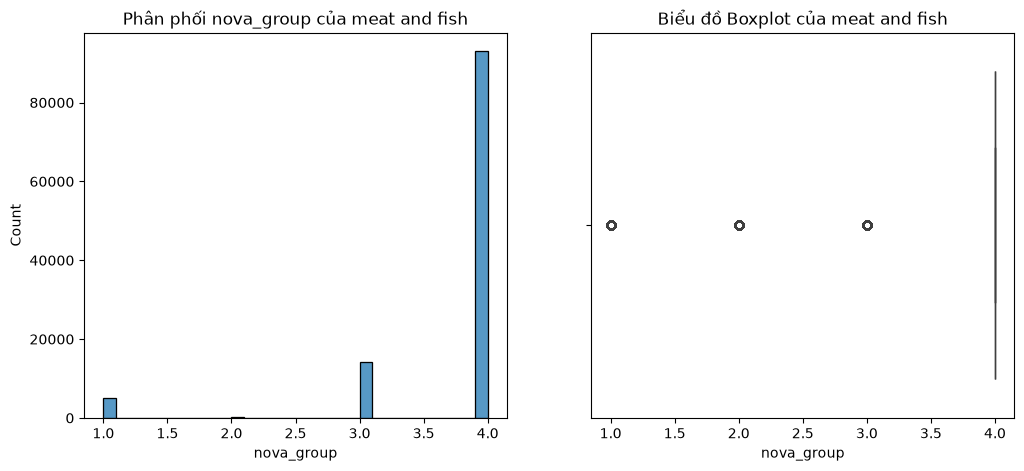

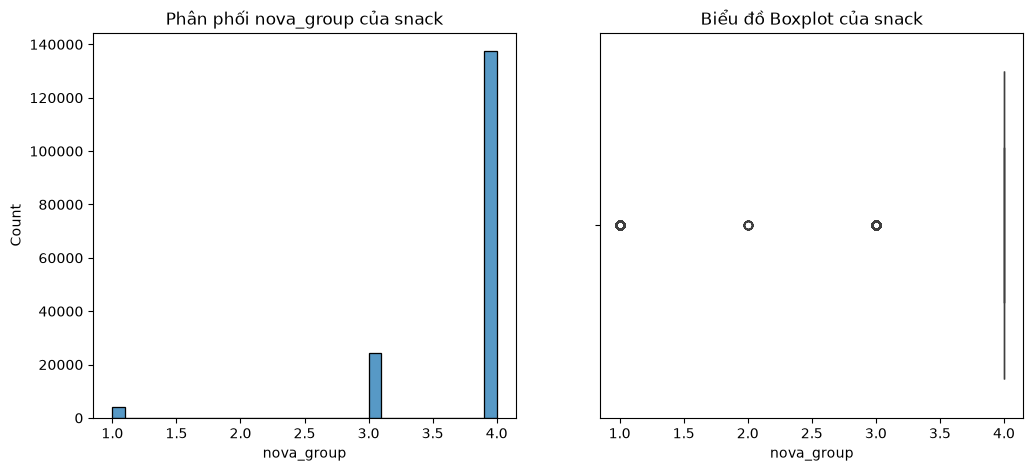

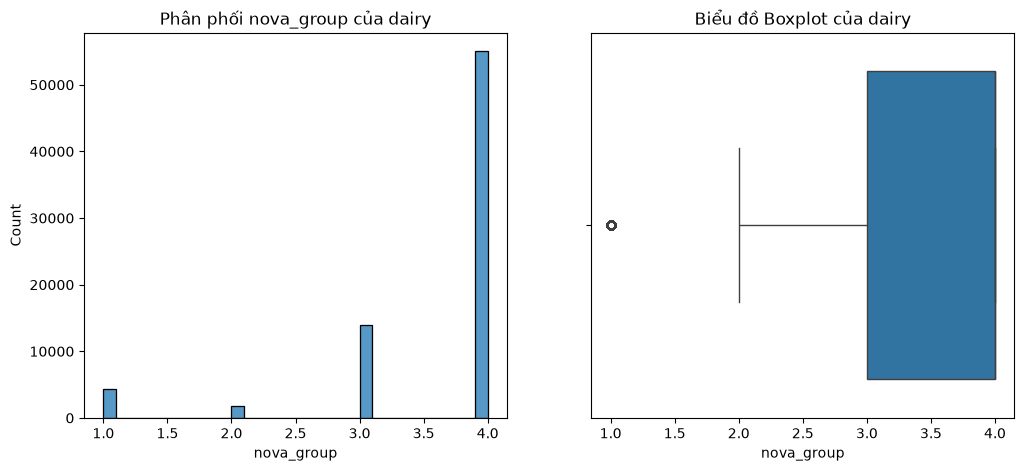

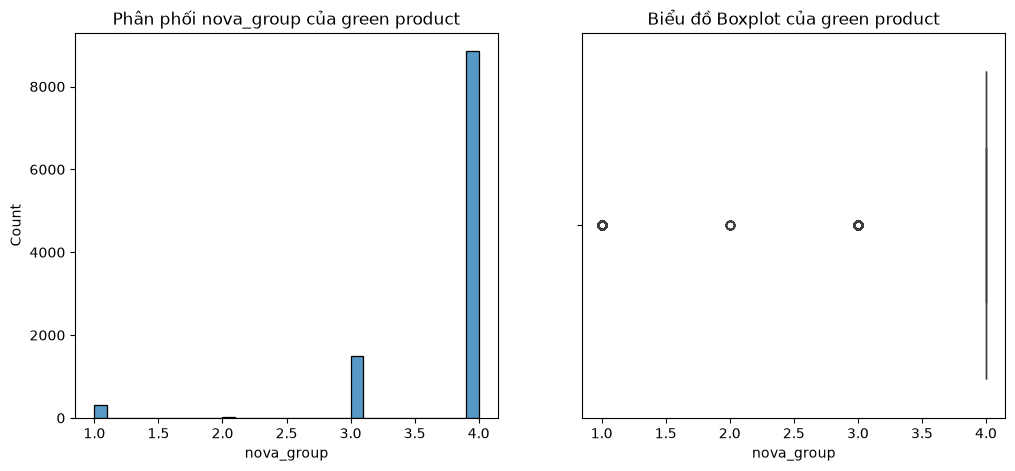

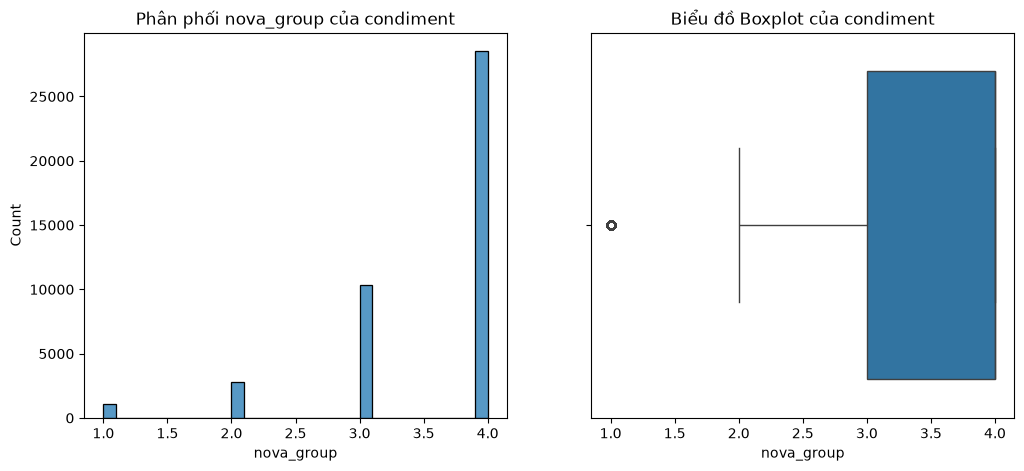

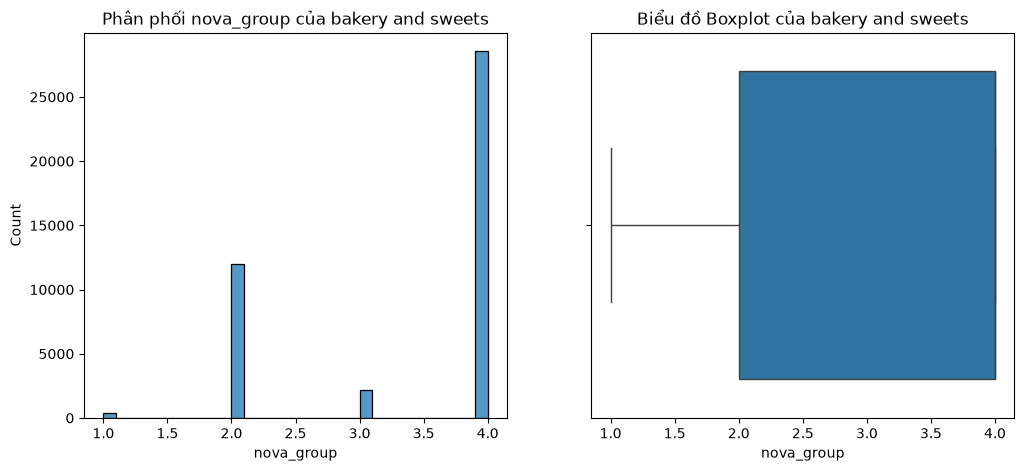

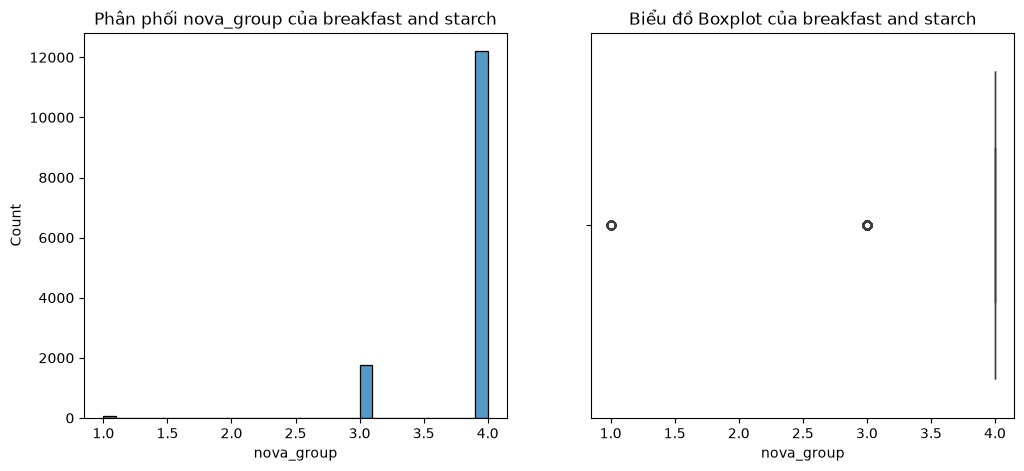

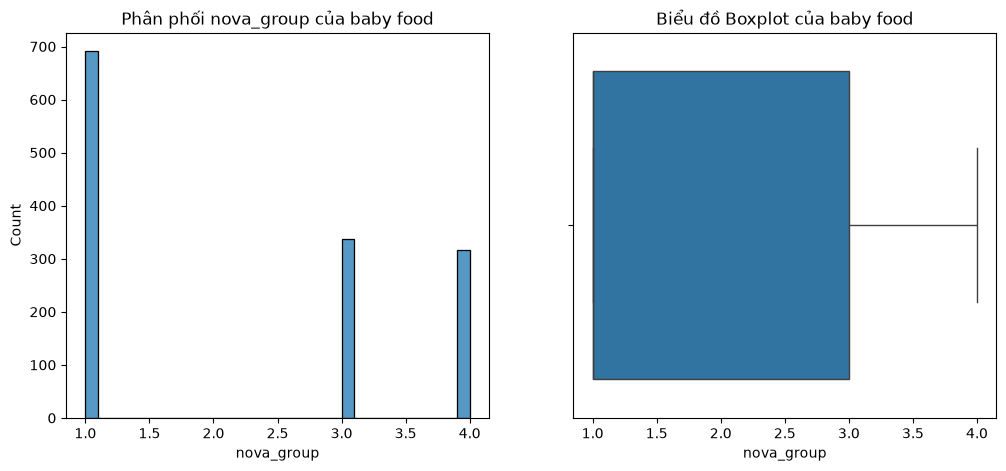

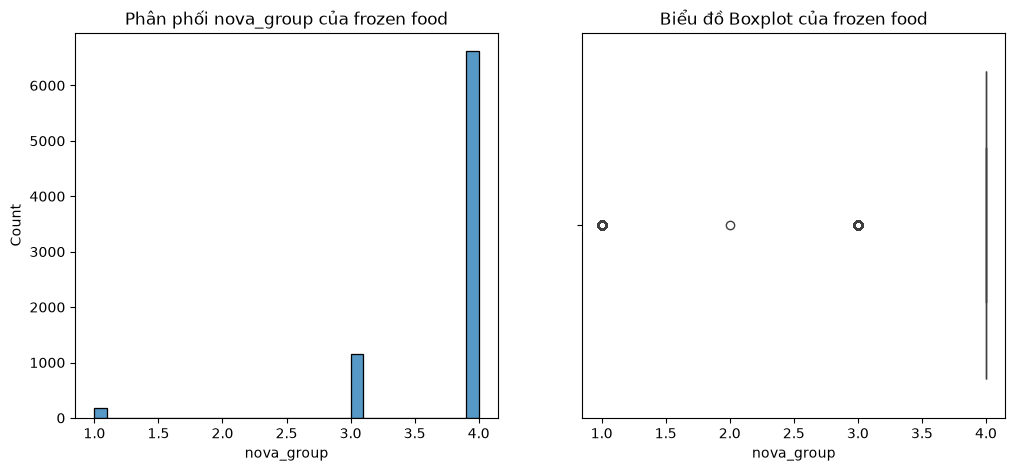

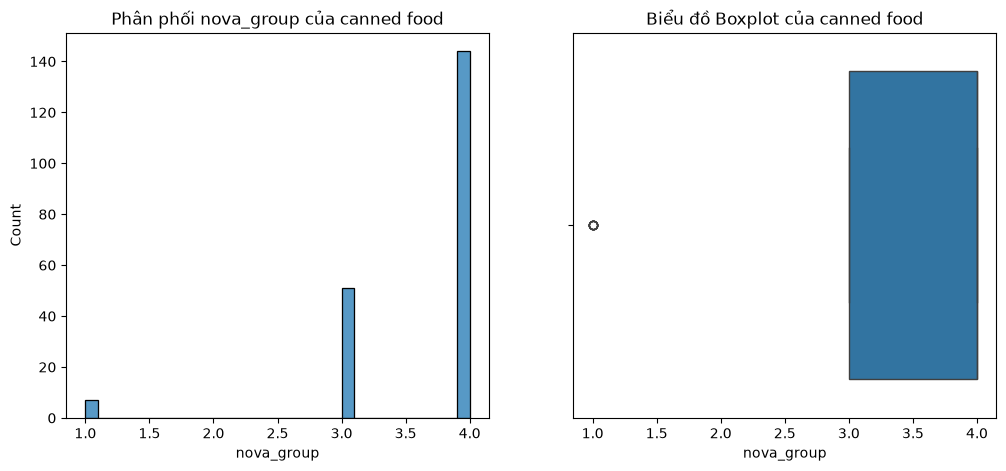

In [155]:


# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'nova_group' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]


    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['nova_group'].dropna(), kde=False, bins=30)
    plt.title(f'Phân phối nova_group của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['nova_group'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

In [156]:

df_categorize['additives_n'] = df_categorize.groupby('general_category')['additives_n'].transform(
    lambda x: x.fillna(get_mode(x))
)

# 4. Kiểm tra lại kết quả
print("Số lượng giá trị Null còn lại trong additives_n:", df_categorize['additives_n'].isnull().sum())

Số lượng giá trị Null còn lại trong additives_n: 0


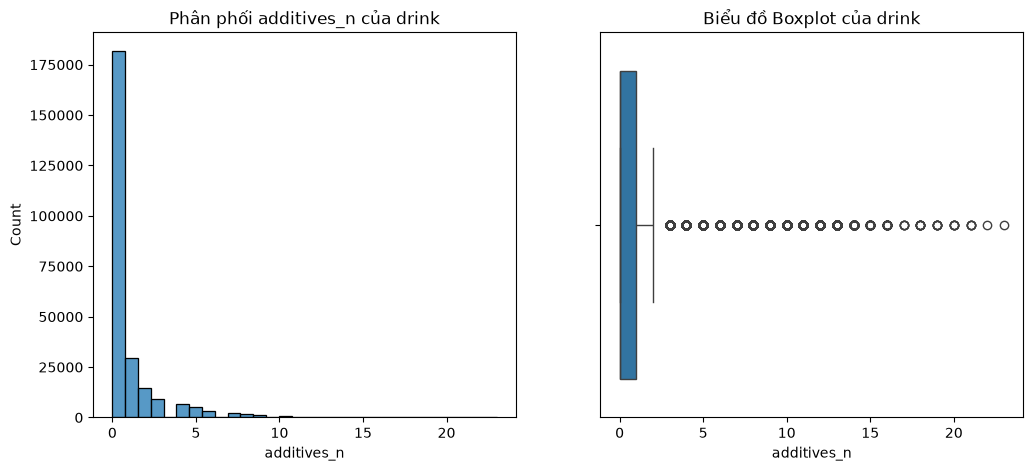

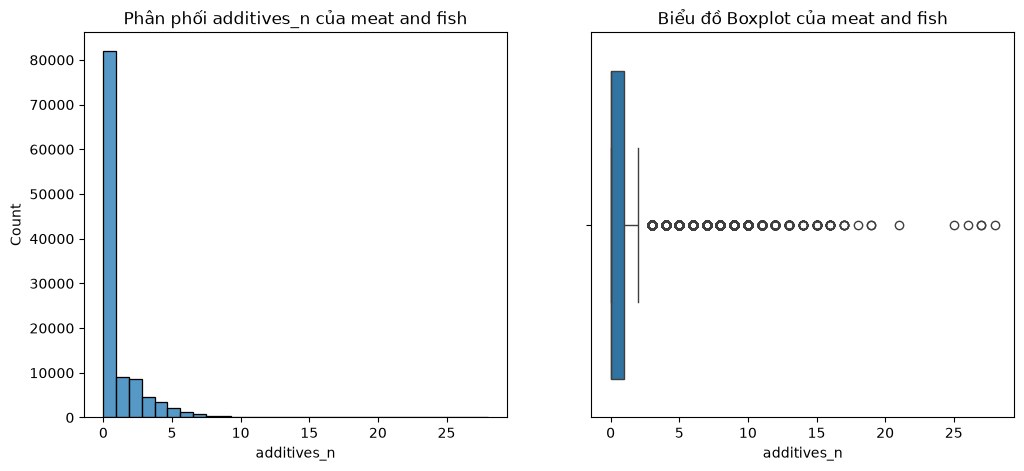

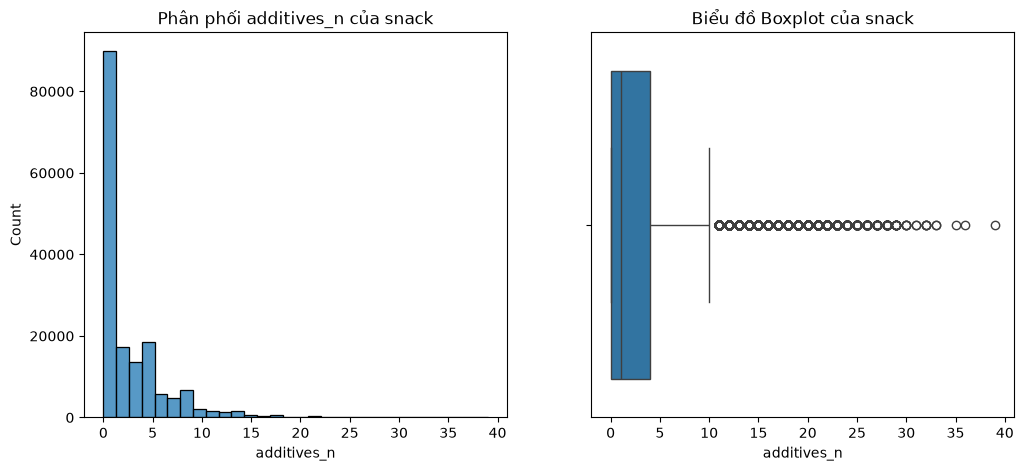

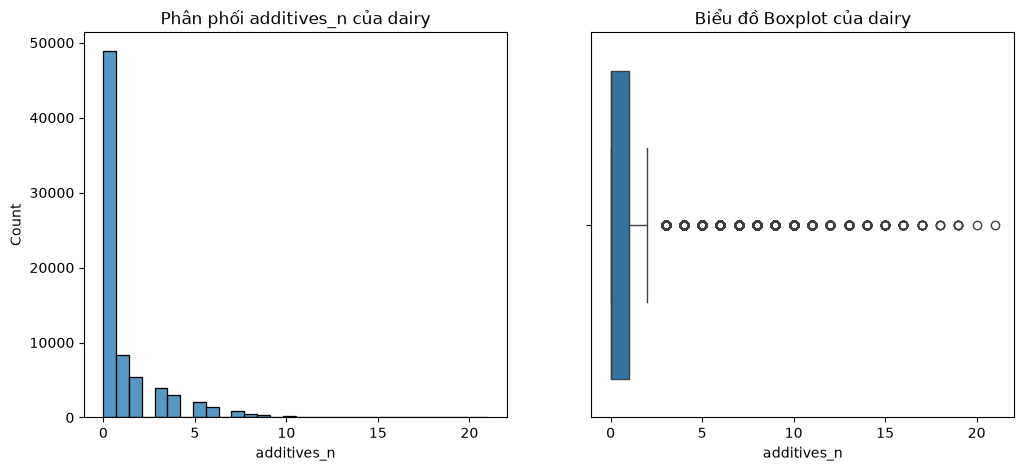

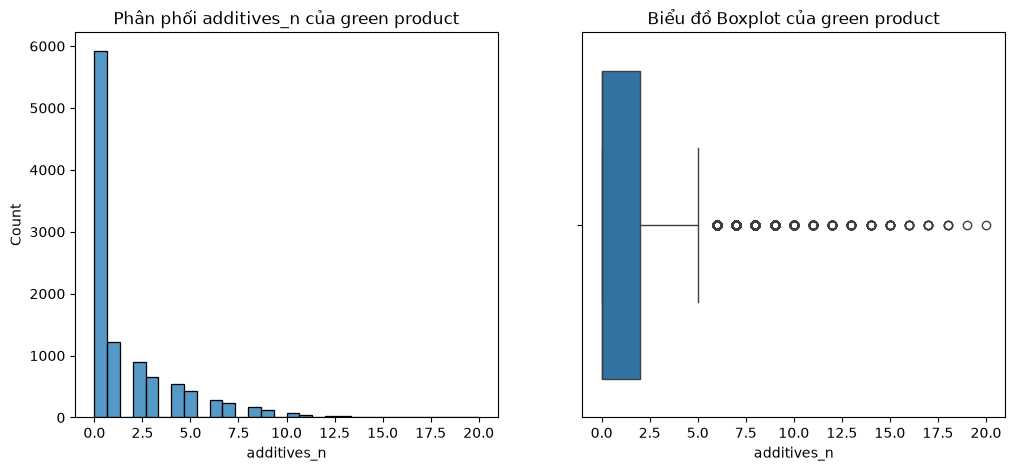

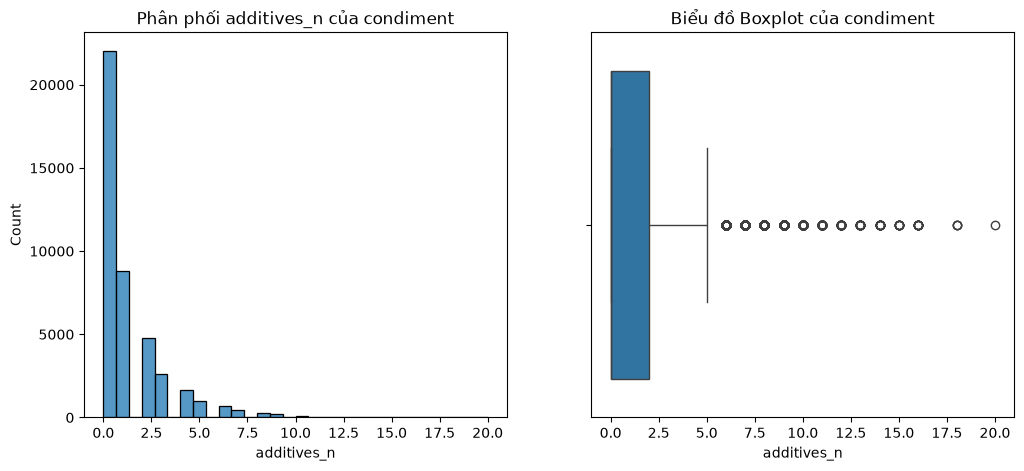

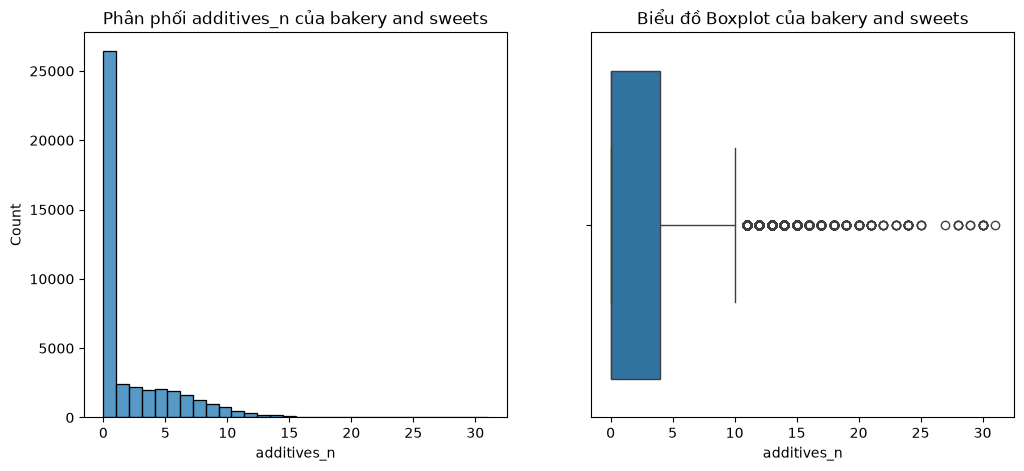

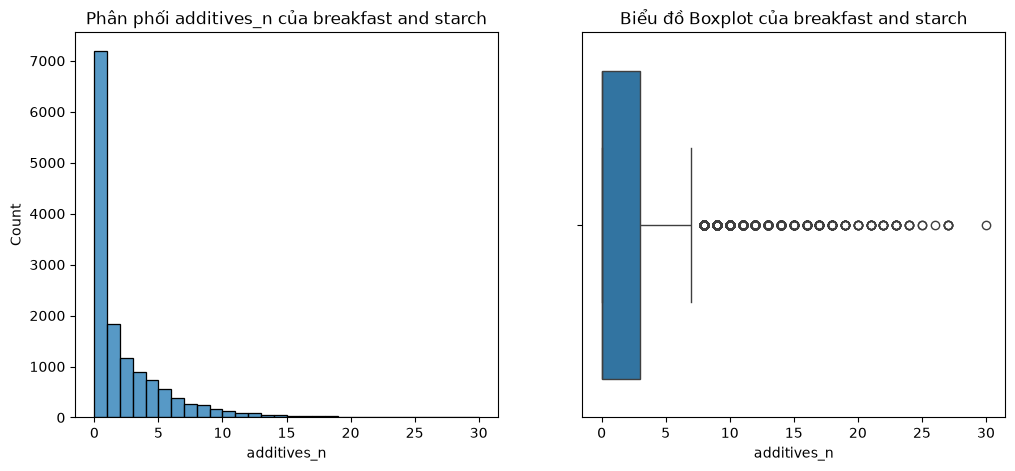

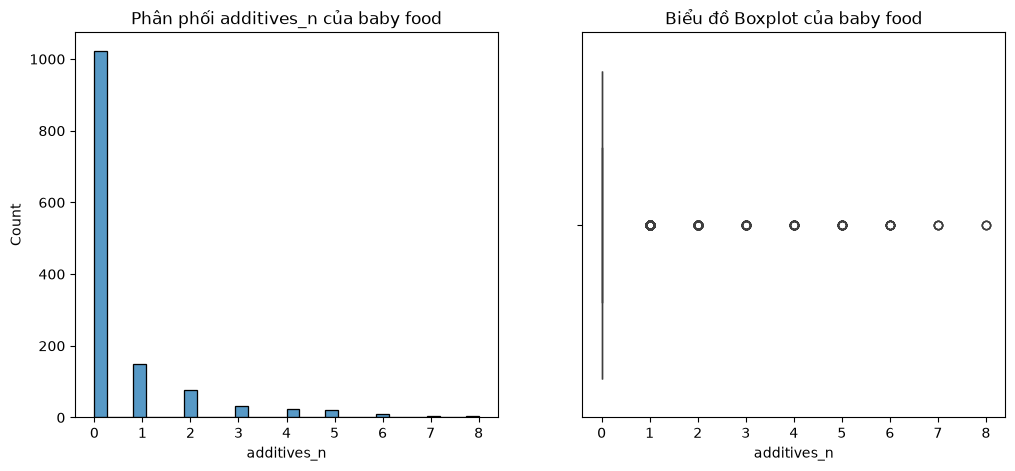

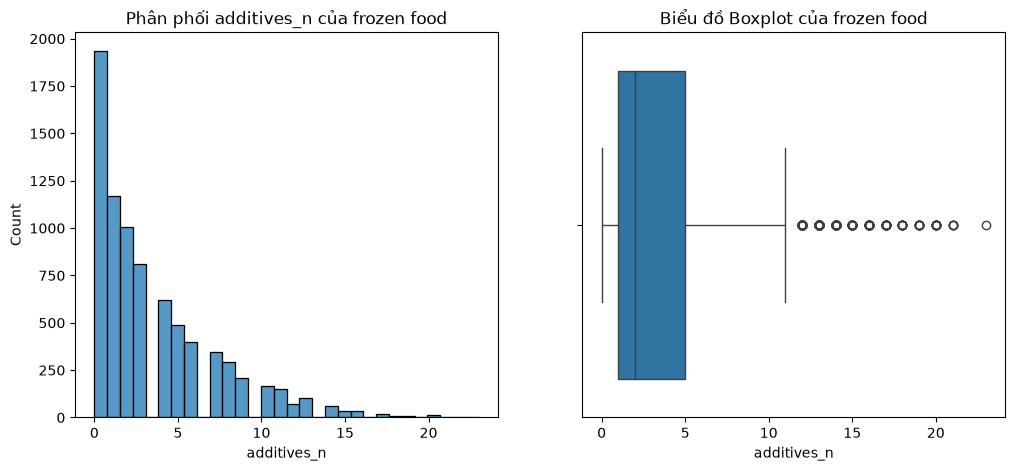

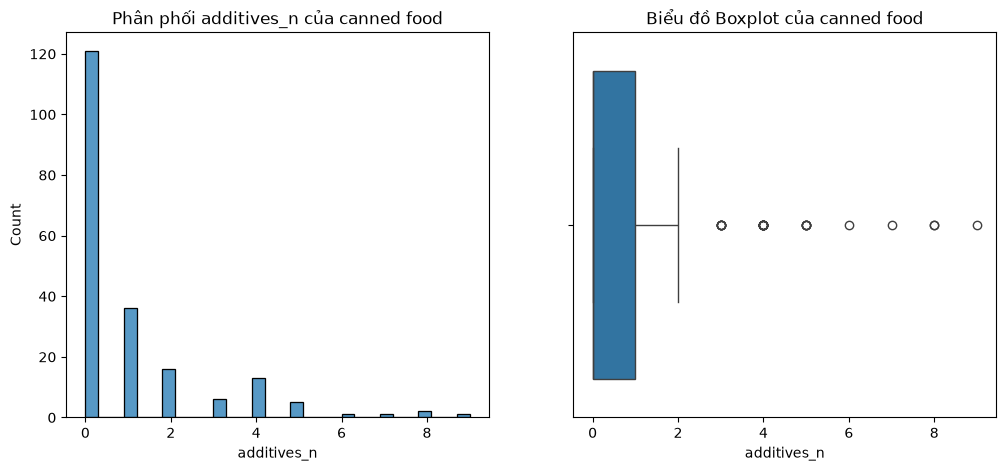

In [157]:

# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'additives_n' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]


    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['additives_n'].dropna(), kde=False, bins=30)
    plt.title(f'Phân phối additives_n của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['additives_n'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

In [158]:
df_categorize.info()

<class 'pandas.DataFrame'>
Index: 730324 entries, 0 to 730350
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   code                730324 non-null  object 
 1   categories_en       730324 non-null  str    
 2   countries_en        730324 non-null  str    
 3   additives_n         730324 non-null  float64
 4   nutriscore_score    593548 non-null  float64
 5   nutriscore_grade    730324 non-null  str    
 6   nova_group          730324 non-null  float64
 7   food_groups_en      621892 non-null  str    
 8   unique_scans_n      308237 non-null  float64
 9   completeness        730323 non-null  float64
 10  energy_100g         359934 non-null  float64
 11  fat_100g            357938 non-null  float64
 12  saturated-fat_100g  354898 non-null  float64
 13  carbohydrates_100g  357586 non-null  float64
 14  sugars_100g         356519 non-null  float64
 15  fiber_100g          207451 non-null  float64
 16  

In [159]:
df_categorize['food_groups_en'].unique()

<StringArray>
[                          'Alcoholic beverages',
                          'Sugary snacks,Sweets',
                  'Cereals and potatoes,Cereals',
              'Fruits and vegetables,Vegetables',
                         'Fish‚ Meat‚ Eggs,Eggs',
              'Sugary snacks,Biscuits and cakes',
    'Beverages,Teas and herbal teas and coffees',
                 'Fish‚ Meat‚ Eggs,Meat,Poultry',
            'Fruits and vegetables,Dried fruits',
       'Milk and dairy products,Milk and yogurt',
             'Fish‚ Meat‚ Eggs,Fish and seafood',
        'Cereals and potatoes,Breakfast cereals',
                 'Beverages,Sweetened beverages',
                'Composite foods,One-dish meals',
               'Fish‚ Meat‚ Eggs,Processed meat',
                'Milk and dairy products,Cheese',
  'Fish‚ Meat‚ Eggs,Fish and seafood,Fatty fish',
         'Salty snacks,Salty and fatty products',
                                             nan,
                       'Fish‚ Meat‚ 

### Biến food_groups_en có ý nghĩa khá tương đương general_category => loại bỏ food_groups_en

In [160]:
df_categorize = df_categorize.drop('food_groups_en', axis=1)


In [161]:
df_categorize['unique_scans_n']

0         NaN
1         3.0
2         NaN
3         4.0
4         2.0
         ... 
730346    NaN
730347    NaN
730348    NaN
730349    NaN
730350    NaN
Name: unique_scans_n, Length: 730324, dtype: float64

### Xem xét đến biến unique_scans_n có số lượng missing value khá nhiều, tuy nhiên đây là một trong những biến được đánh giá nằm trong mục tiêu khai thác tri thức của đồ án => nhóm không loại bỏ cột mà tiến hành nhị phân hóa về dạng binary thay vì numeric như hiện tại, với giá trị =1 là sản phẩm đã được người tiêu dùng quét mã quan tâm và =0 nghĩa là sản phẩm mới hoặc ít được quan tâm.

In [162]:
df_categorize['unique_scans_n'] = df_categorize['unique_scans_n'].notnull().astype(int)

# Kiểm tra kết quả
print(df_categorize['unique_scans_n'].value_counts())

unique_scans_n
0    422087
1    308237
Name: count, dtype: int64


In [163]:
df_categorize['unique_scans_n']


0         0
1         1
2         0
3         1
4         1
         ..
730346    0
730347    0
730348    0
730349    0
730350    0
Name: unique_scans_n, Length: 730324, dtype: int64

In [164]:
df_categorize.info()

<class 'pandas.DataFrame'>
Index: 730324 entries, 0 to 730350
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   code                730324 non-null  object 
 1   categories_en       730324 non-null  str    
 2   countries_en        730324 non-null  str    
 3   additives_n         730324 non-null  float64
 4   nutriscore_score    593548 non-null  float64
 5   nutriscore_grade    730324 non-null  str    
 6   nova_group          730324 non-null  float64
 7   unique_scans_n      730324 non-null  int64  
 8   completeness        730323 non-null  float64
 9   energy_100g         359934 non-null  float64
 10  fat_100g            357938 non-null  float64
 11  saturated-fat_100g  354898 non-null  float64
 12  carbohydrates_100g  357586 non-null  float64
 13  sugars_100g         356519 non-null  float64
 14  fiber_100g          207451 non-null  float64
 15  proteins_100g       358303 non-null  float64
 16  

In [165]:
# Danh sách các cột dinh dưỡng quan trọng
nutrition_cols = ['energy_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'fiber_100g']

# Điền giá trị thiếu bằng trung vị của từng nhóm sản phẩm
for col in nutrition_cols:
    df_categorize[col] = df_categorize.groupby('general_category')[col].transform(lambda x: x.fillna(x.median()))



In [166]:
df_categorize.info()

<class 'pandas.DataFrame'>
Index: 730324 entries, 0 to 730350
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   code                730324 non-null  object 
 1   categories_en       730324 non-null  str    
 2   countries_en        730324 non-null  str    
 3   additives_n         730324 non-null  float64
 4   nutriscore_score    593548 non-null  float64
 5   nutriscore_grade    730324 non-null  str    
 6   nova_group          730324 non-null  float64
 7   unique_scans_n      730324 non-null  int64  
 8   completeness        730323 non-null  float64
 9   energy_100g         730324 non-null  float64
 10  fat_100g            730324 non-null  float64
 11  saturated-fat_100g  730324 non-null  float64
 12  carbohydrates_100g  730324 non-null  float64
 13  sugars_100g         730324 non-null  float64
 14  fiber_100g          730324 non-null  float64
 15  proteins_100g       730324 non-null  float64
 16  

### Dữ liệu dinh dưỡng thường bị lệch và có nhiều ngoại lai => Median giúp tránh sai số do những sản phẩm có hàm lượng cực cao hoặc cực thấp gây ra.
### Điền theo median của nhóm hợp lý hóa các thành phần dinh dưỡng theo chuẩn nhóm loại thực phẩm đó.

In [167]:
def validate_nutrition_data(df):
    initial_count = len(df)

    macro_cols = ['fat_100g', 'carbohydrates_100g', 'proteins_100g', 'fiber_100g']
    all_nutr_cols = macro_cols + ['sugars_100g', 'saturated-fat_100g']

    for col in all_nutr_cols:
        df = df[(df[col].fillna(0) >= 0) & (df[col].fillna(0) <= 100)]

    df = df[df['sugars_100g'].fillna(0) <= df['carbohydrates_100g'].fillna(0)]

    df = df[df['saturated-fat_100g'].fillna(0) <= df['fat_100g'].fillna(0)]

    total_mass = df[macro_cols].sum(axis=1)
    df = df[total_mass <= 100.5]

    final_count = len(df)
    print(f"Số lượng bản ghi loại bỏ: {initial_count - final_count}")
    print(f"Số lượng bản ghi hợp lệ: {final_count}")

    return df

df_categorize = validate_nutrition_data(df_categorize)

Số lượng bản ghi loại bỏ: 13206
Số lượng bản ghi hợp lệ: 717118


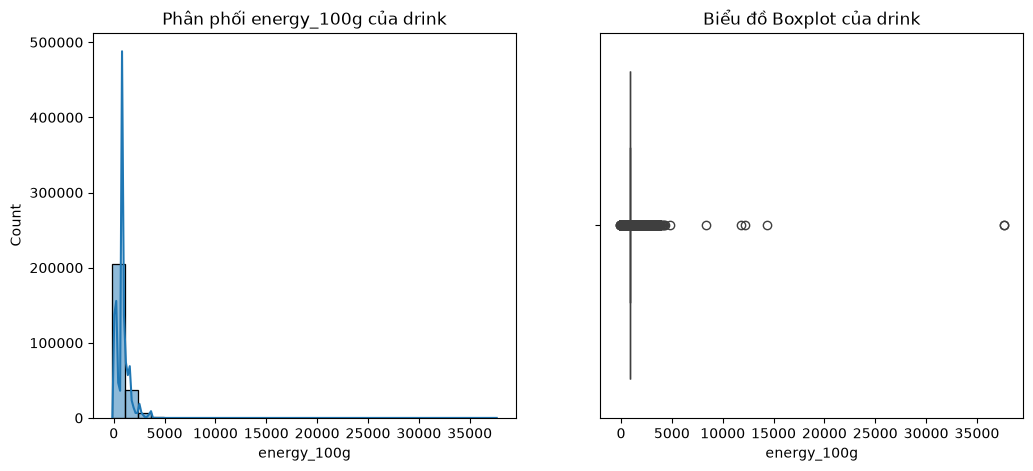

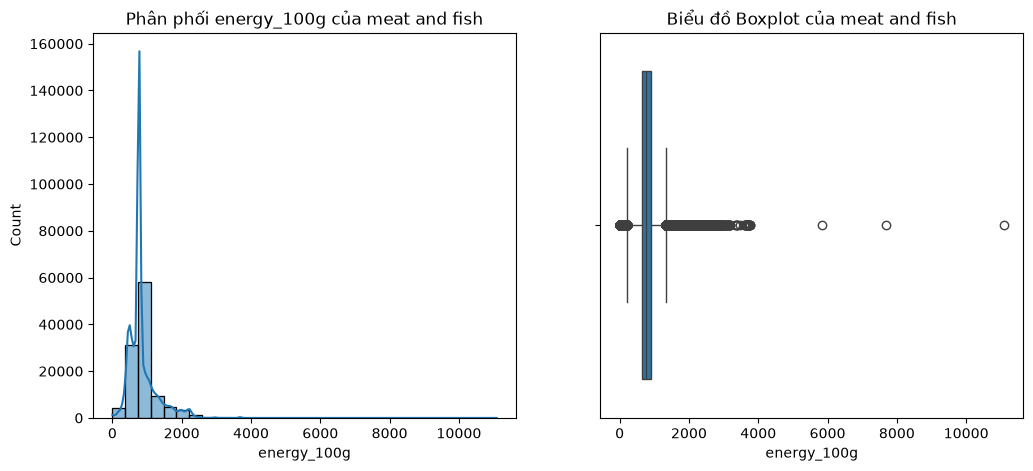

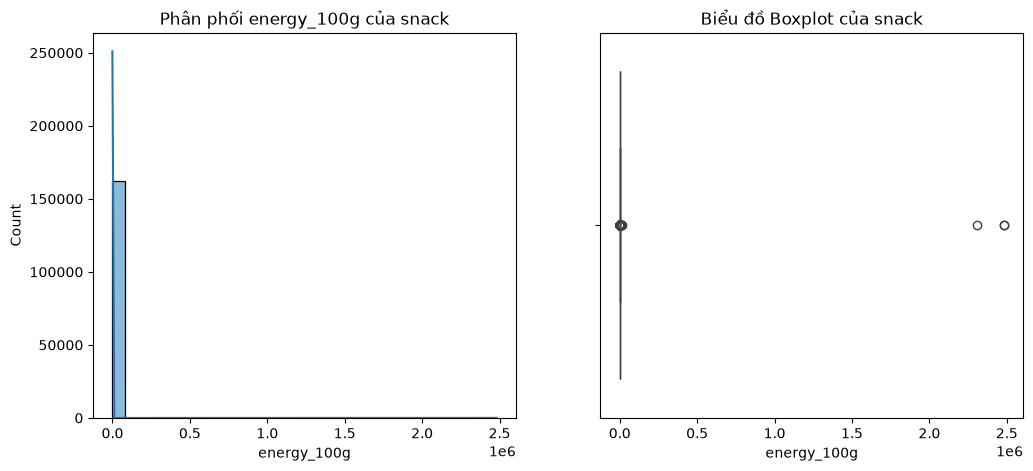

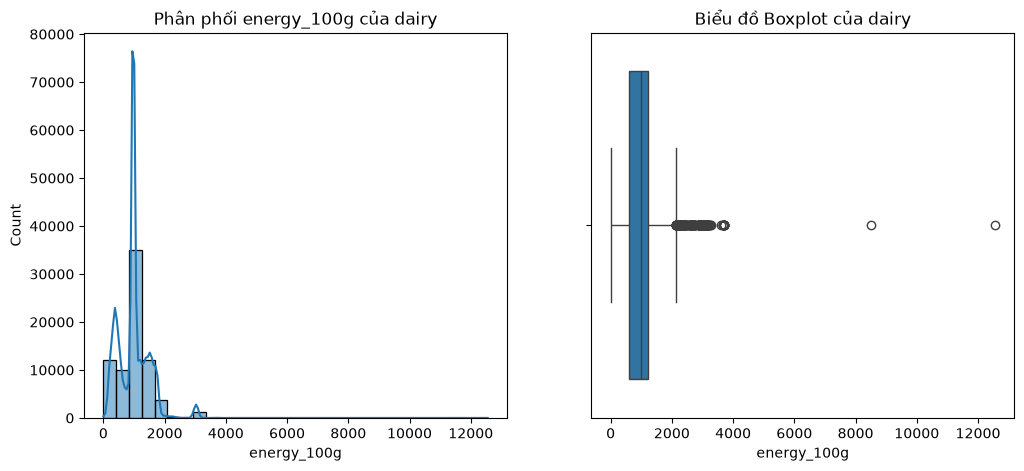

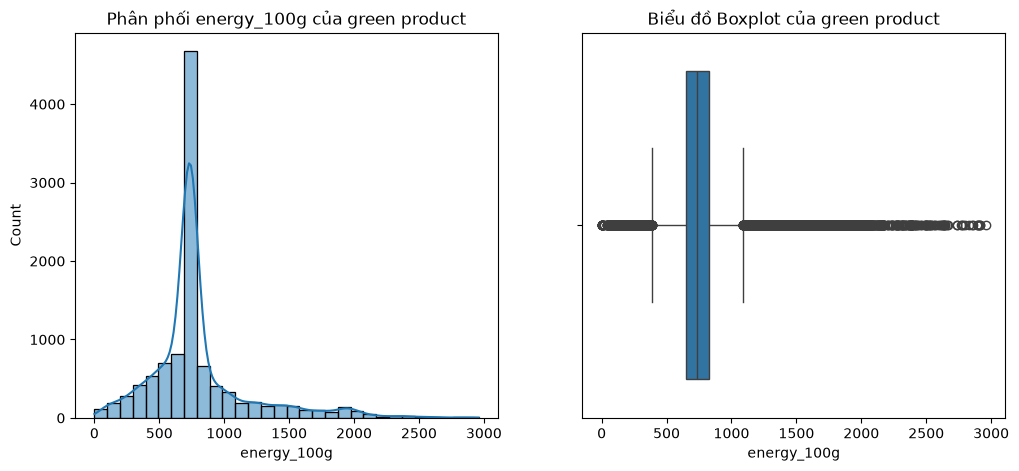

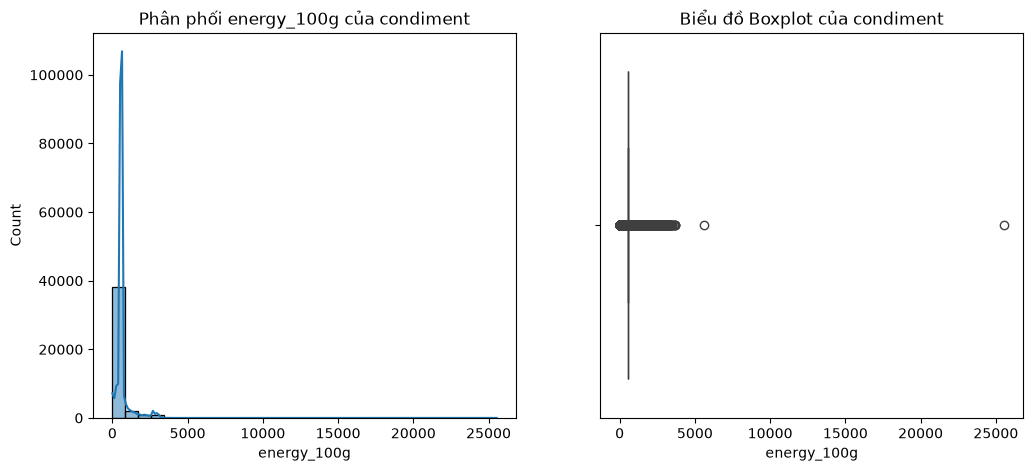

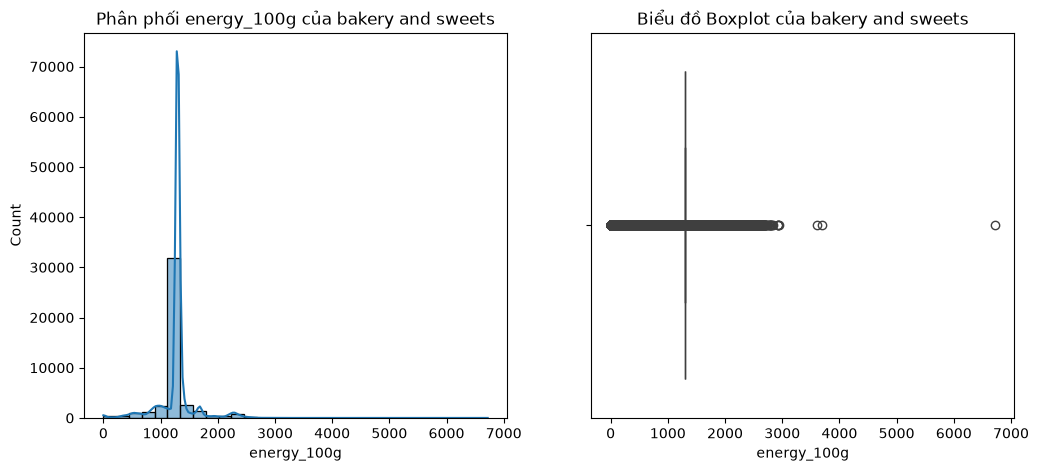

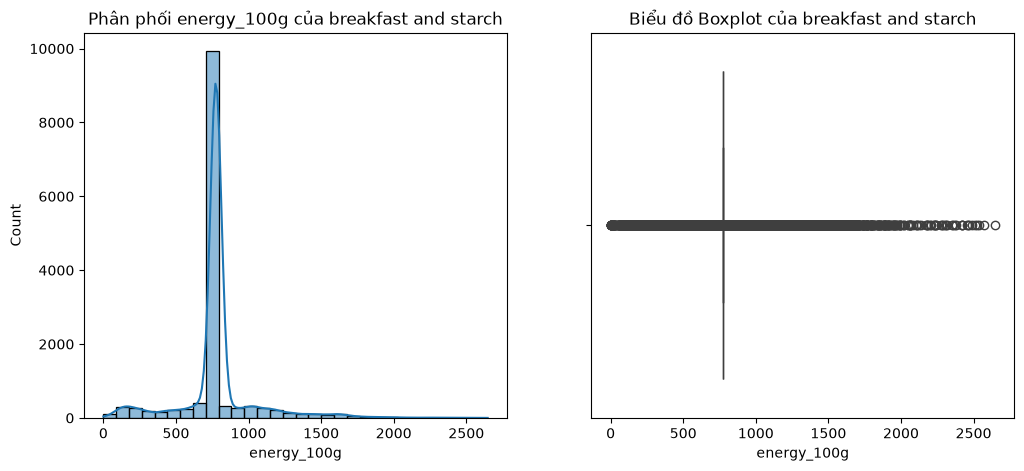

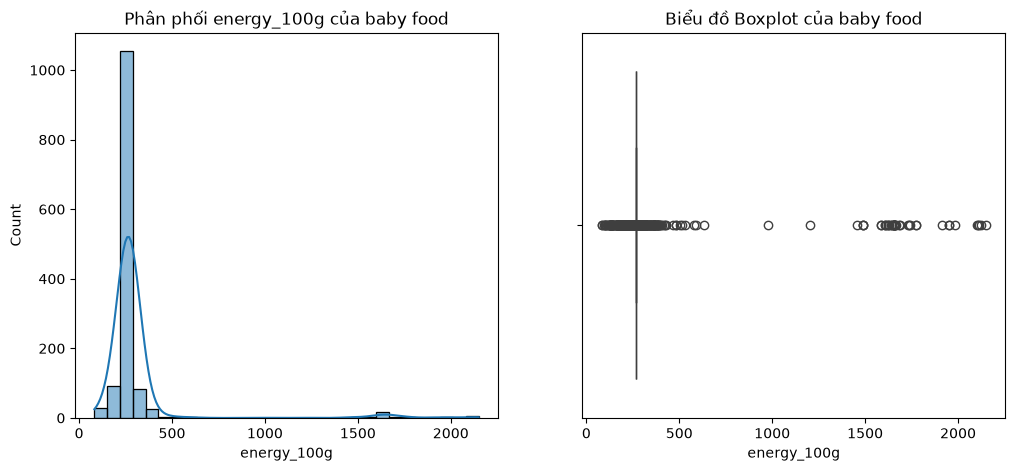

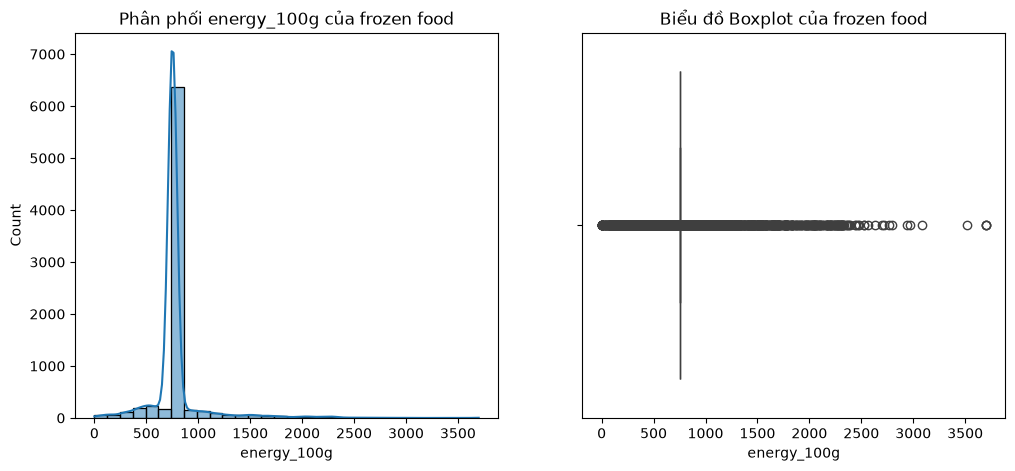

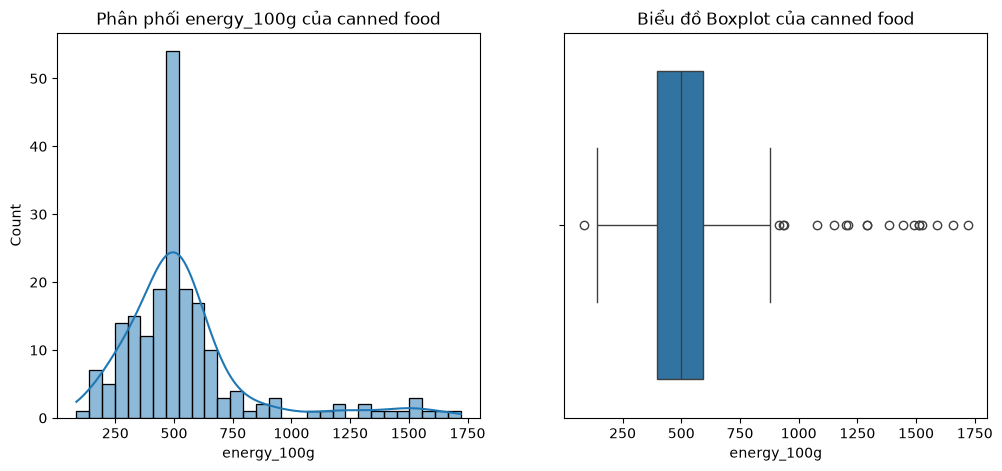

In [168]:
#### biến energy_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'energy_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['energy_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối energy_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['energy_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

In [169]:
### Lọc outlier của energy_100g

def remove_nova_outliers_per_category(df):
    initial_count = len(df)

    # Tính Q1, Q3 cho energy_100g theo từng nhóm
    groups = df.groupby('general_category')['energy_100g']

    q1 = groups.transform(lambda x: x.quantile(0.25))
    q3 = groups.transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Lọc DataFrame
    df_filtered = df[(df['energy_100g'] >= lower_bound) & (df['energy_100g'] <= upper_bound)]

    print(f"Số lượng bản ghi trước khi lọc: {initial_count}")
    print(f"Số lượng bản ghi sau khi lọc energy_100g outlier: {len(df_filtered)}")
    print(f"Đã loại bỏ: {initial_count - len(df_filtered)} sản phẩm có mức energy_100g ngoại lai theo từng nhóm.")

    return df_filtered

# Thực thi
df_categorize = remove_nova_outliers_per_category(df_categorize)

Số lượng bản ghi trước khi lọc: 717118
Số lượng bản ghi sau khi lọc energy_100g outlier: 483414
Đã loại bỏ: 233704 sản phẩm có mức energy_100g ngoại lai theo từng nhóm.


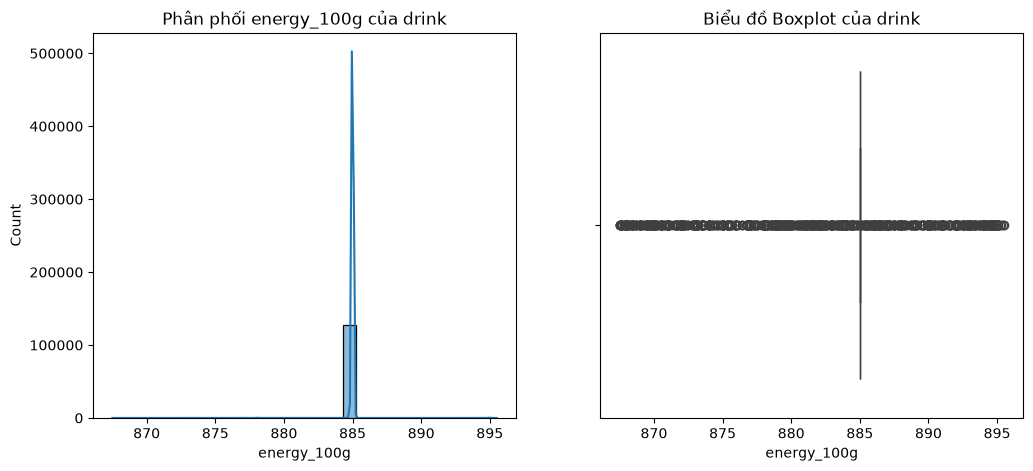

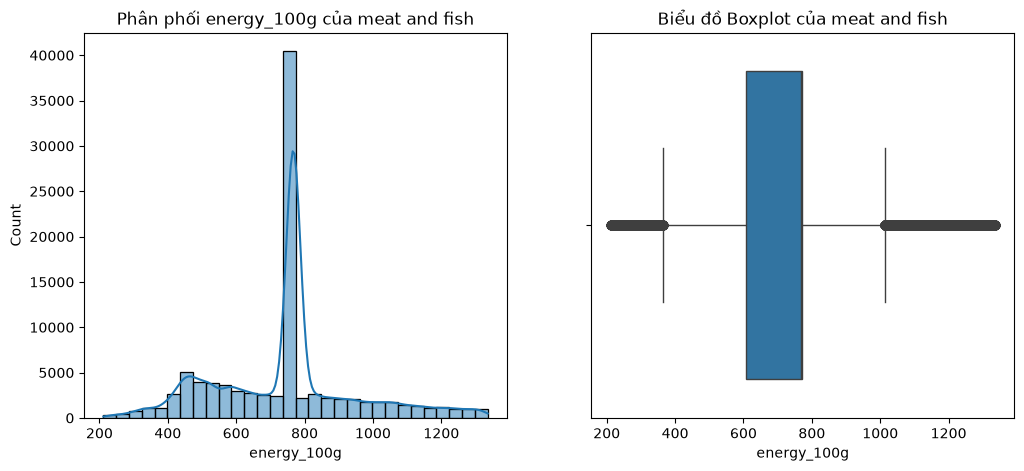

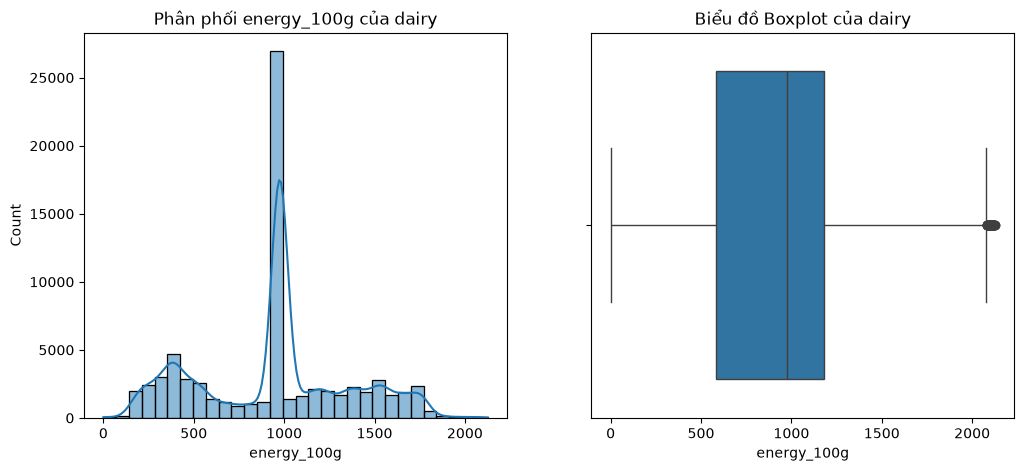

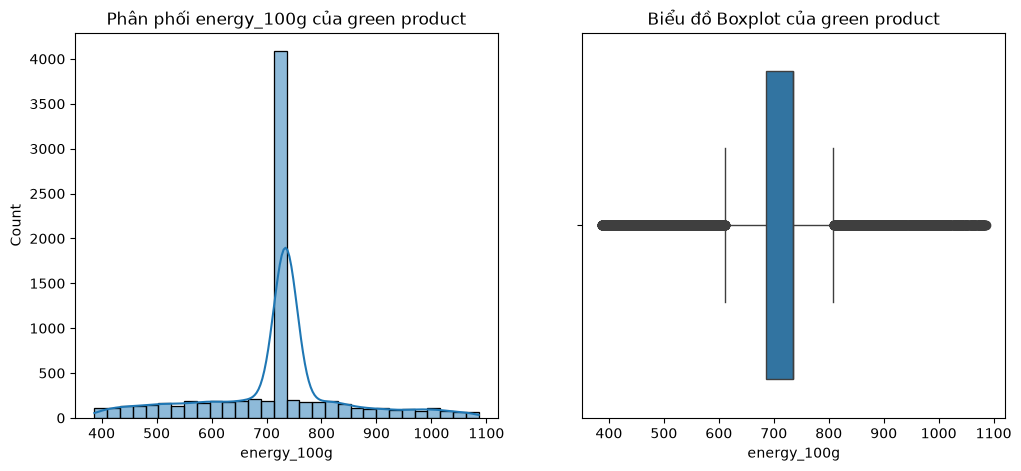

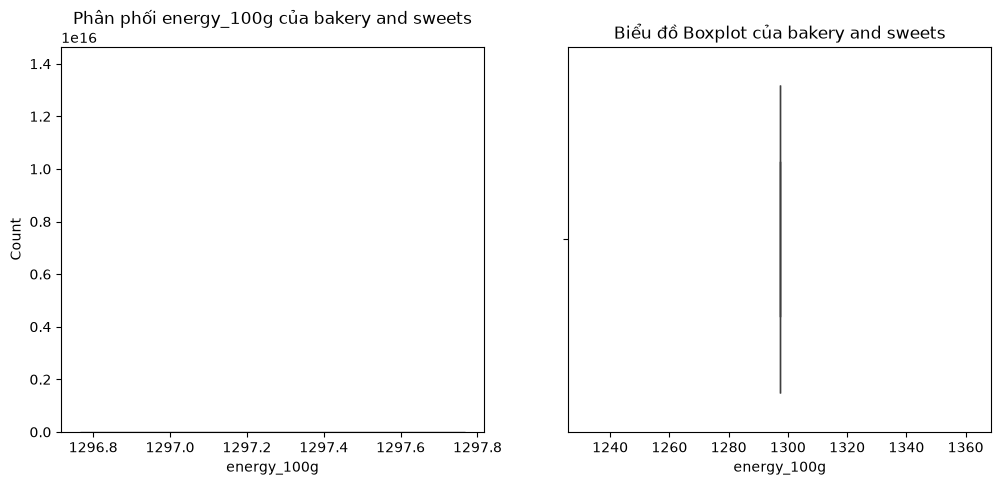

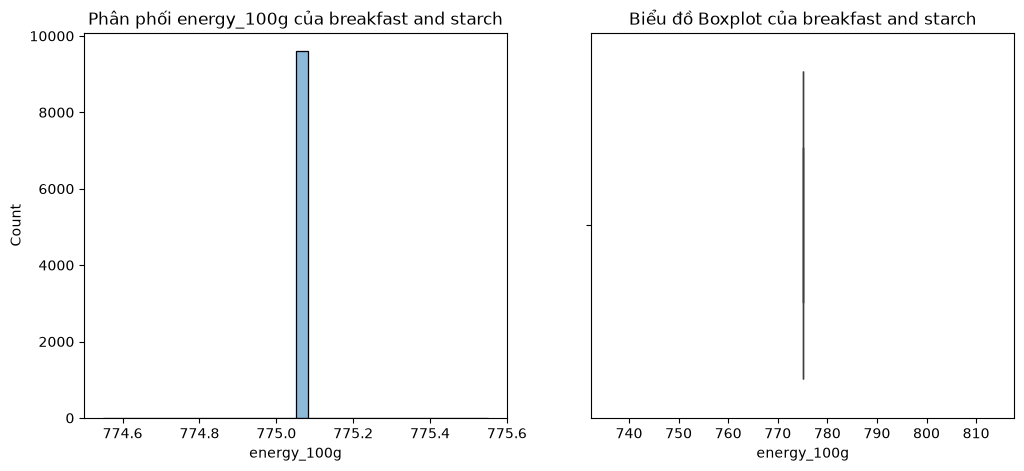

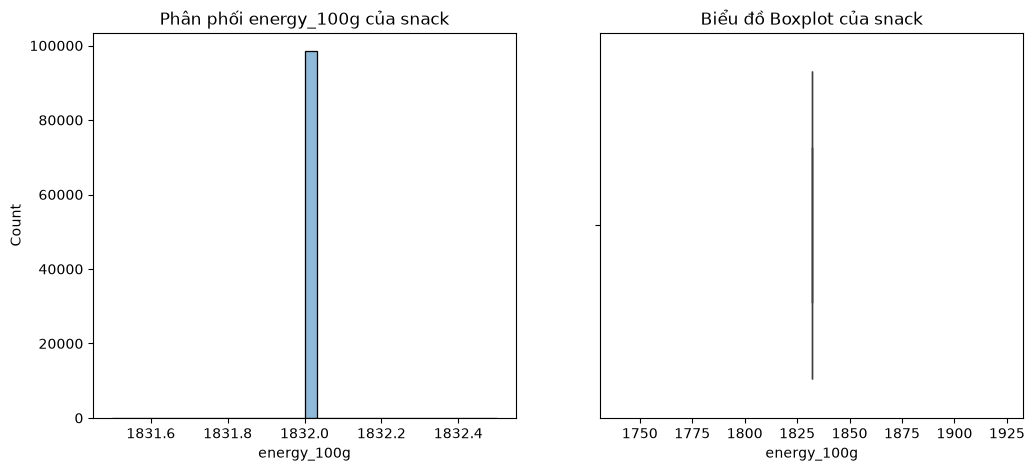

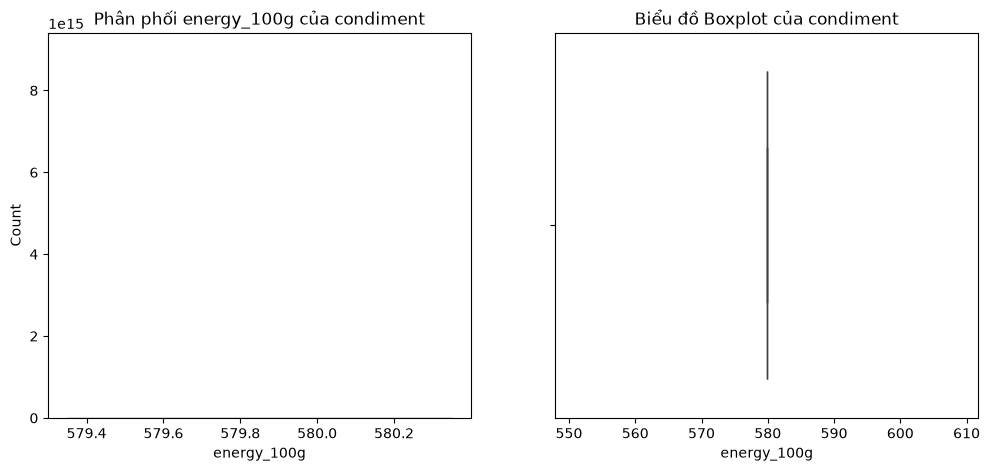

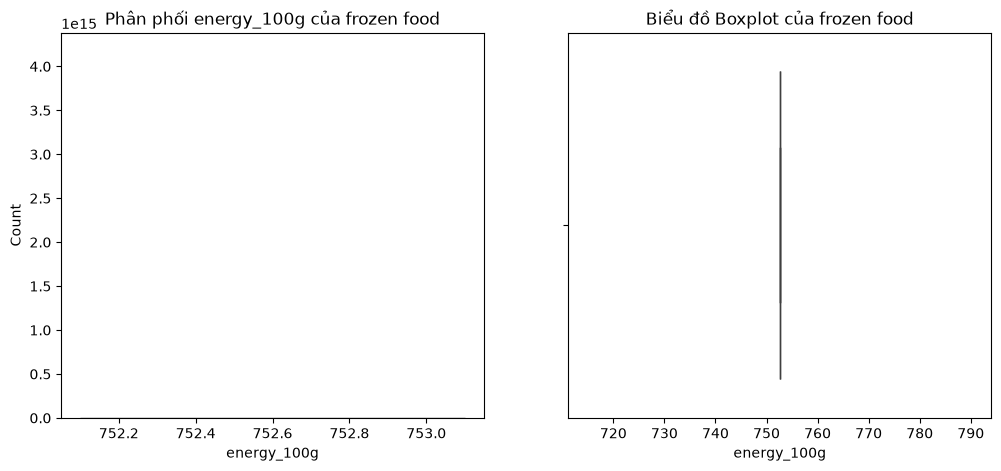

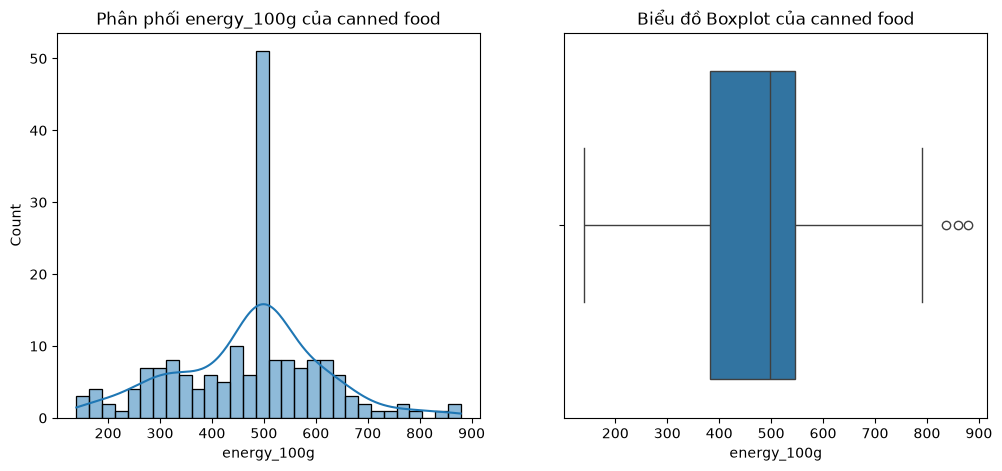

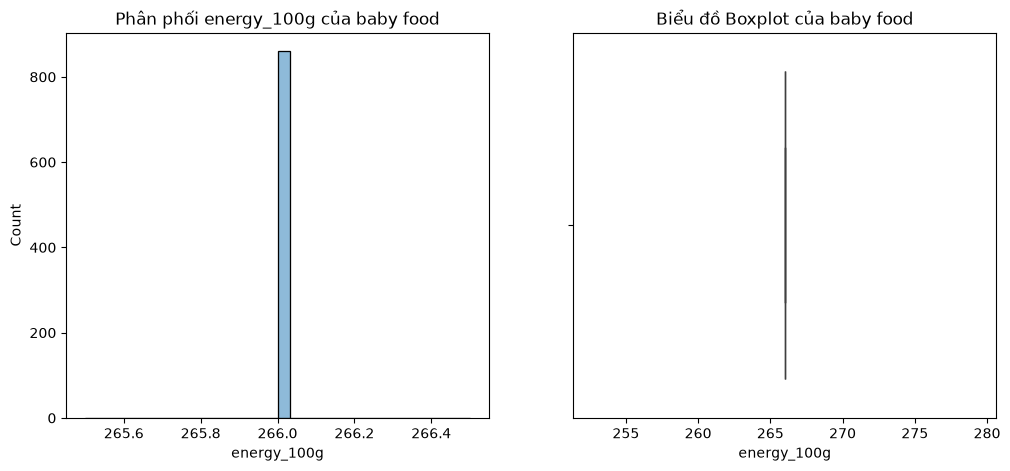

In [170]:
#### biến energy_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'energy_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['energy_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối energy_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['energy_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

# LỌC OUTLIER NGOẠI LAI TỪNG NHÓM DINH DƯỠNG

## fat_100g

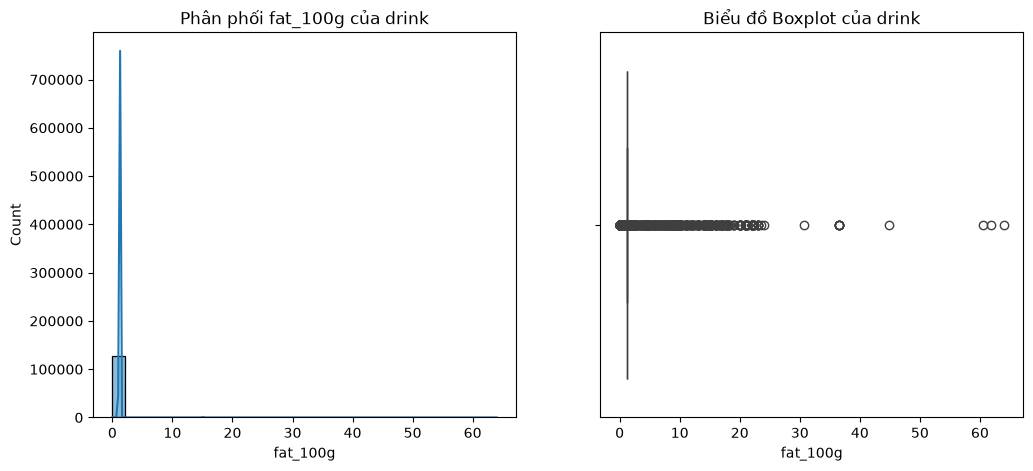

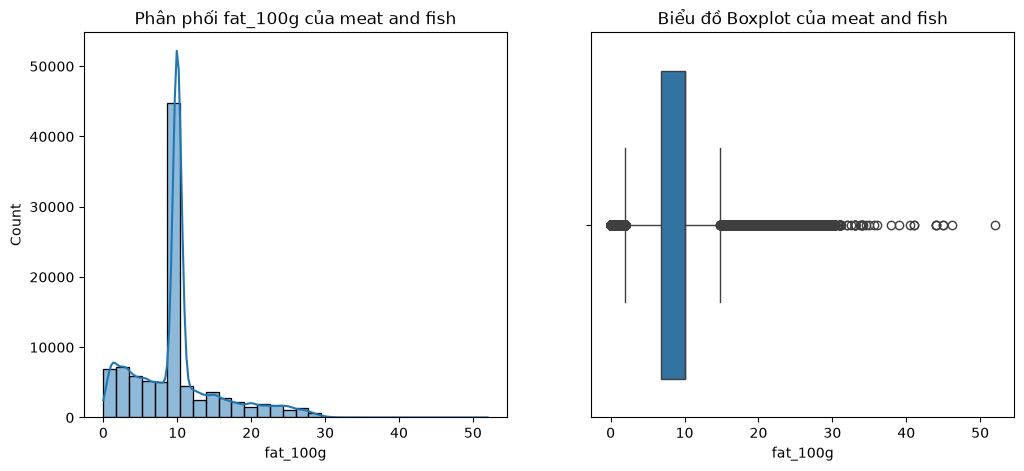

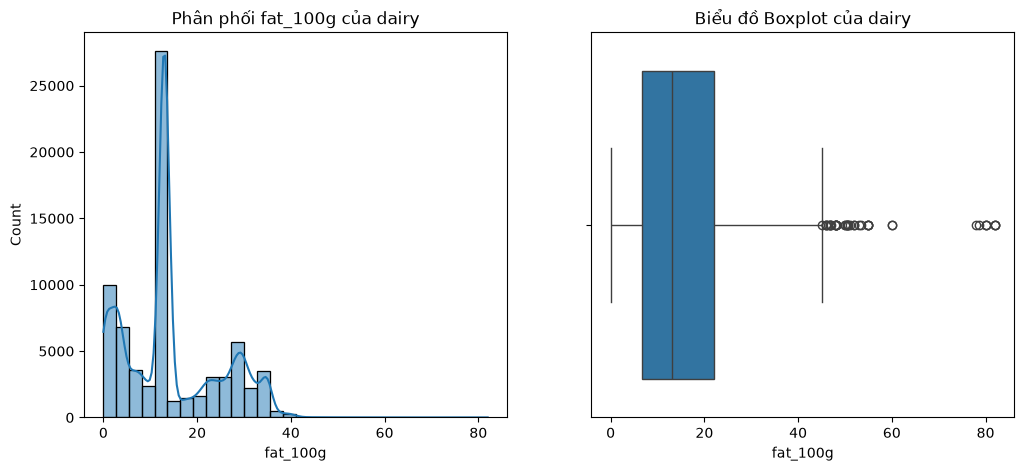

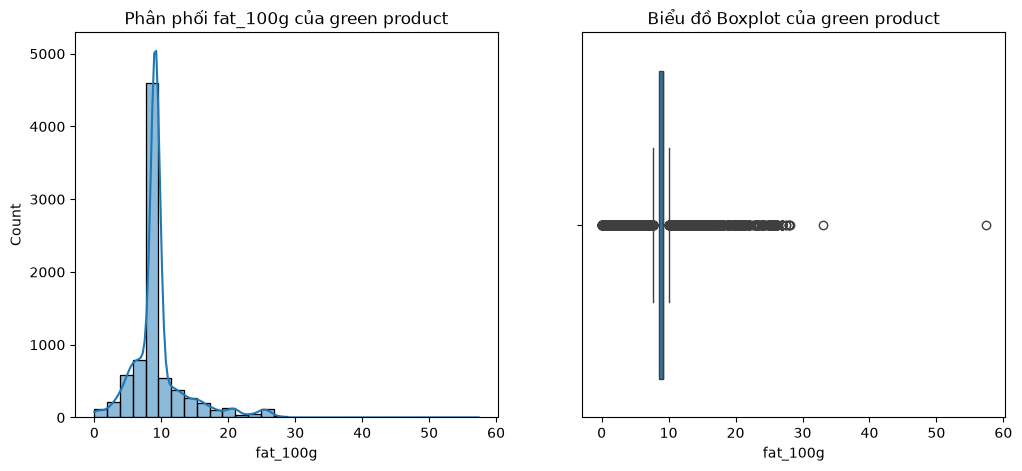

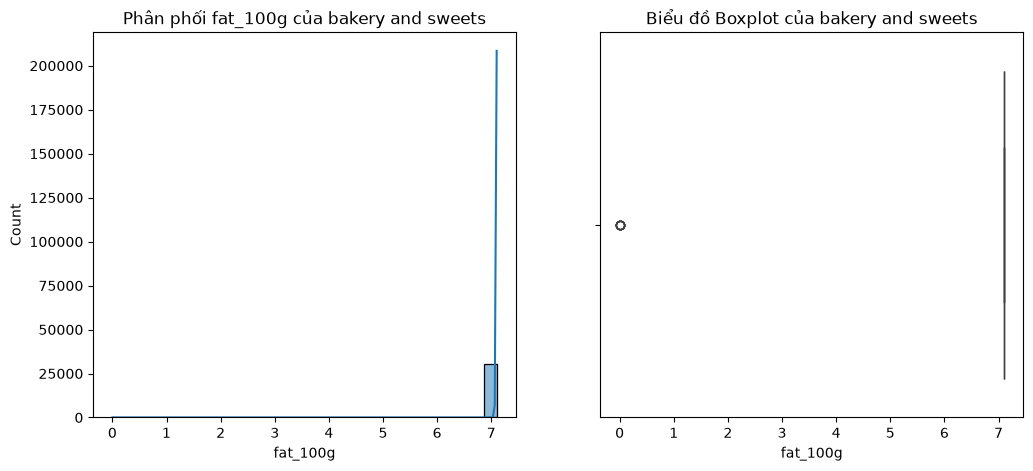

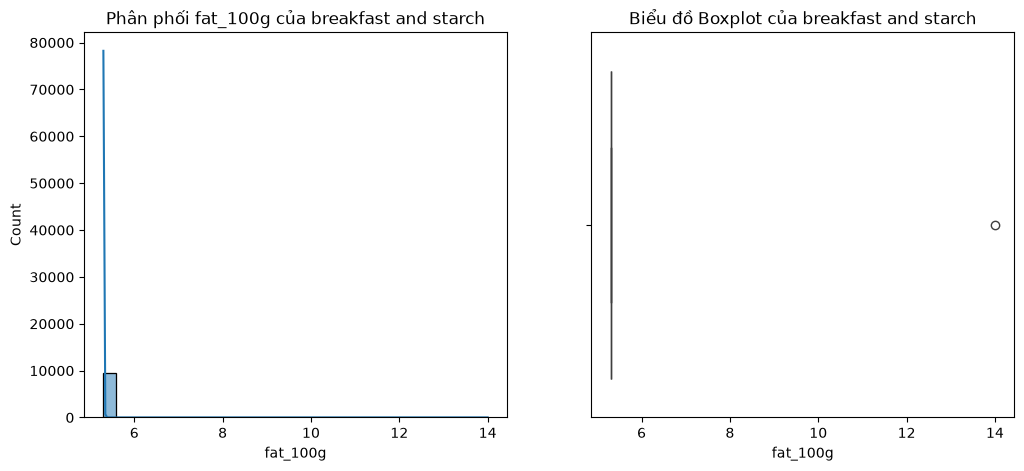

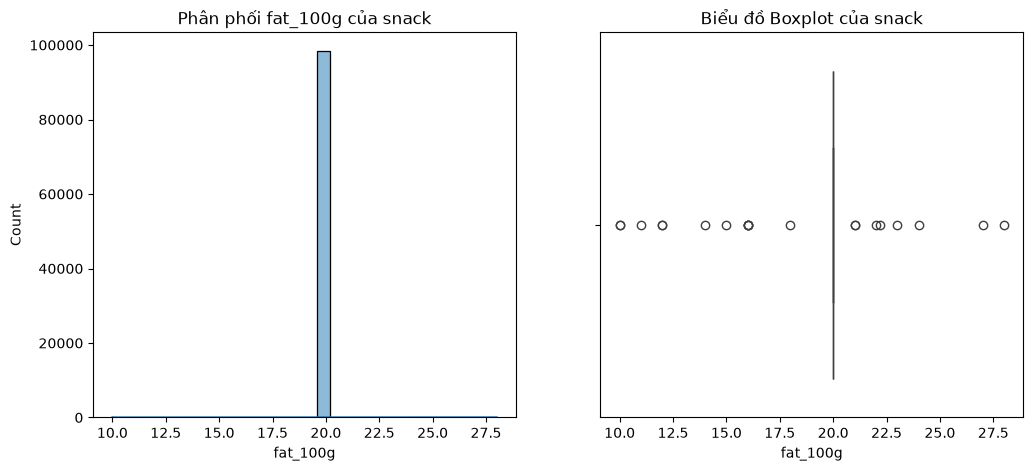

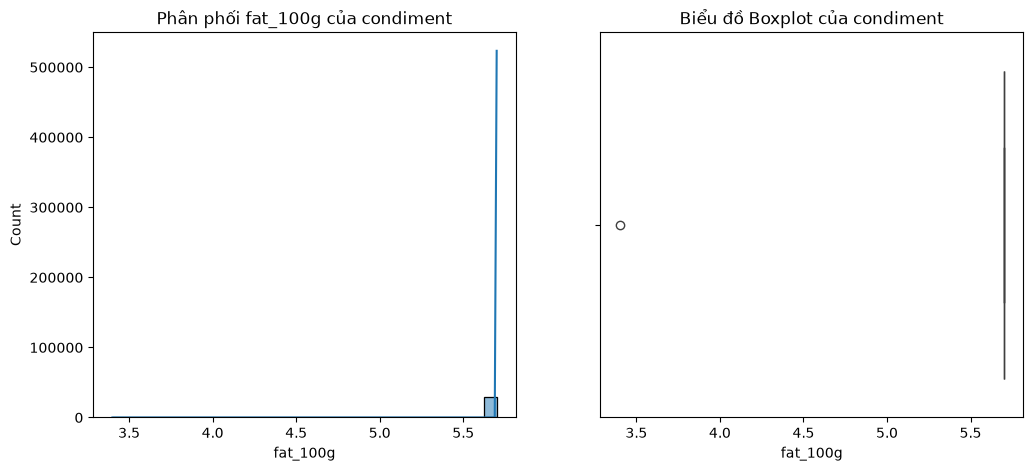

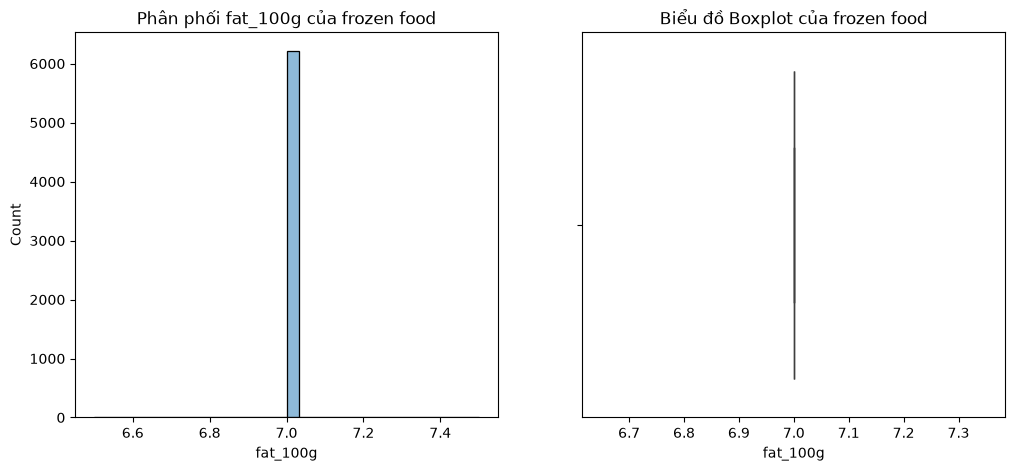

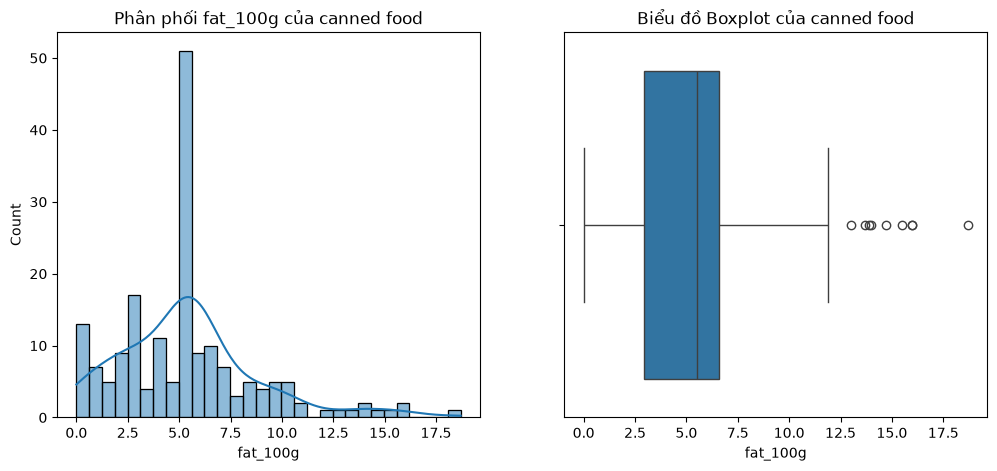

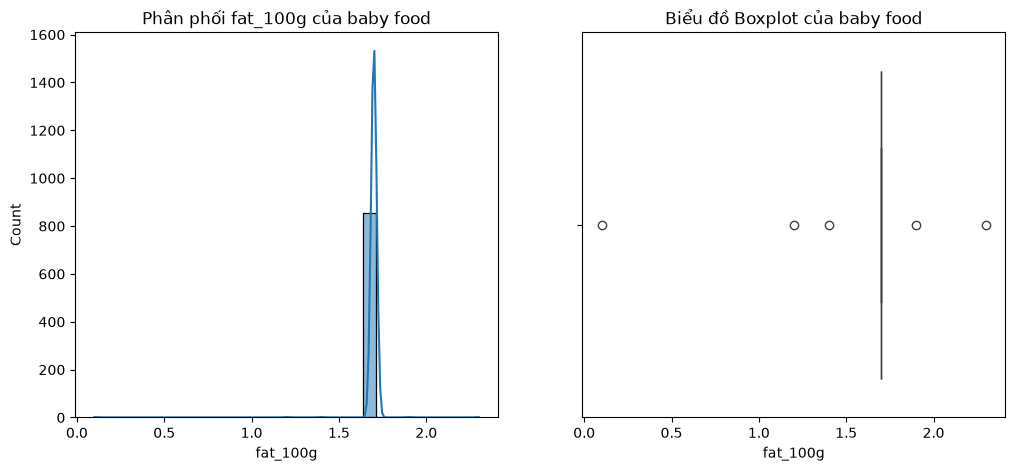

In [171]:
#### biến fat_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'fat_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['fat_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối fat_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['fat_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

In [172]:
### Lọc outlier của fat_100g

def remove_nova_outliers_per_category(df):
    initial_count = len(df)

    # Tính Q1, Q3 cho fat_100g theo từng nhóm
    groups = df.groupby('general_category')['fat_100g']

    q1 = groups.transform(lambda x: x.quantile(0.25))
    q3 = groups.transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Lọc DataFrame
    df_filtered = df[(df['fat_100g'] >= lower_bound) & (df['fat_100g'] <= upper_bound)]

    print(f"Số lượng bản ghi trước khi lọc: {initial_count}")
    print(f"Số lượng bản ghi sau khi lọc fat_100g outlier: {len(df_filtered)}")
    print(f"Đã loại bỏ: {initial_count - len(df_filtered)} sản phẩm có mức fat_100g ngoại lai theo từng nhóm.")

    return df_filtered

# Thực thi
df_categorize = remove_nova_outliers_per_category(df_categorize)

Số lượng bản ghi trước khi lọc: 483414
Số lượng bản ghi sau khi lọc fat_100g outlier: 456151
Đã loại bỏ: 27263 sản phẩm có mức fat_100g ngoại lai theo từng nhóm.


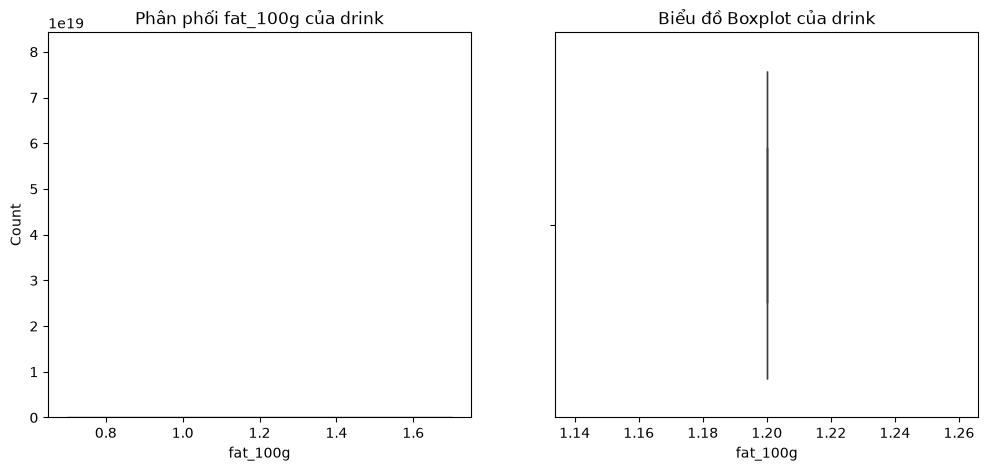

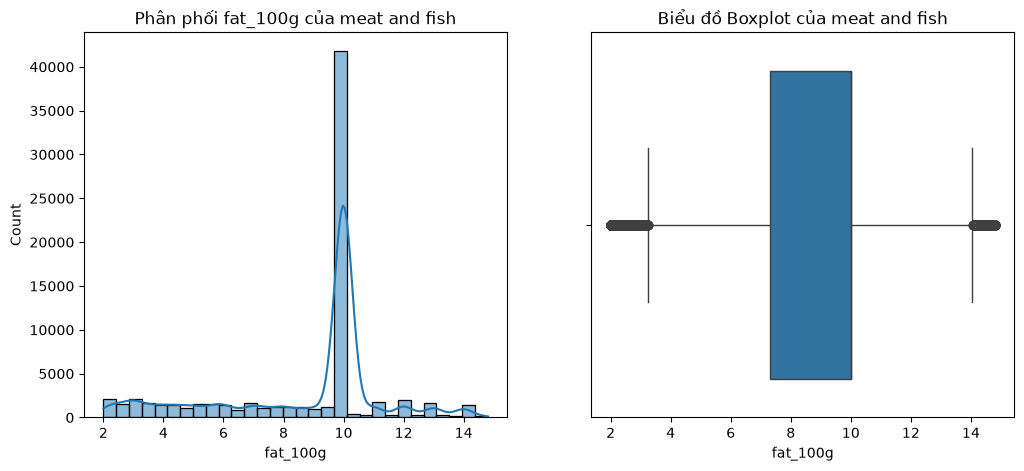

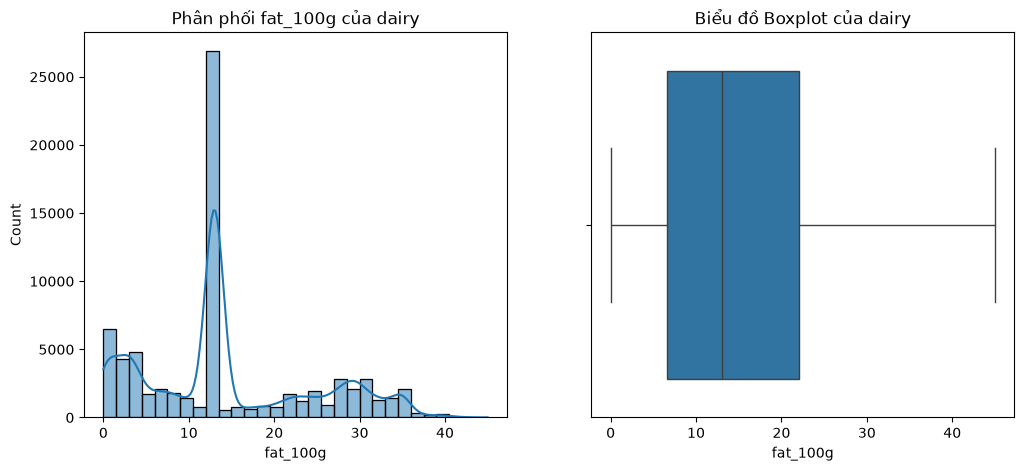

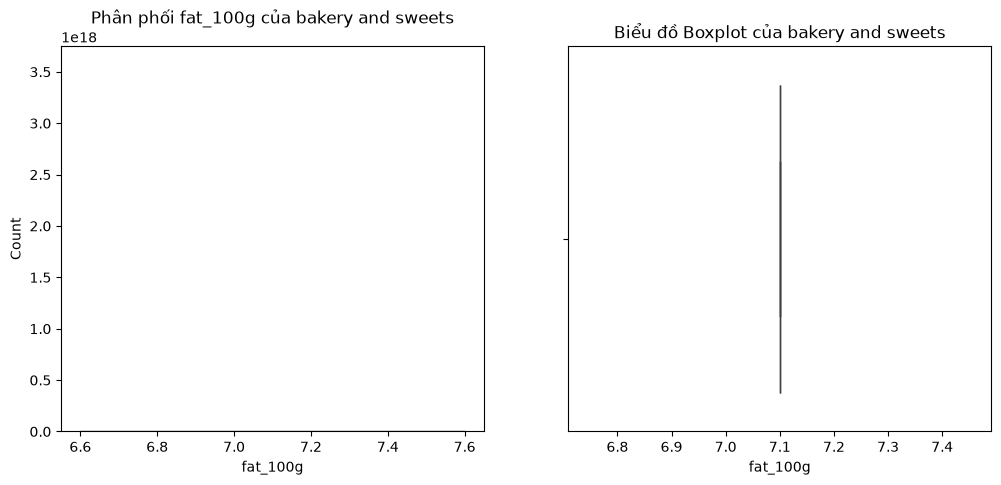

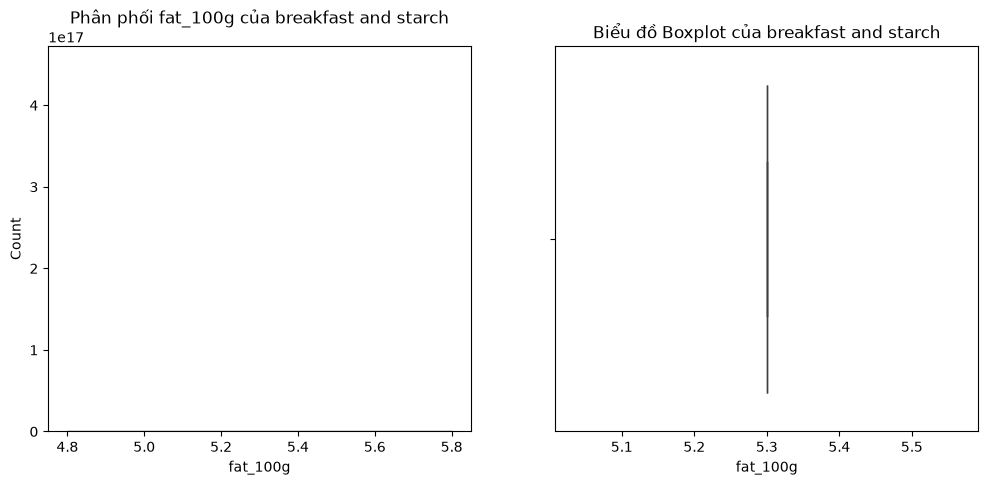

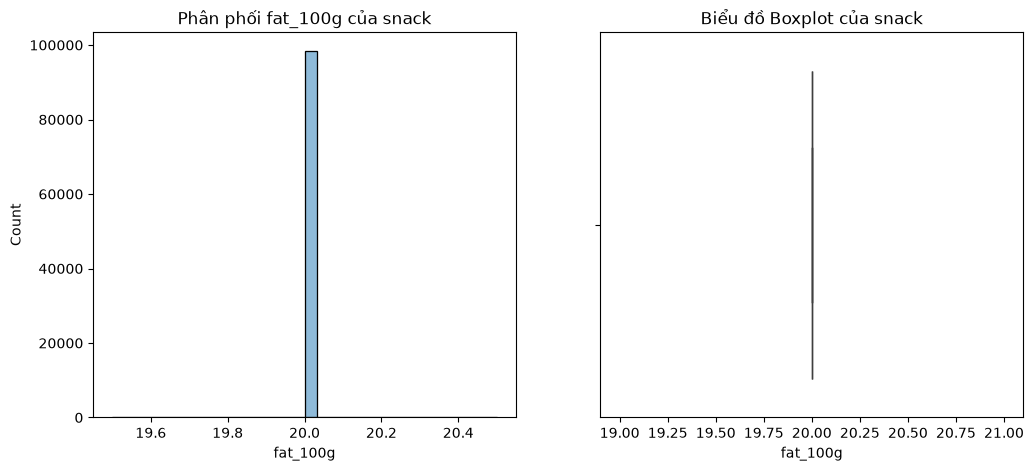

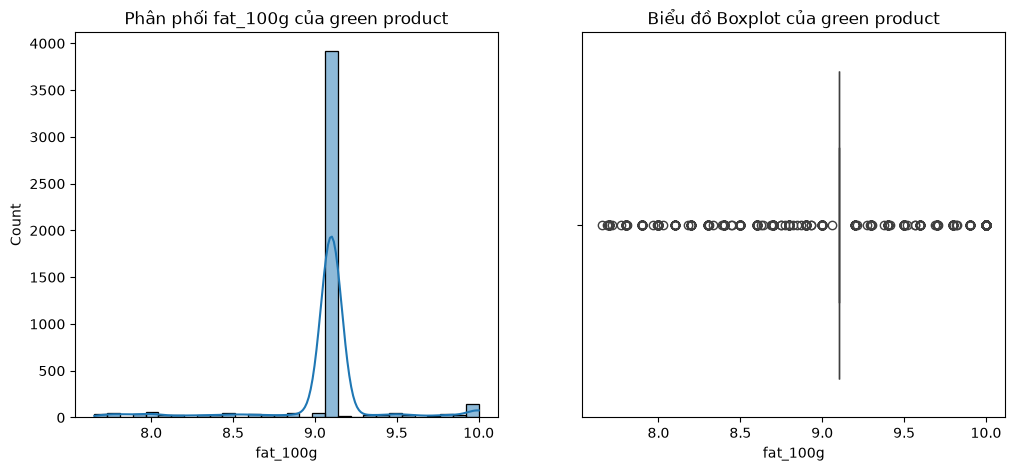

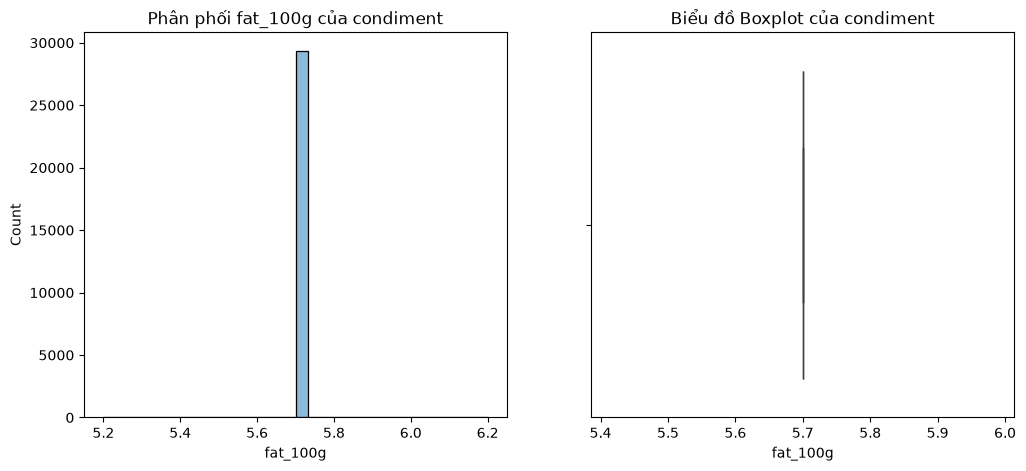

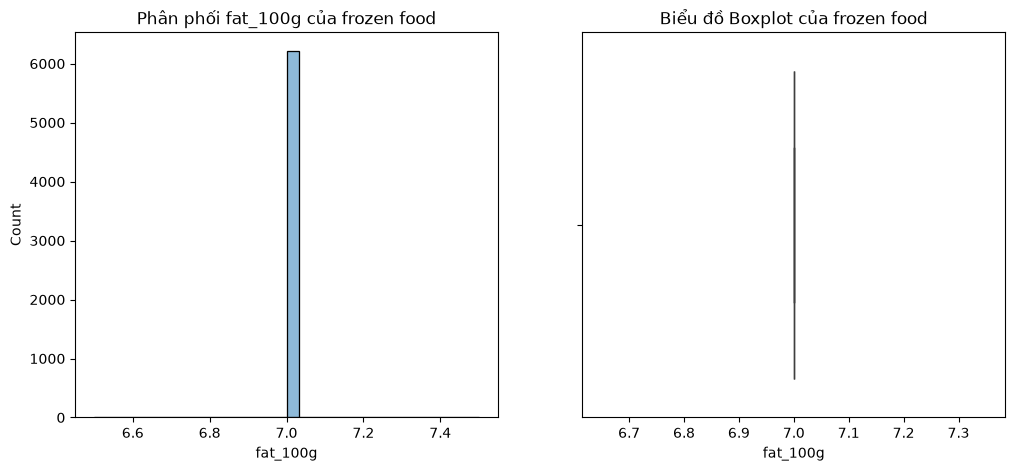

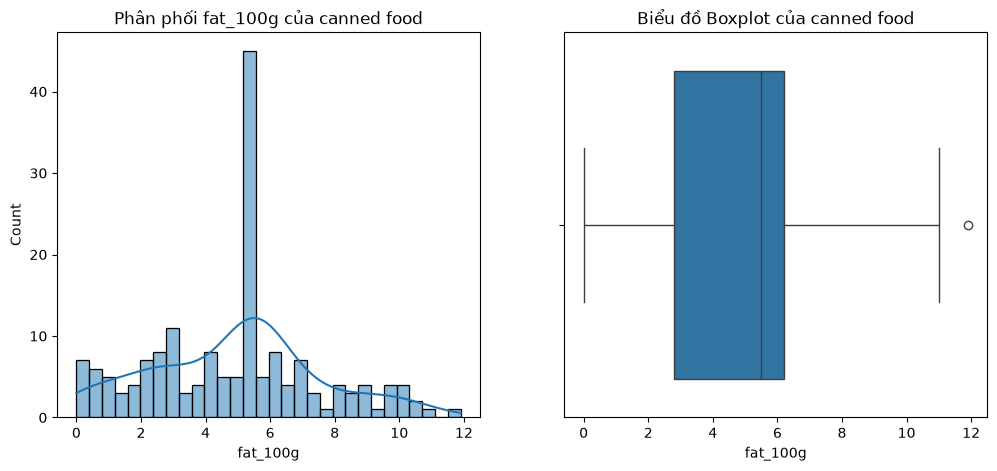

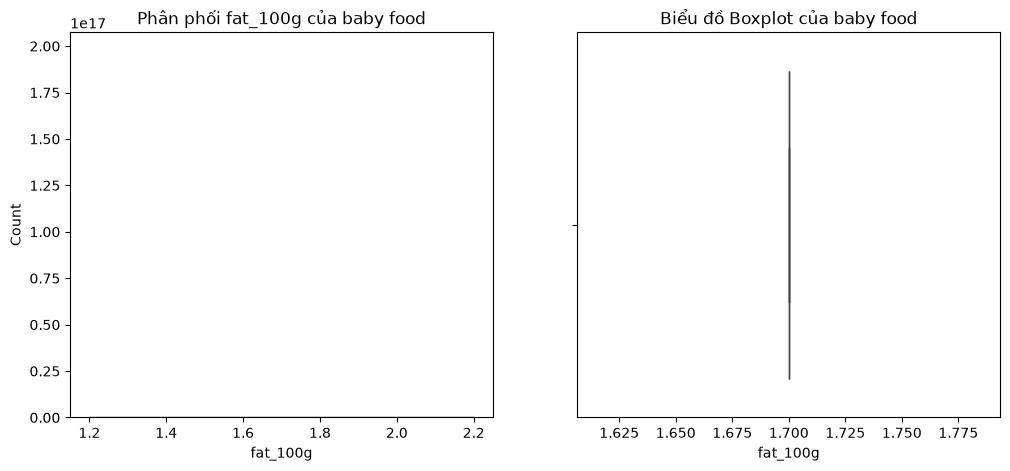

In [173]:
#### biến fat_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'fat_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['fat_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối fat_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['fat_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

## saturated-fat_100g

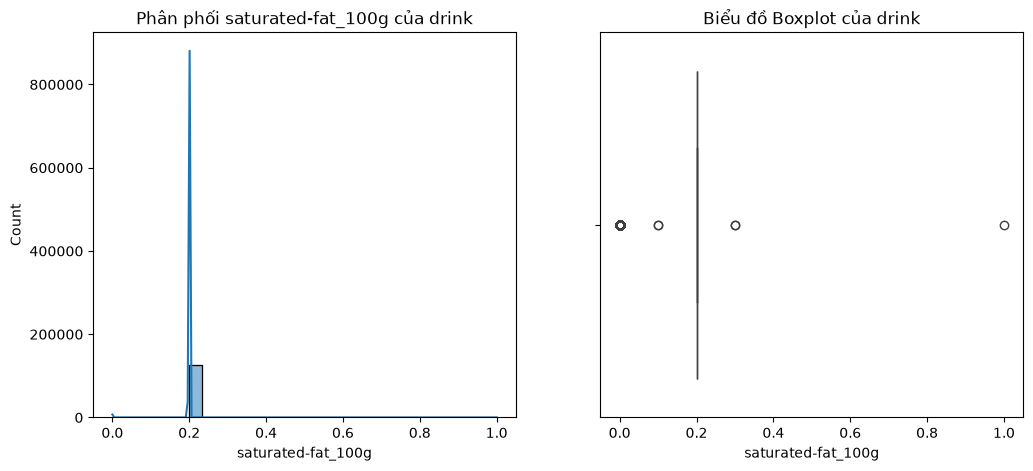

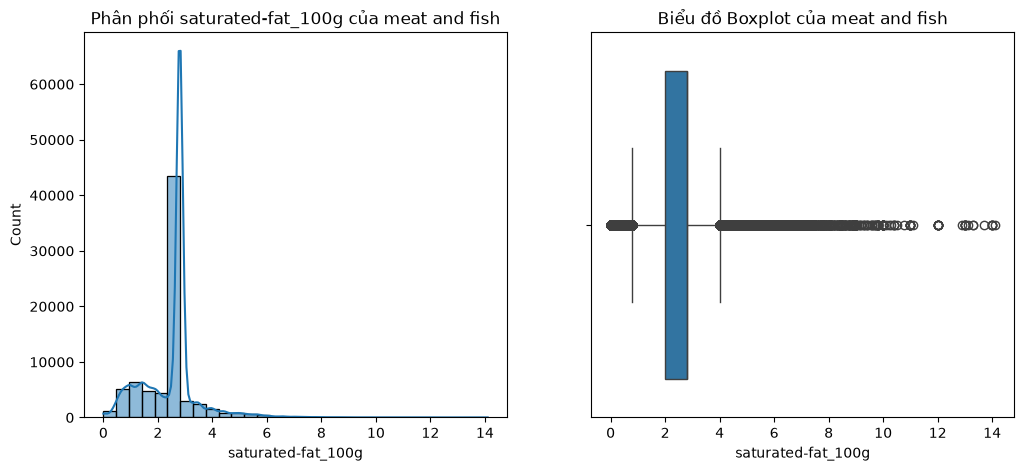

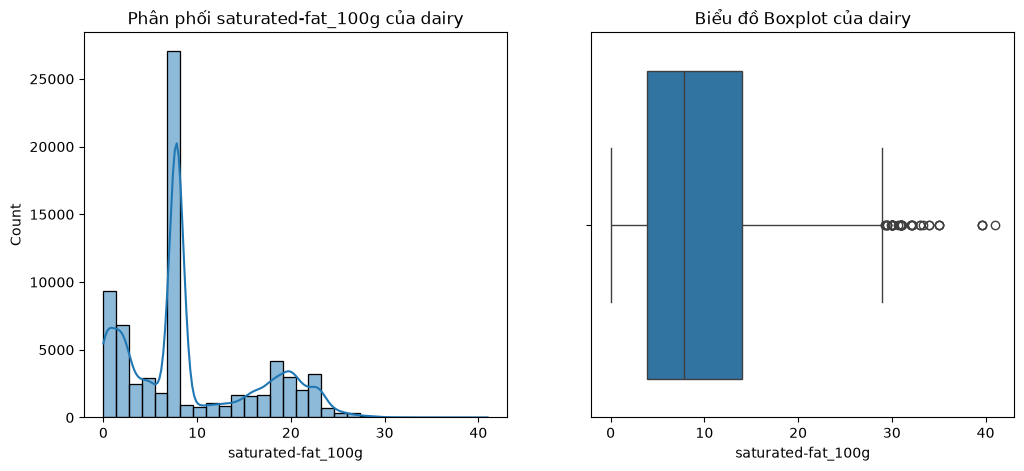

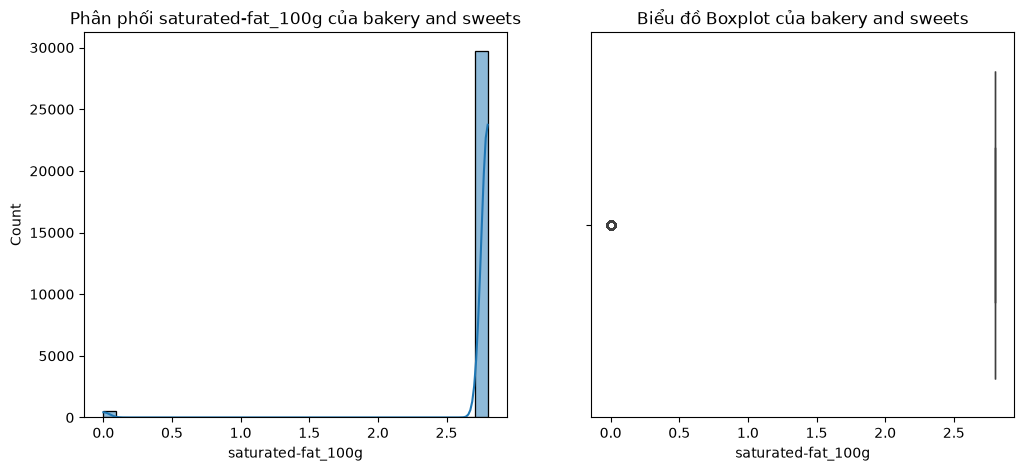

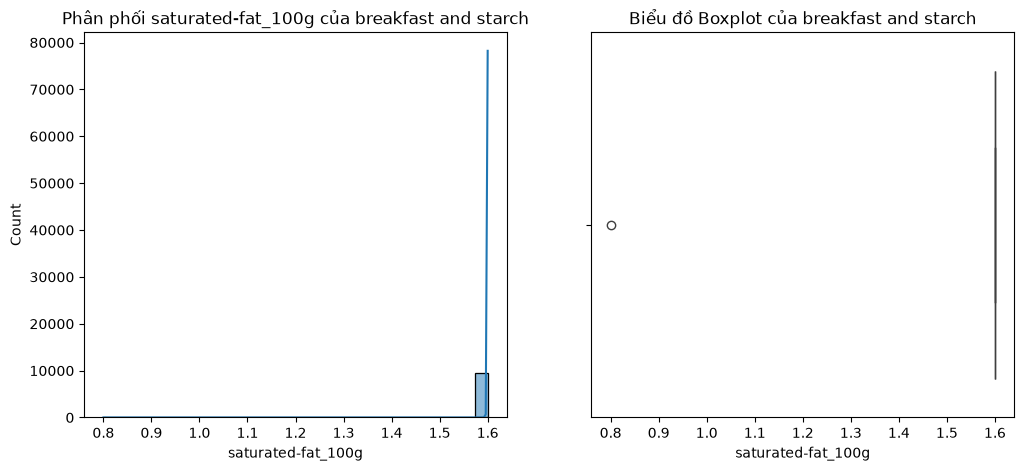

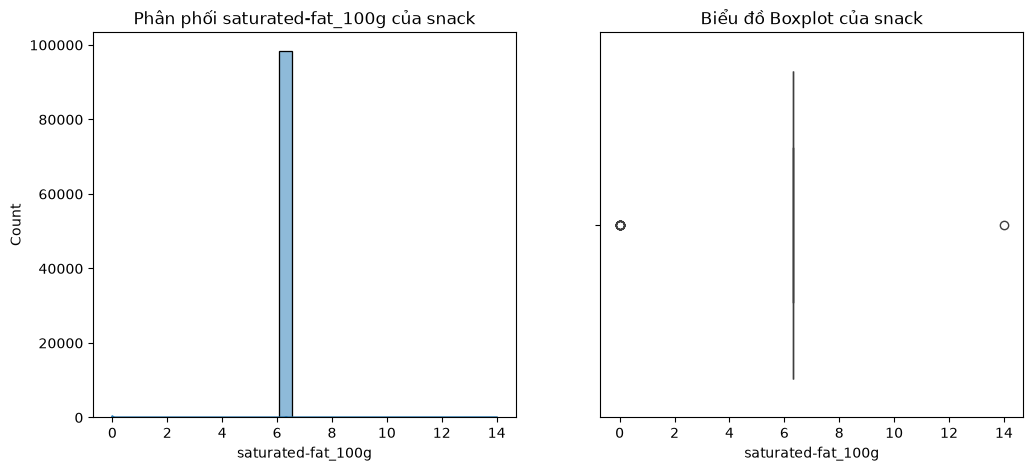

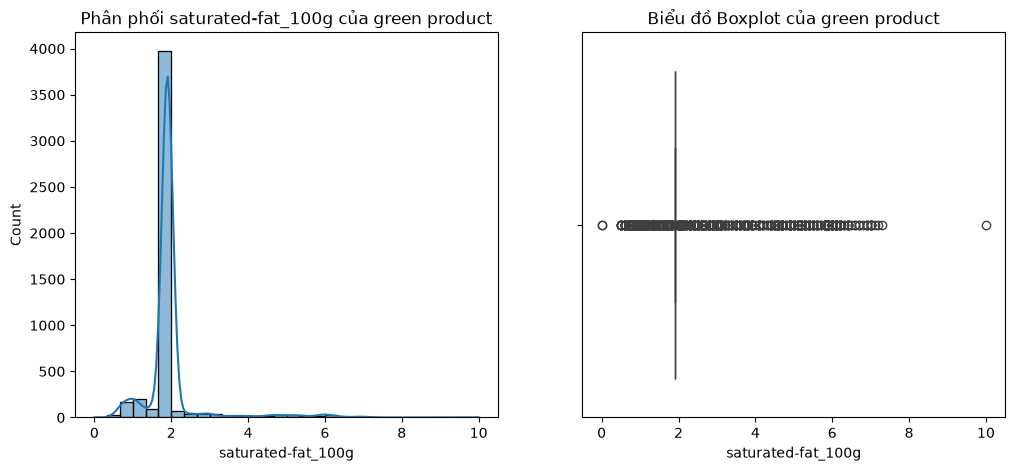

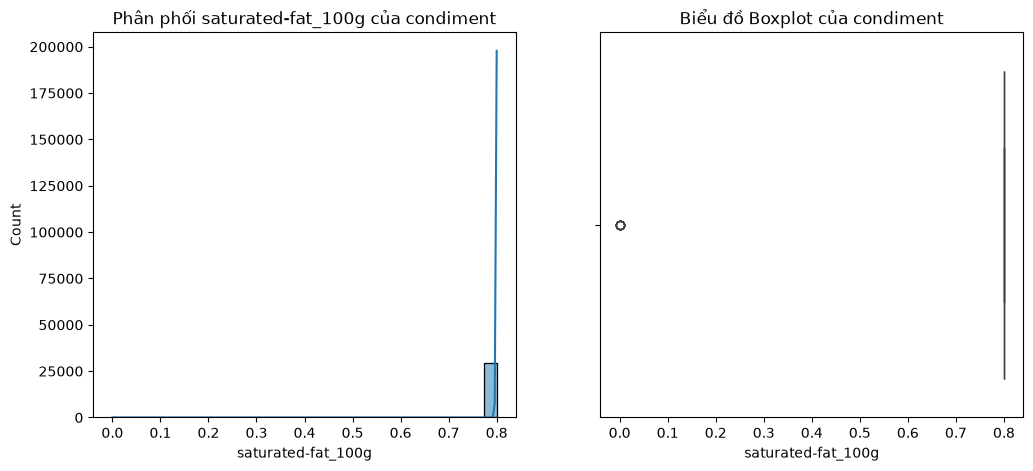

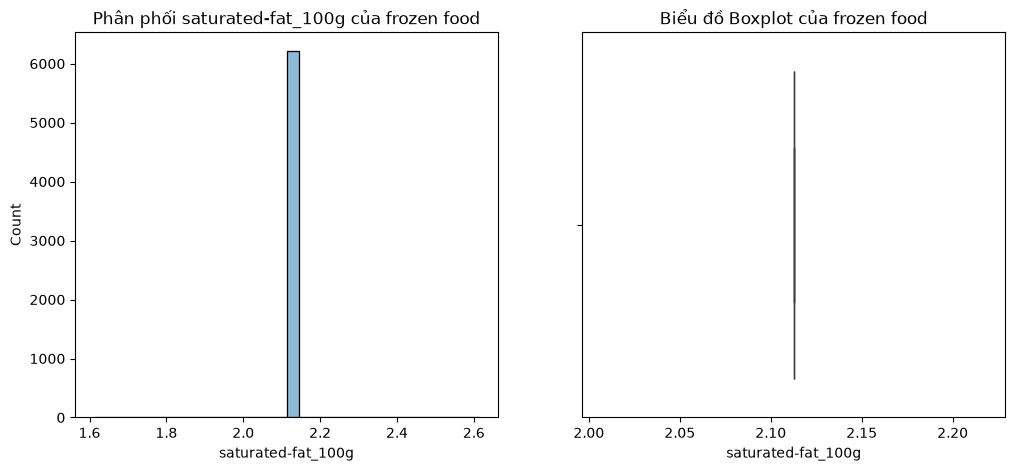

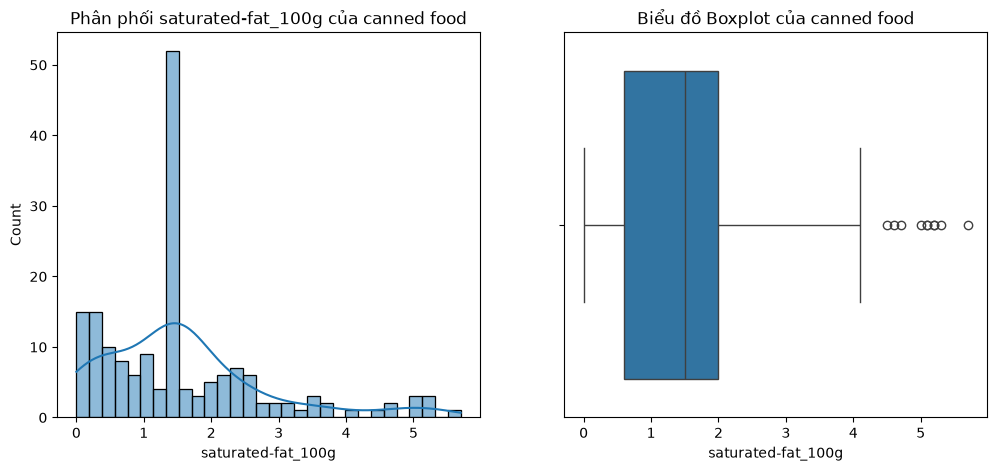

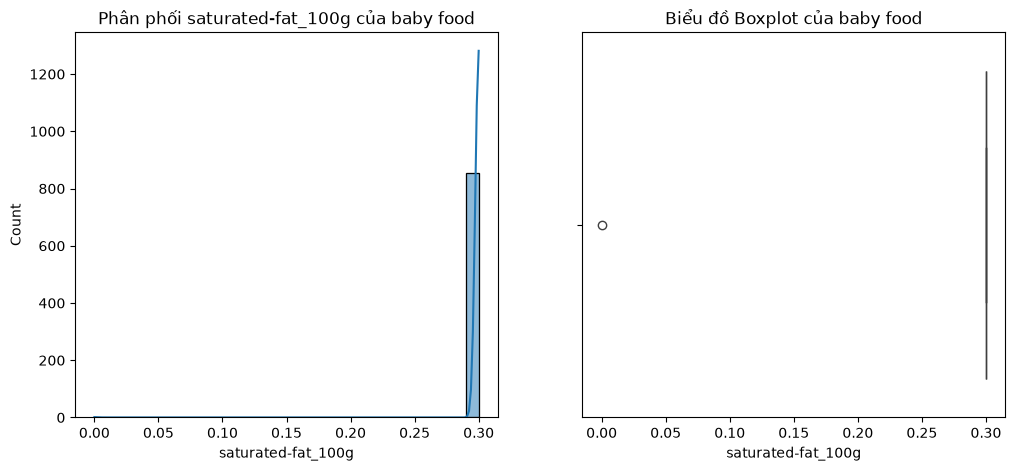

In [174]:
#### biến saturated-fat_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'saturated-fat_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['saturated-fat_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối saturated-fat_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['saturated-fat_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

Số lượng bản ghi trước khi lọc: 456151
Số lượng bản ghi sau khi lọc saturated-fat_100g outlier: 444392
Đã loại bỏ: 11759 sản phẩm có mức saturated-fat_100g ngoại lai theo từng nhóm.


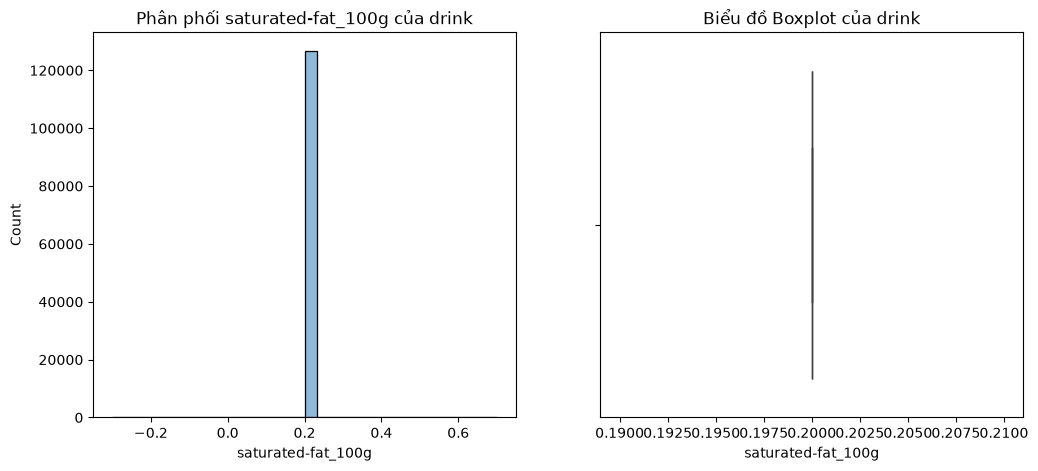

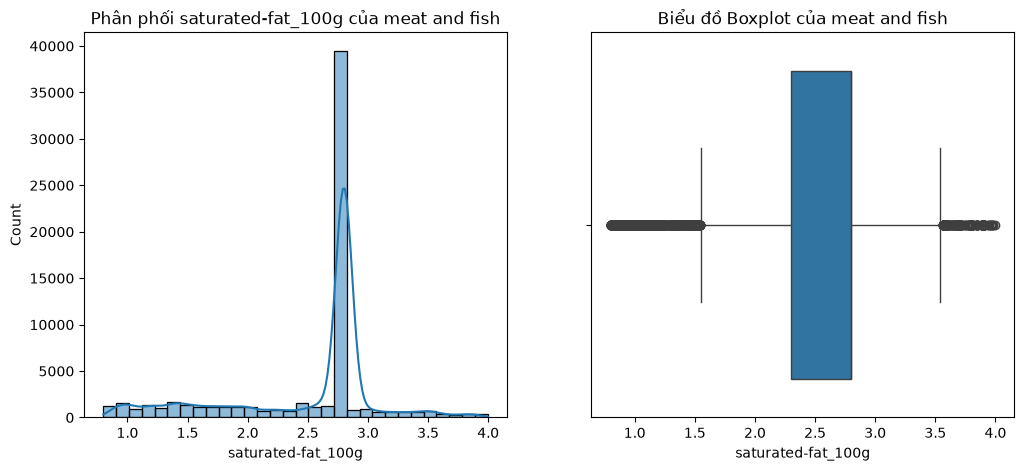

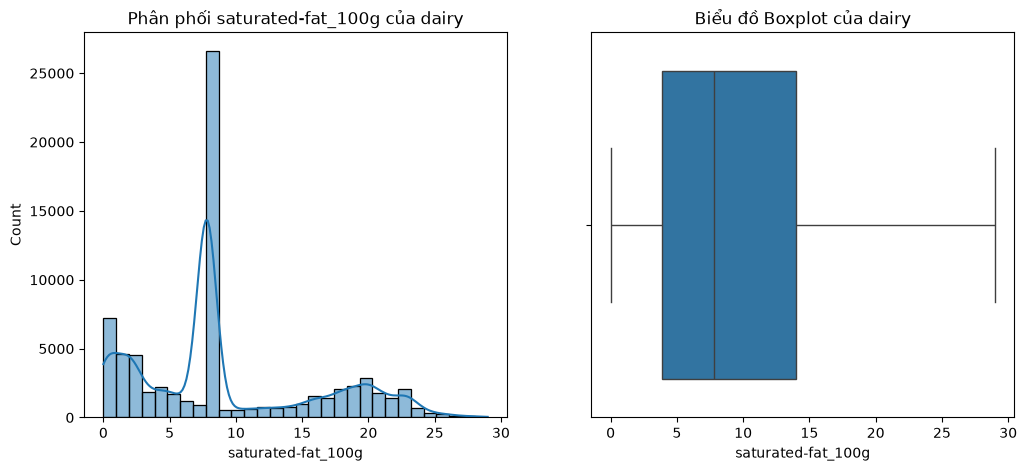

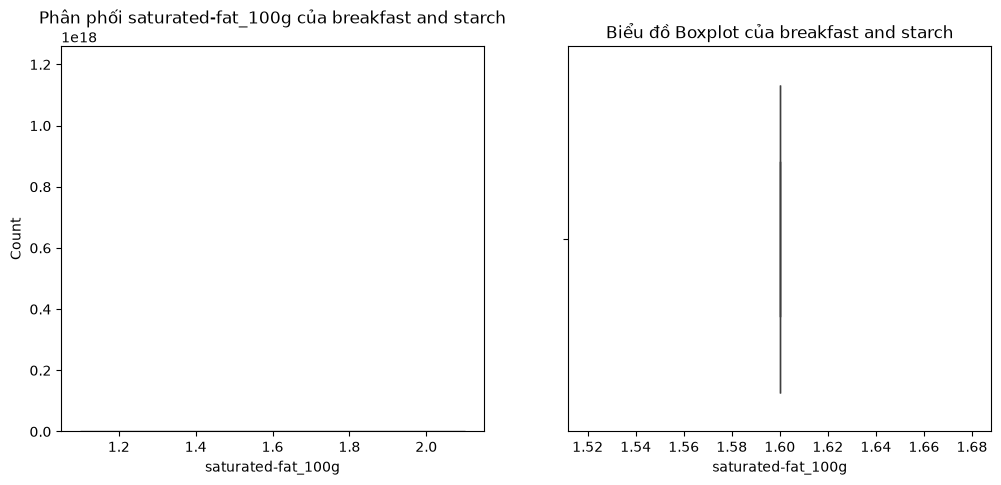

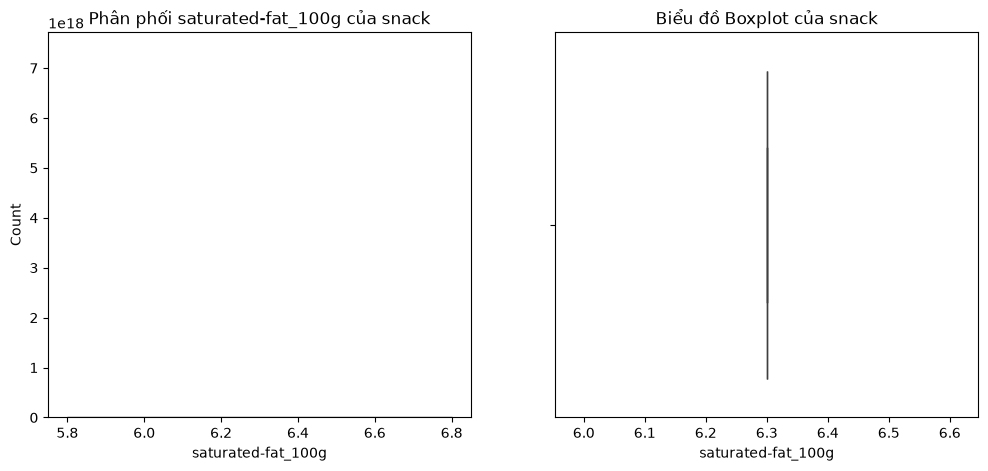

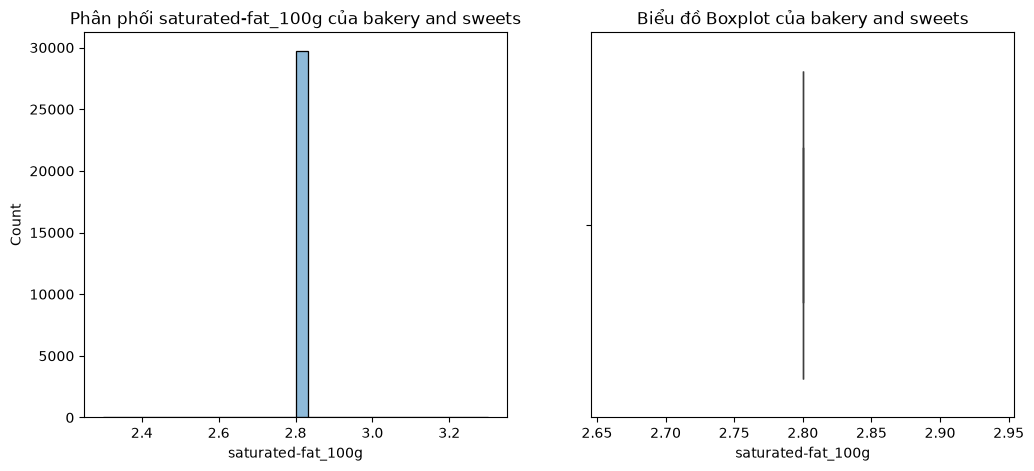

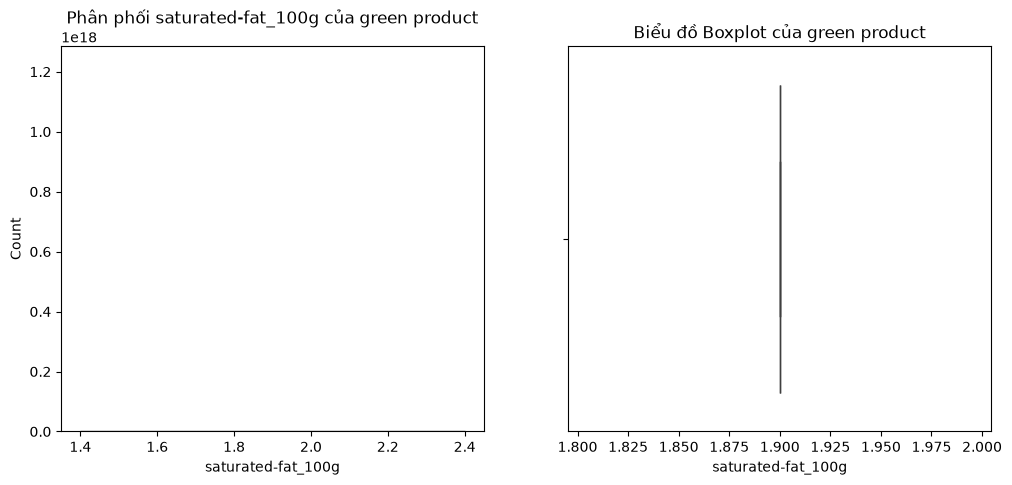

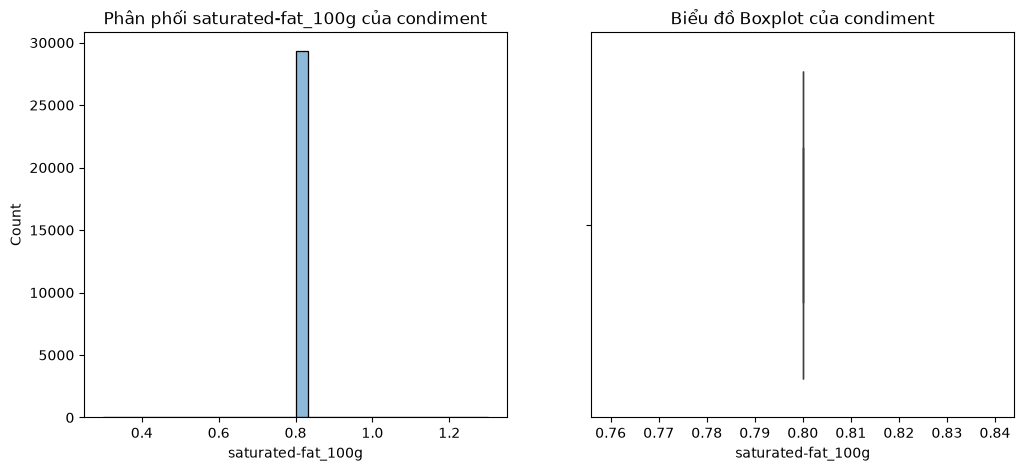

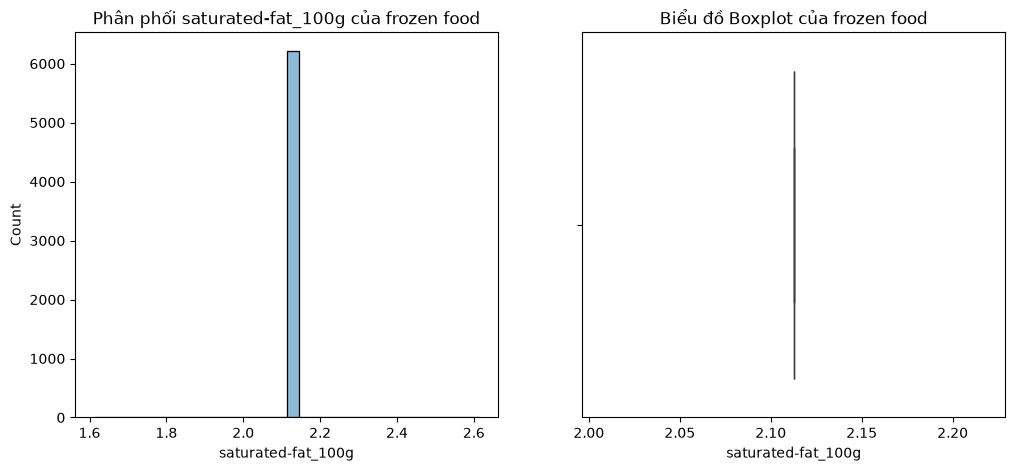

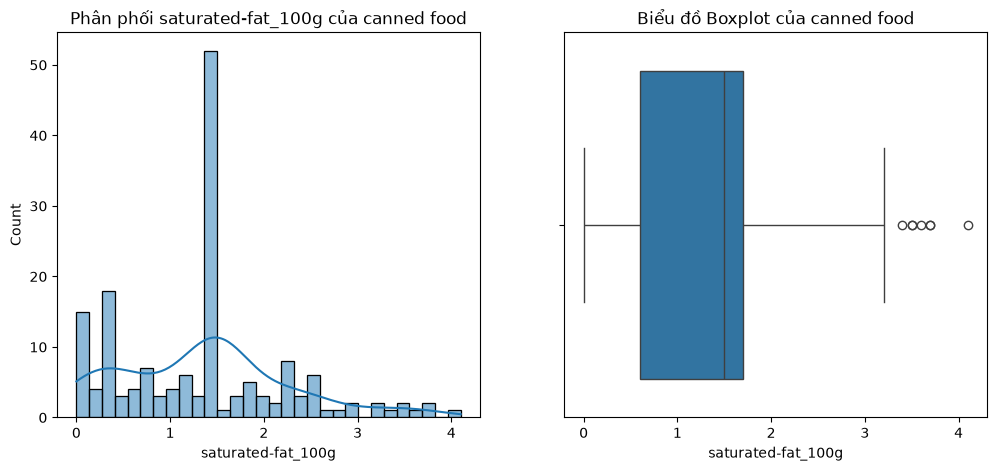

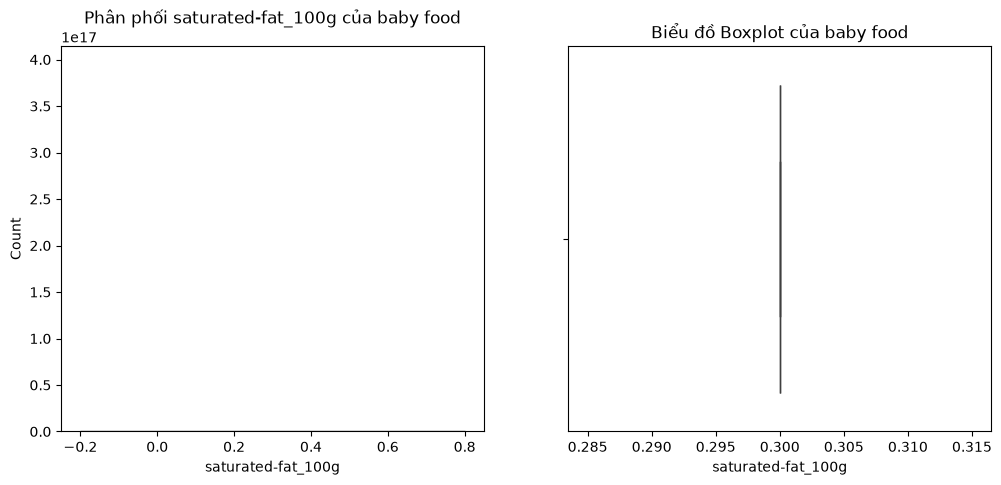

In [175]:
### Lọc outlier của saturated-fat_100g

def remove_nova_outliers_per_category(df):
    initial_count = len(df)

    # Tính Q1, Q3 cho saturated-fat_100g theo từng nhóm
    groups = df.groupby('general_category')['saturated-fat_100g']

    q1 = groups.transform(lambda x: x.quantile(0.25))
    q3 = groups.transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Lọc DataFrame
    df_filtered = df[(df['saturated-fat_100g'] >= lower_bound) & (df['saturated-fat_100g'] <= upper_bound)]

    print(f"Số lượng bản ghi trước khi lọc: {initial_count}")
    print(f"Số lượng bản ghi sau khi lọc saturated-fat_100g outlier: {len(df_filtered)}")
    print(f"Đã loại bỏ: {initial_count - len(df_filtered)} sản phẩm có mức saturated-fat_100g ngoại lai theo từng nhóm.")

    return df_filtered

# Thực thi
df_categorize = remove_nova_outliers_per_category(df_categorize)

#### biến saturated-fat_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'saturated-fat_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['saturated-fat_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối saturated-fat_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['saturated-fat_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

## carbohydrates_100g

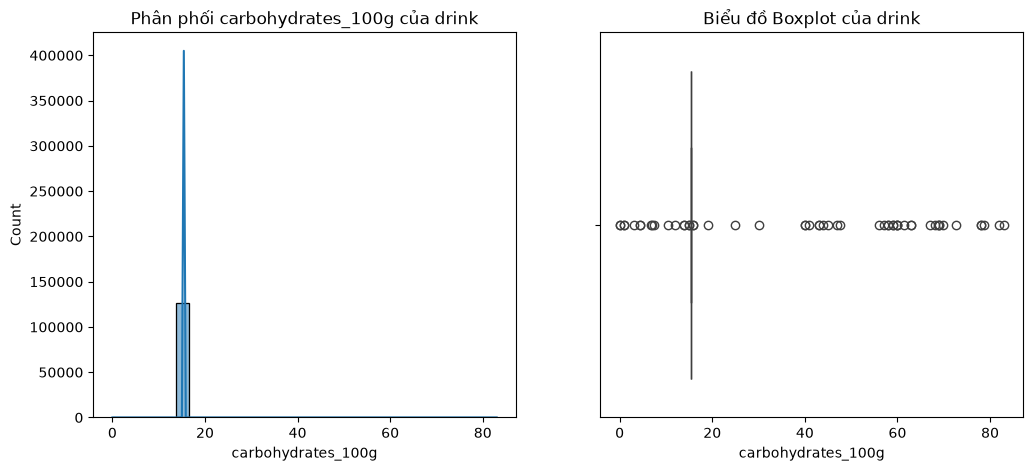

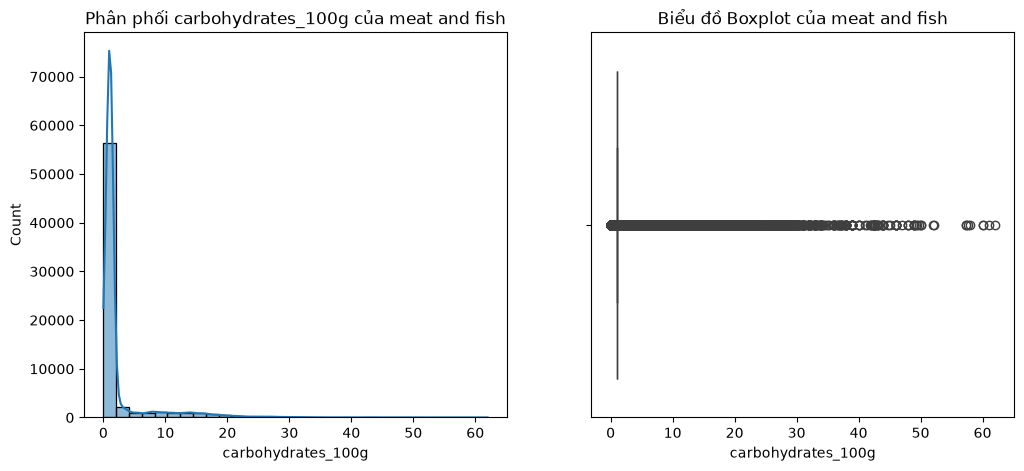

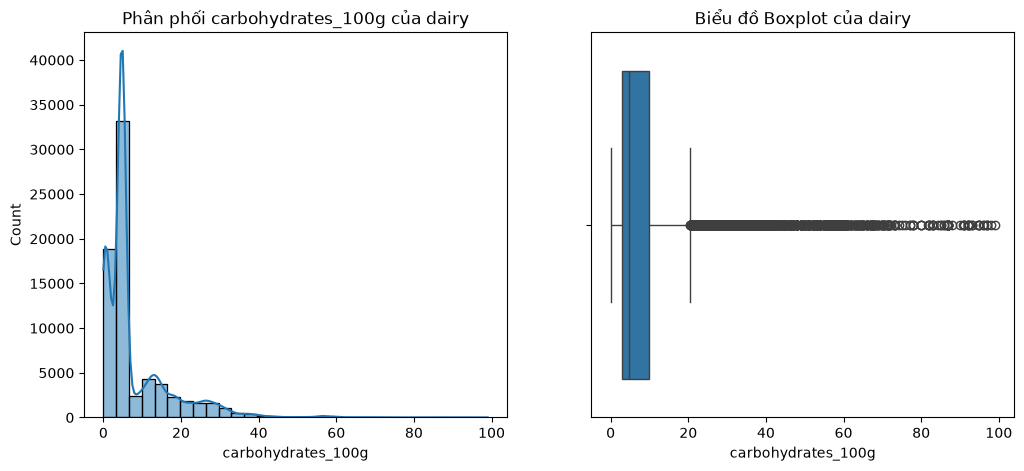

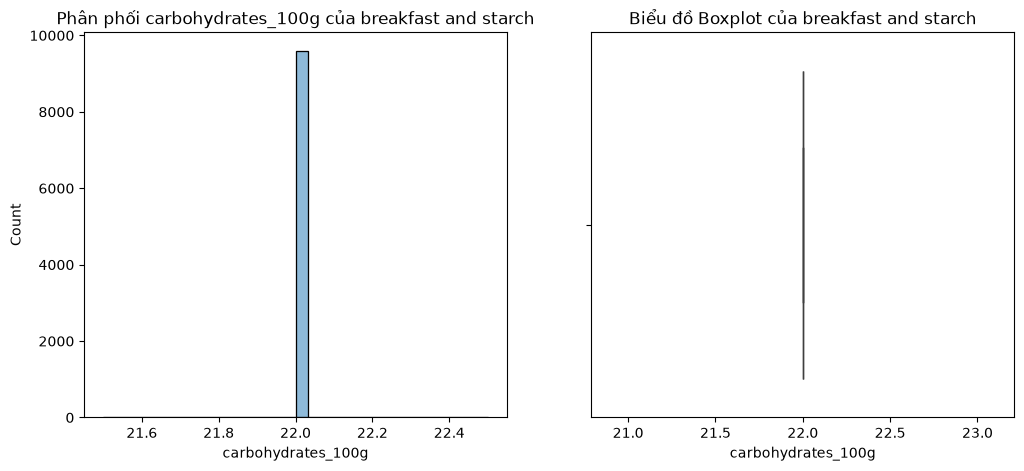

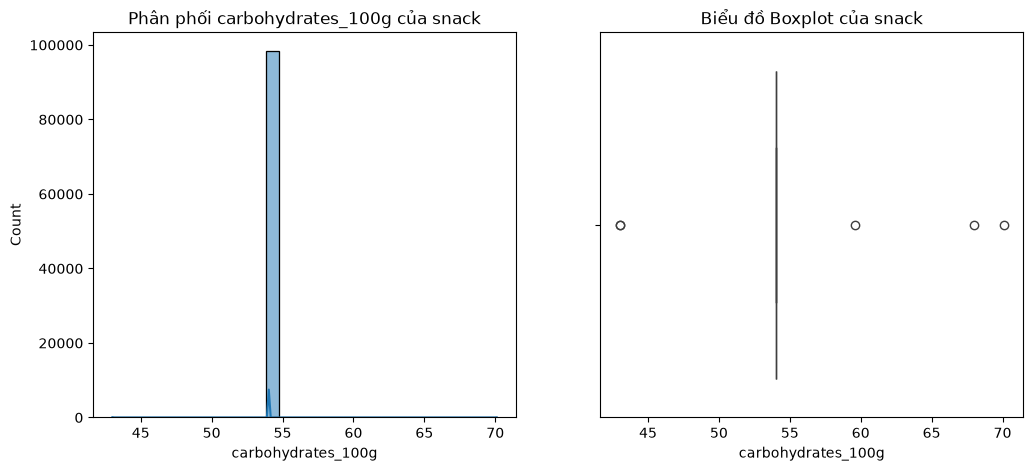

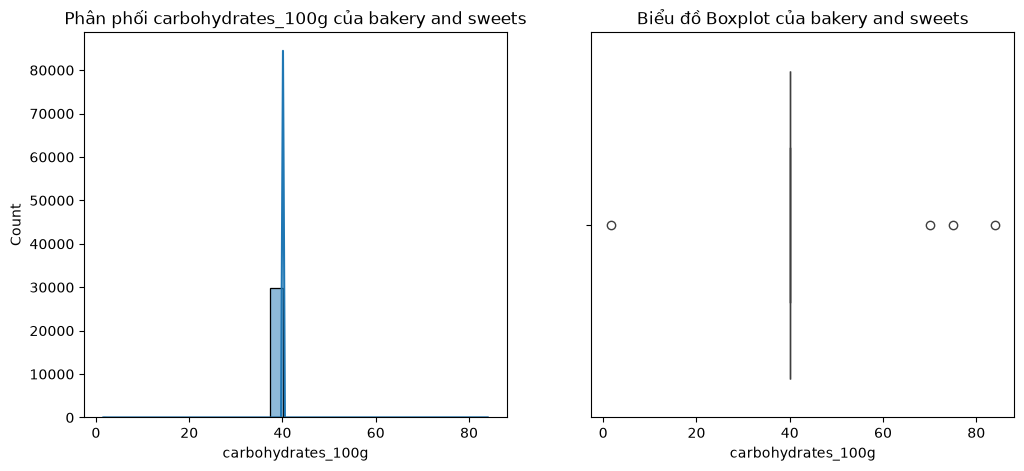

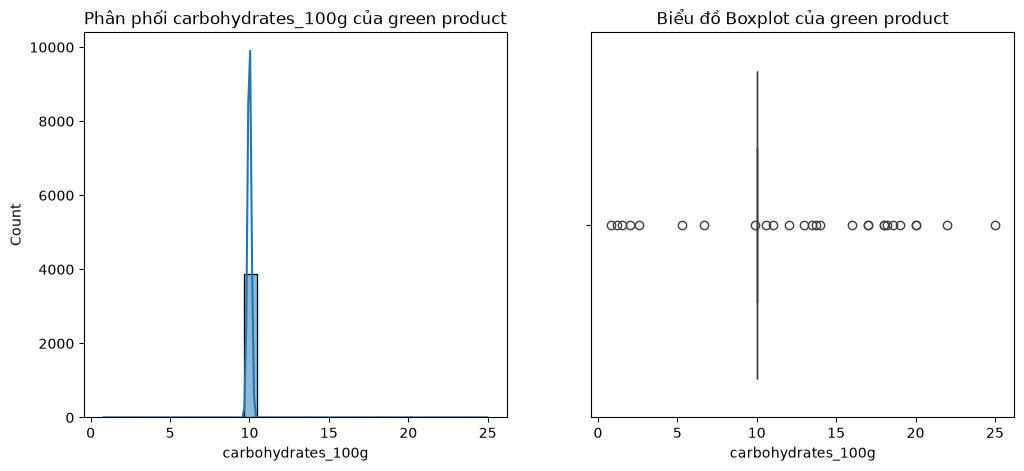

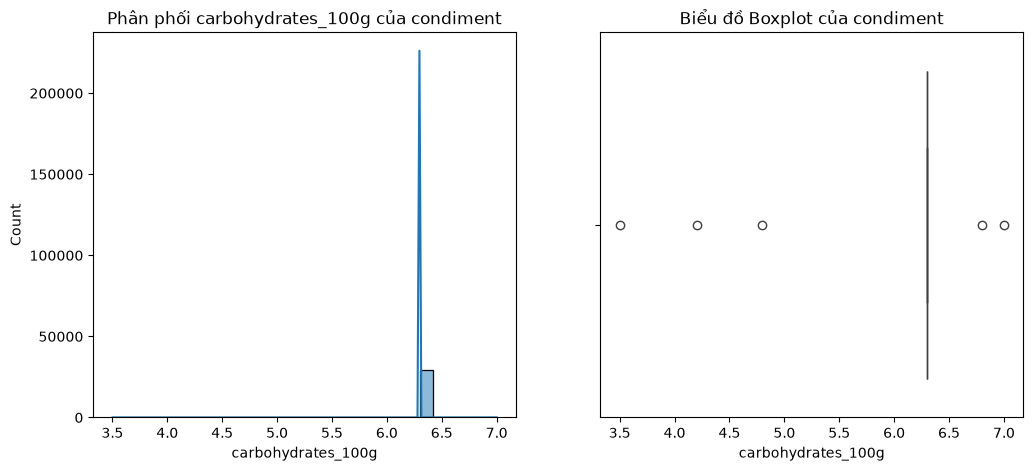

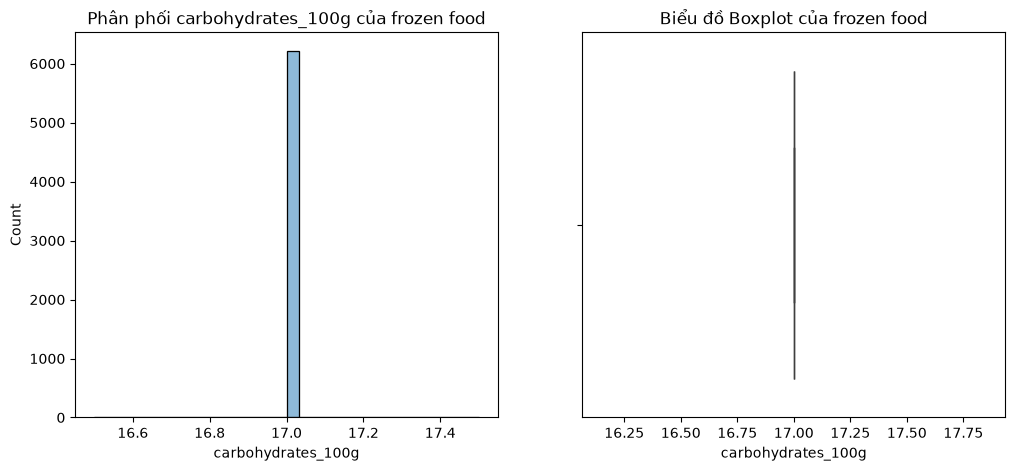

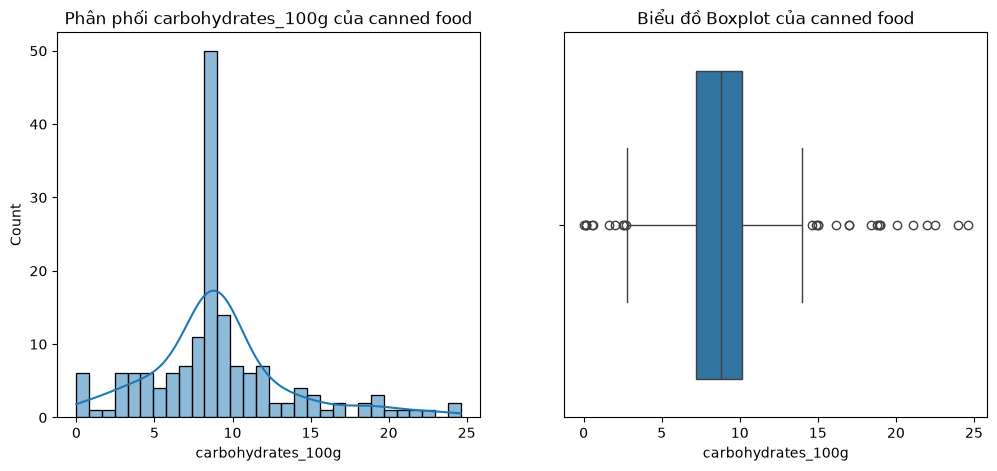

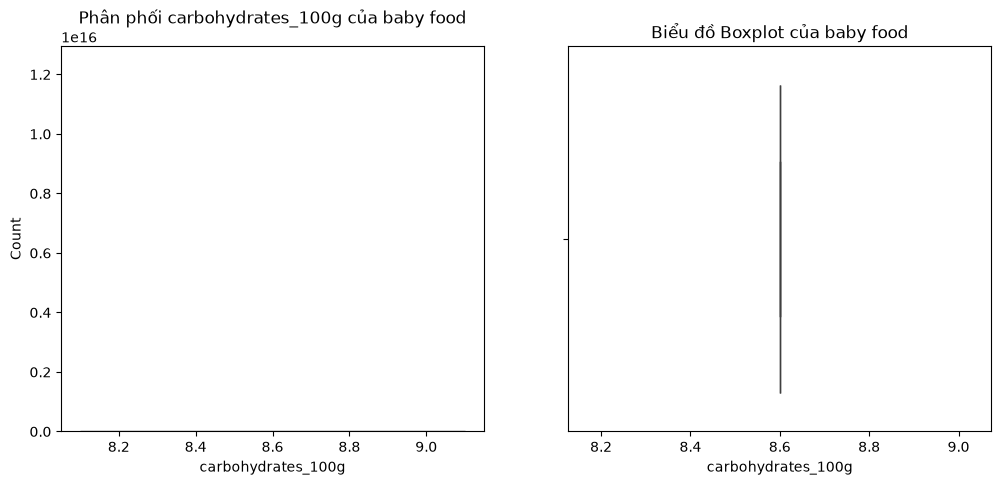

In [176]:
#### biến carbohydrates_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'carbohydrates_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['carbohydrates_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối carbohydrates_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['carbohydrates_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

Số lượng bản ghi trước khi lọc: 444392
Số lượng bản ghi sau khi lọc carbohydrates_100g outlier: 408986
Đã loại bỏ: 35406 sản phẩm có mức carbohydrates_100g ngoại lai theo từng nhóm.


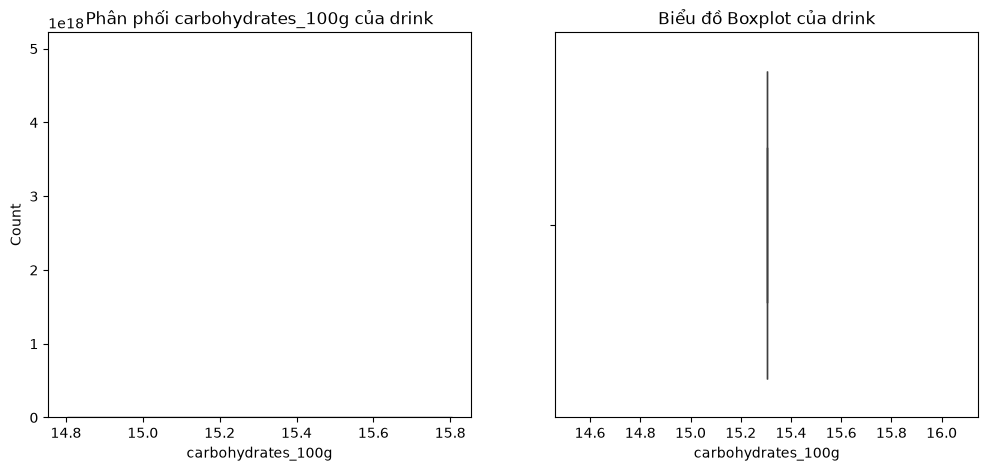

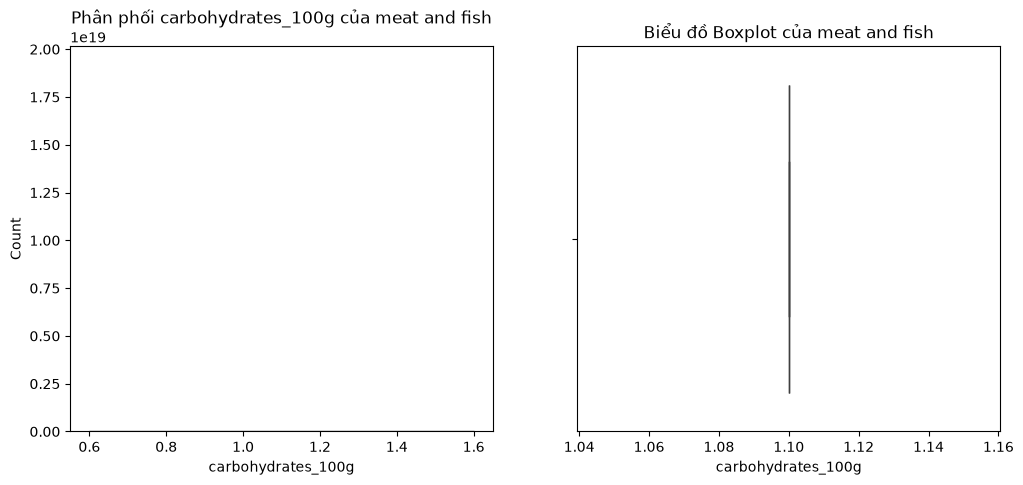

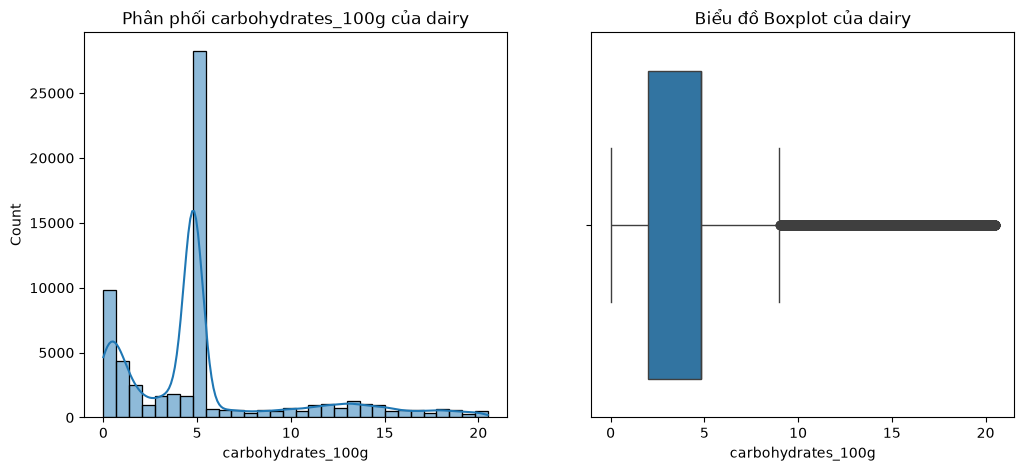

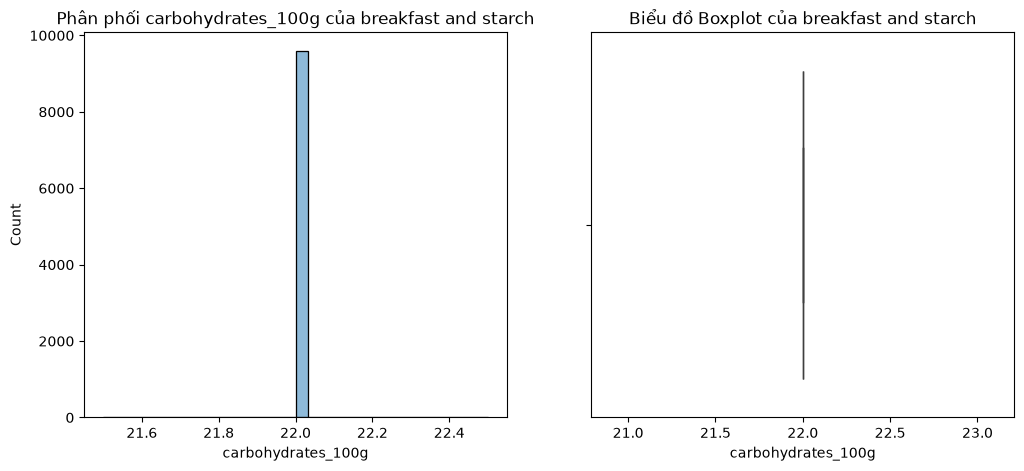

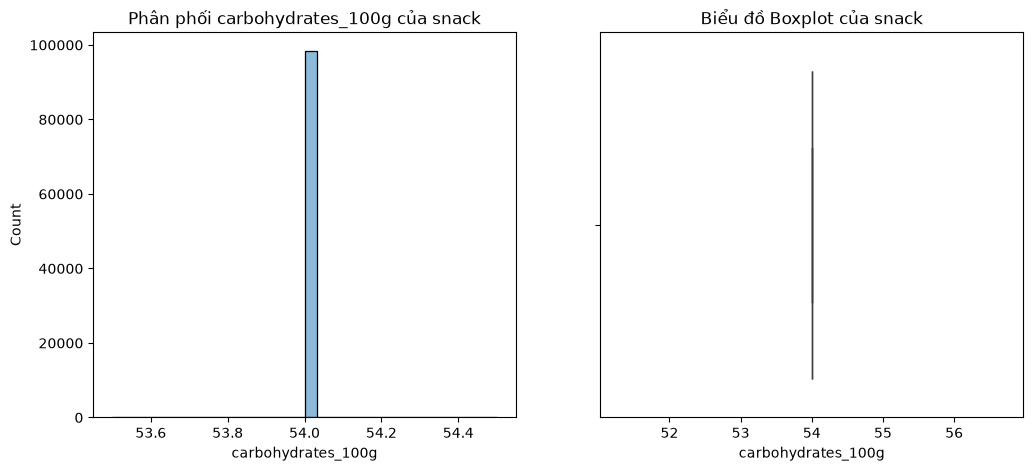

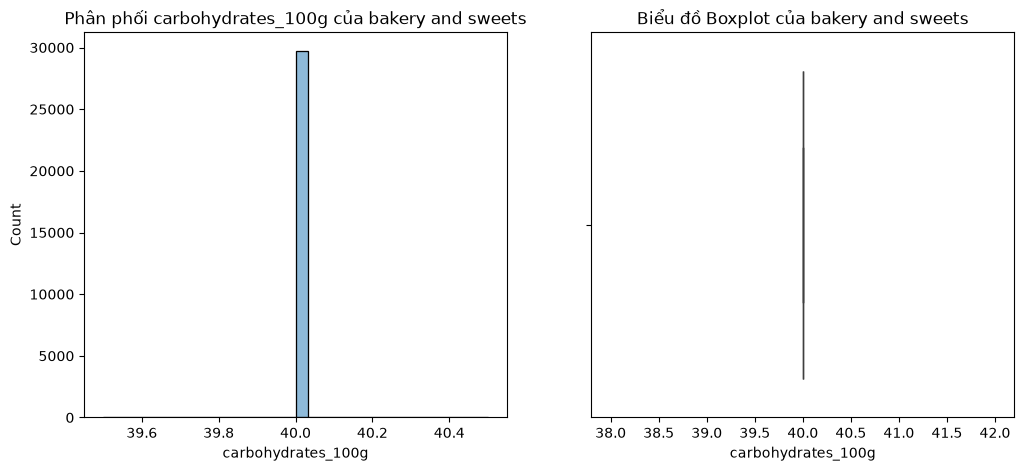

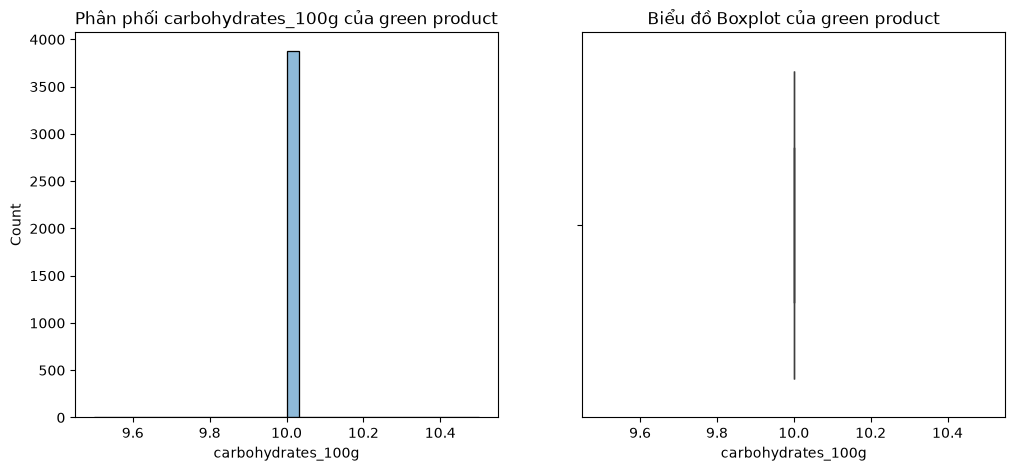

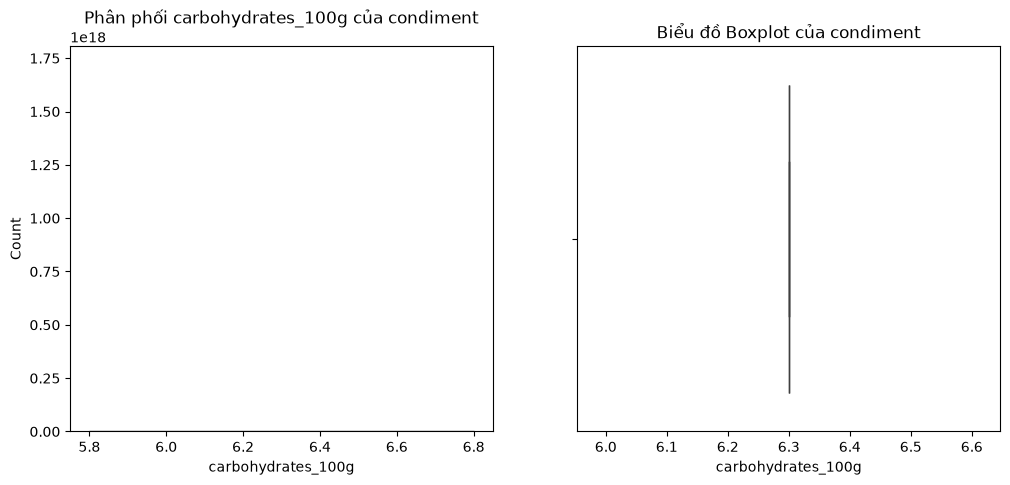

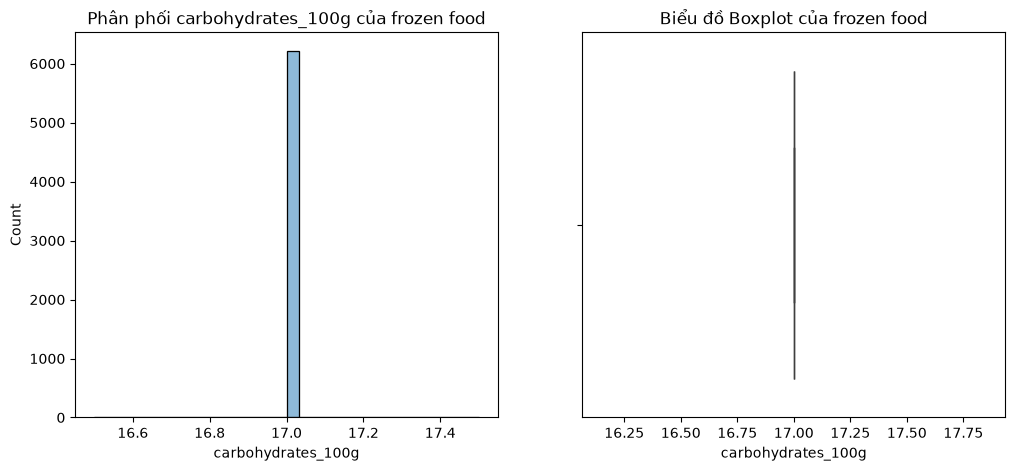

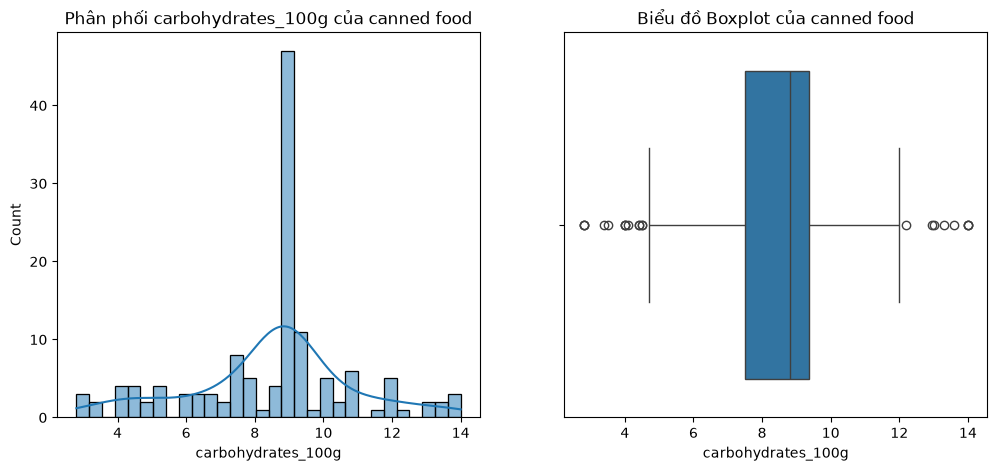

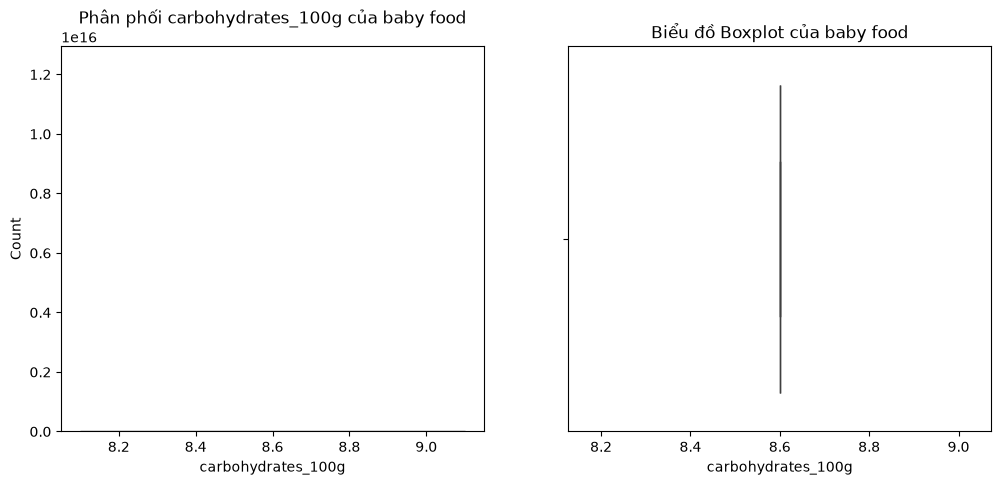

In [177]:
### Lọc outlier của carbohydrates_100g

def remove_nova_outliers_per_category(df):
    initial_count = len(df)

    # Tính Q1, Q3 cho carbohydrates_100g theo từng nhóm
    groups = df.groupby('general_category')['carbohydrates_100g']

    q1 = groups.transform(lambda x: x.quantile(0.25))
    q3 = groups.transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Lọc DataFrame
    df_filtered = df[(df['carbohydrates_100g'] >= lower_bound) & (df['carbohydrates_100g'] <= upper_bound)]

    print(f"Số lượng bản ghi trước khi lọc: {initial_count}")
    print(f"Số lượng bản ghi sau khi lọc carbohydrates_100g outlier: {len(df_filtered)}")
    print(f"Đã loại bỏ: {initial_count - len(df_filtered)} sản phẩm có mức carbohydrates_100g ngoại lai theo từng nhóm.")

    return df_filtered

# Thực thi
df_categorize = remove_nova_outliers_per_category(df_categorize)

#### biến carbohydrates_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'carbohydrates_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['carbohydrates_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối carbohydrates_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['carbohydrates_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

## sugars_100g

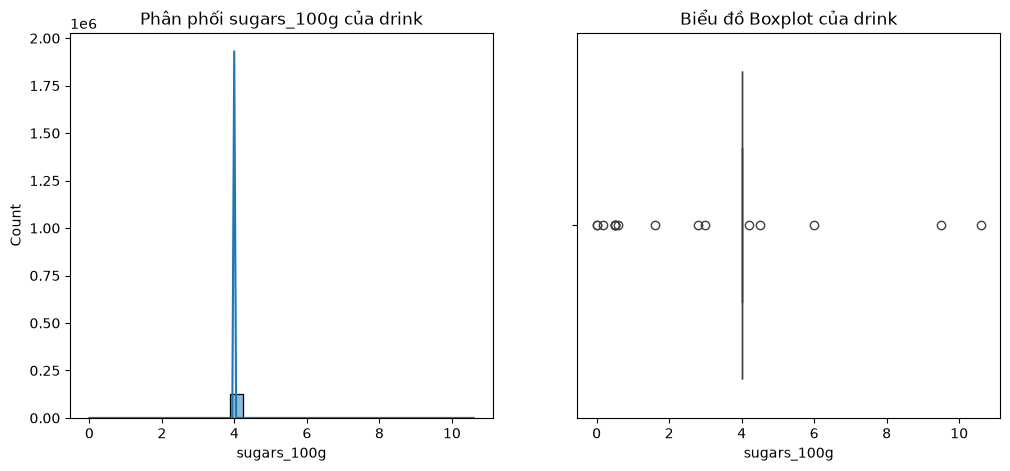

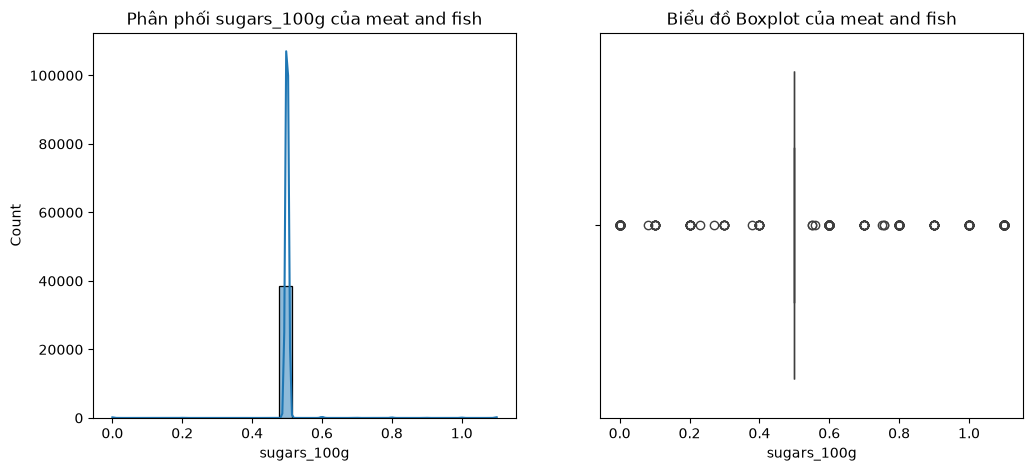

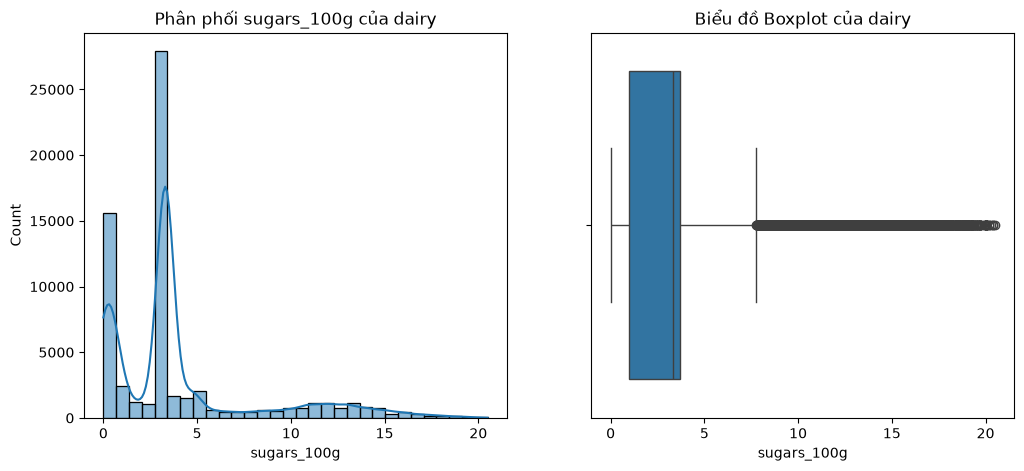

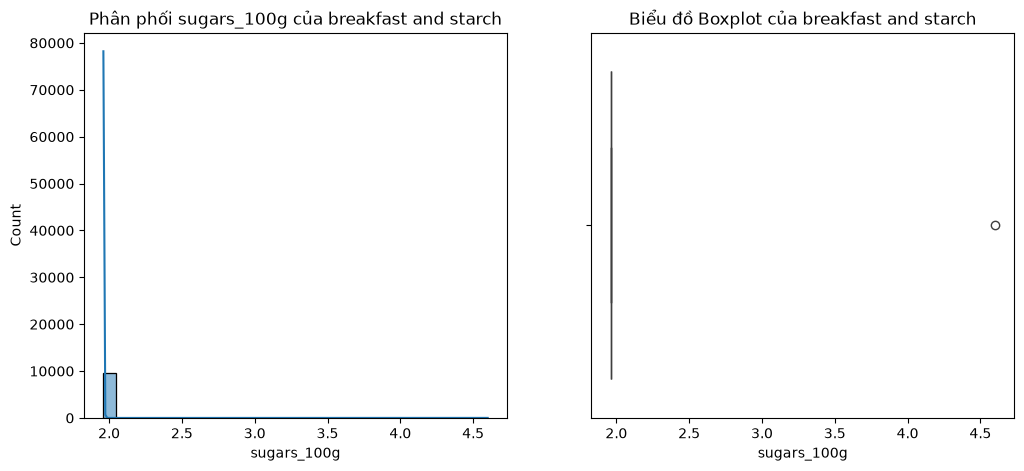

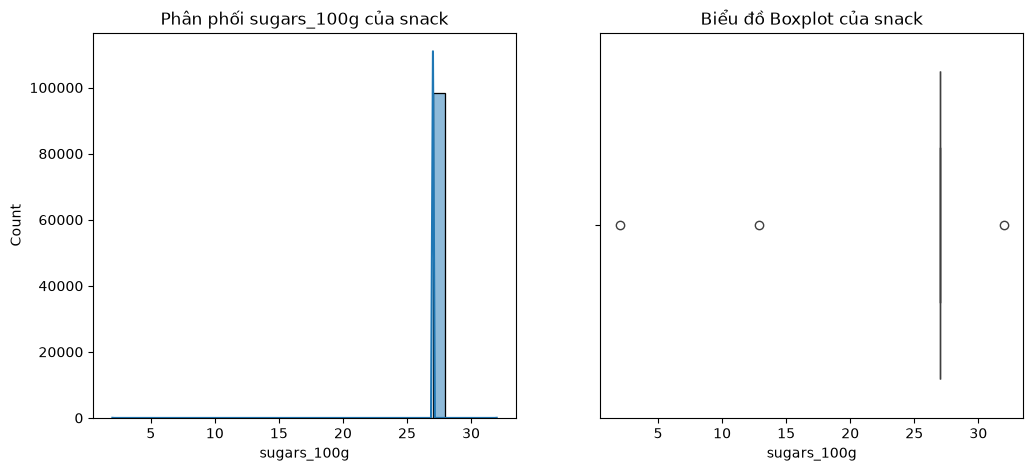

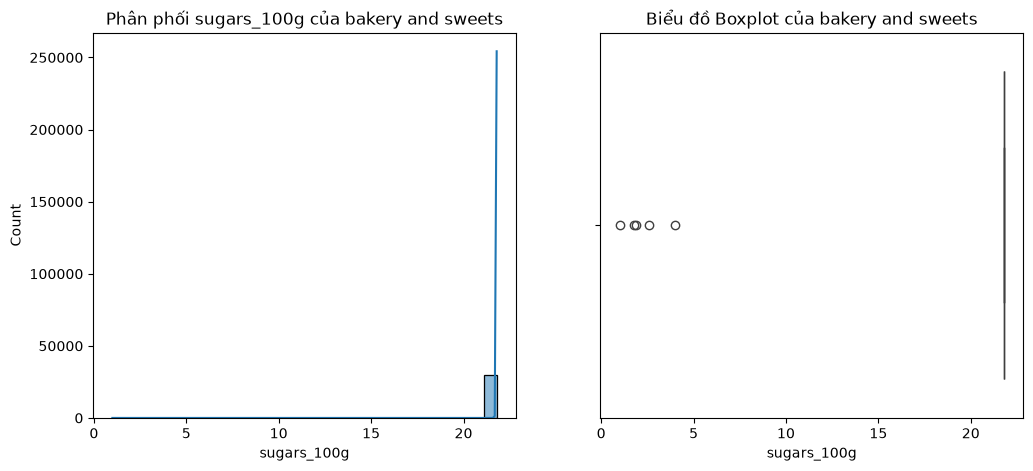

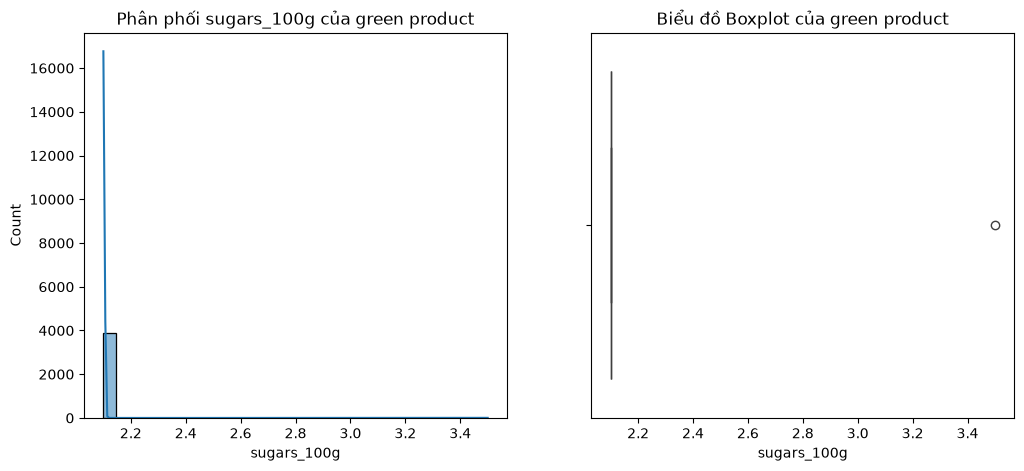

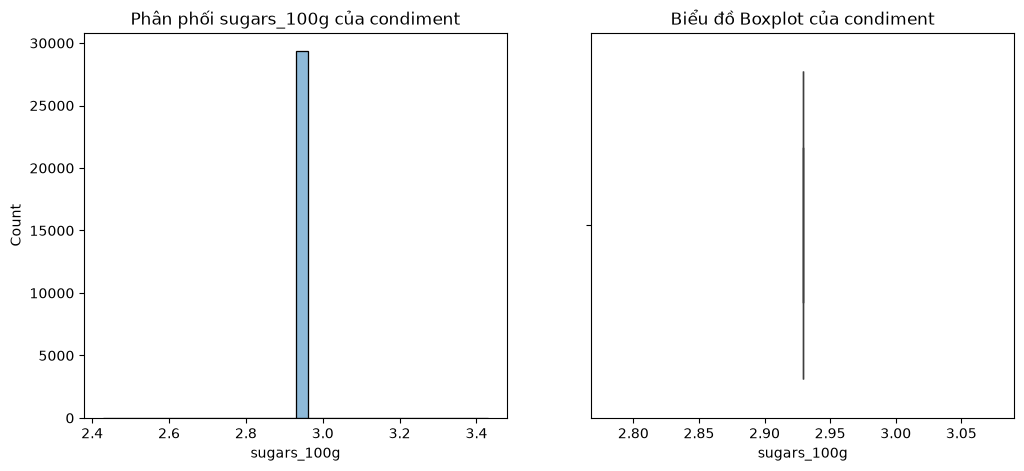

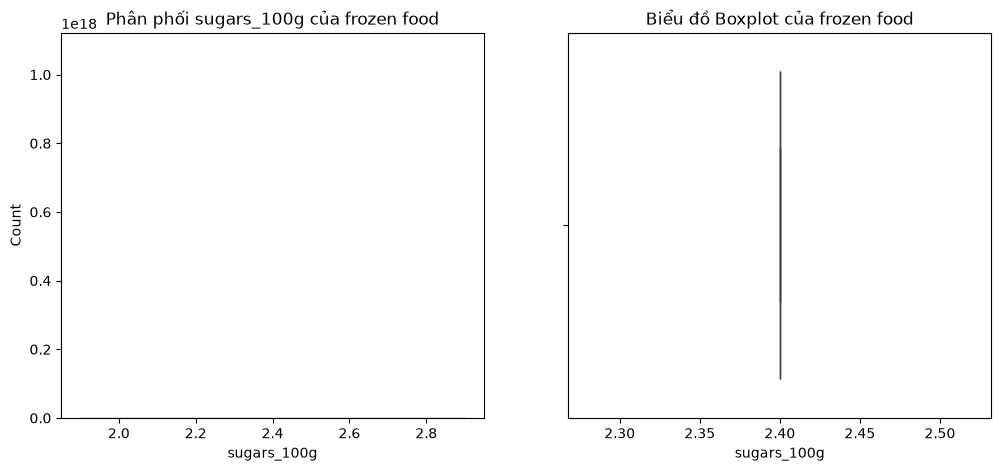

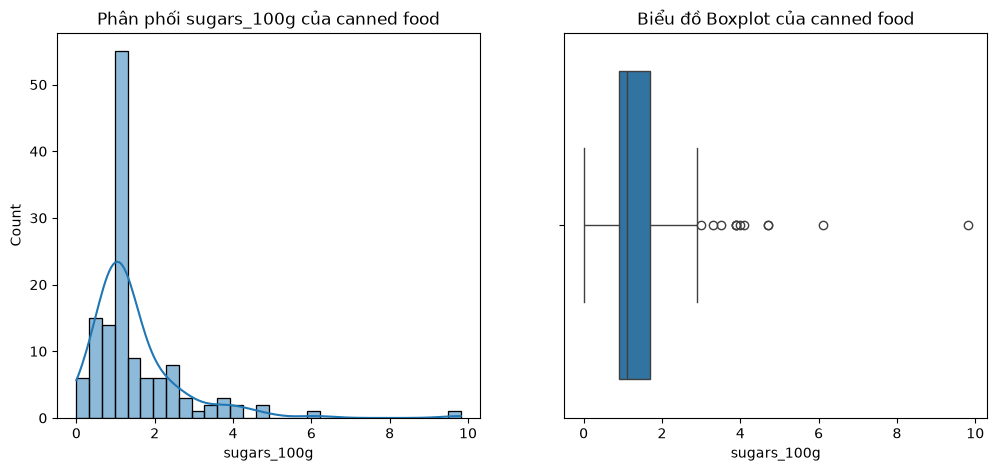

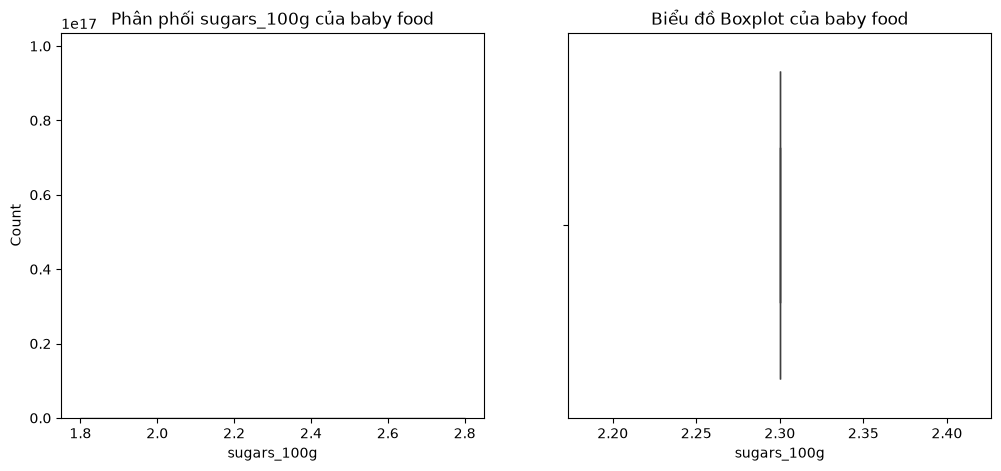

In [178]:
#### biến sugars_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'sugars_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['sugars_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối sugars_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['sugars_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

Số lượng bản ghi trước khi lọc: 408986
Số lượng bản ghi sau khi lọc sugars_100g outlier: 398262
Đã loại bỏ: 10724 sản phẩm có mức sugars_100g ngoại lai theo từng nhóm.


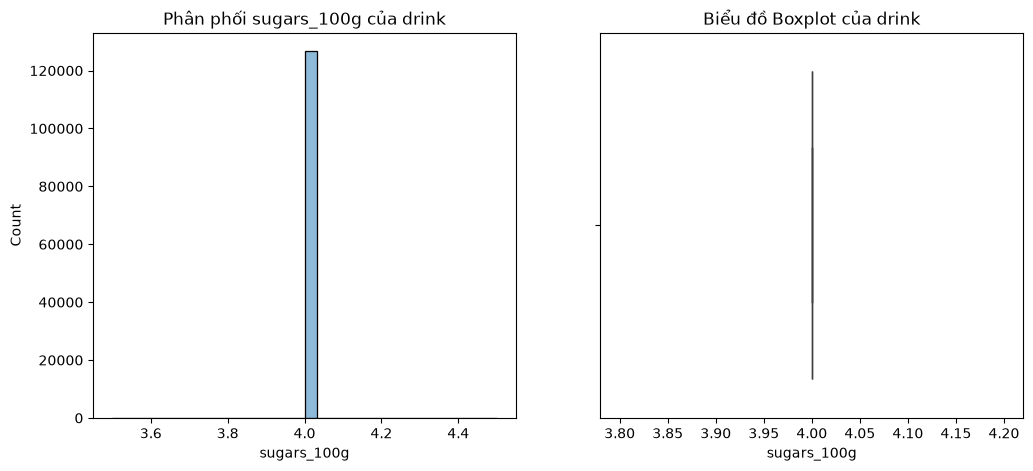

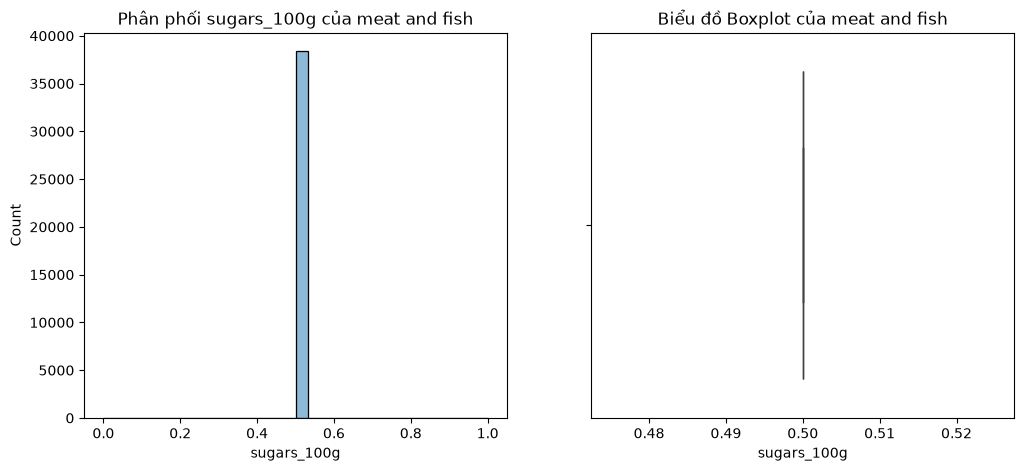

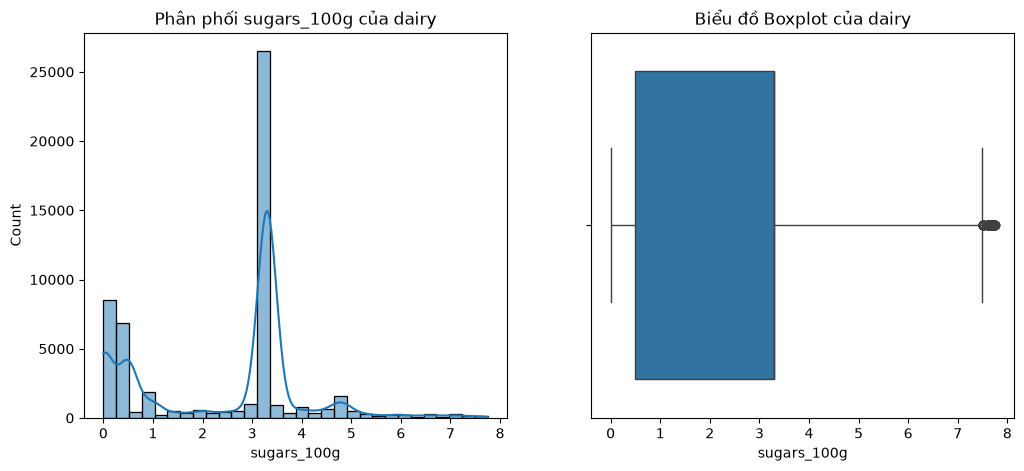

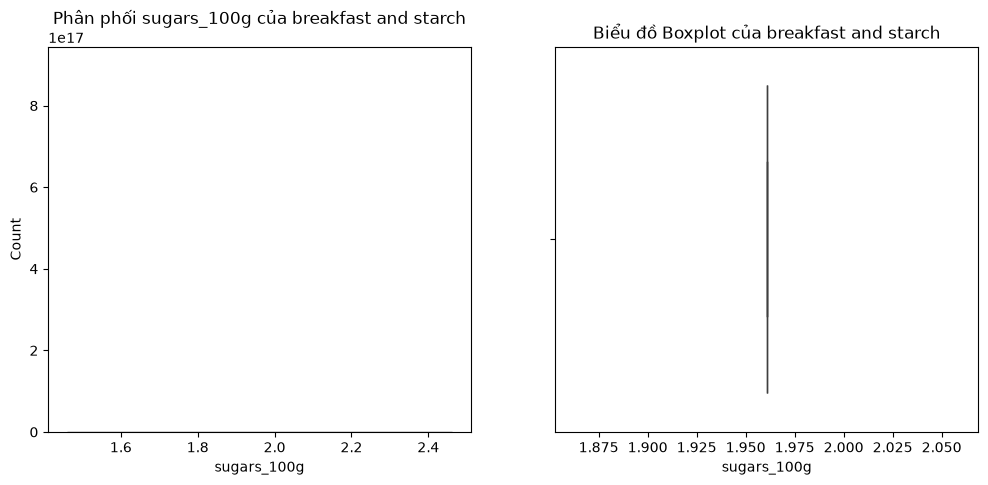

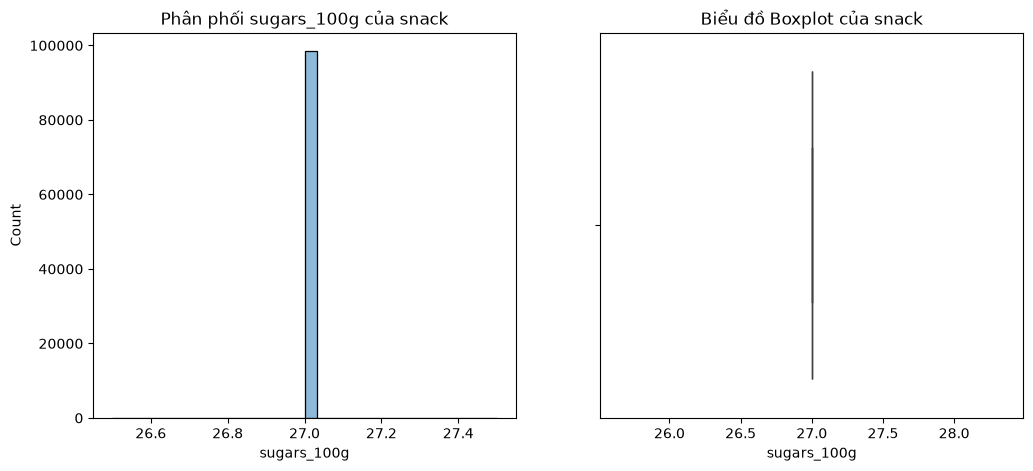

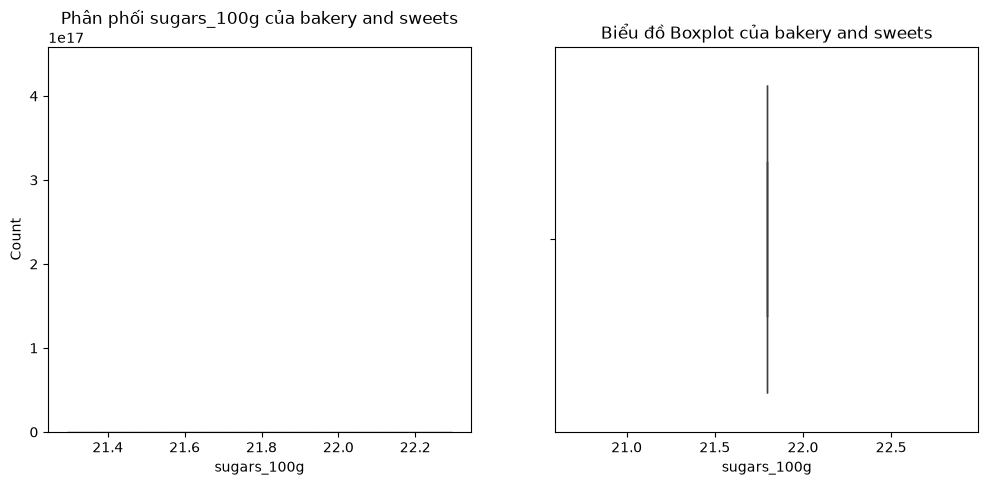

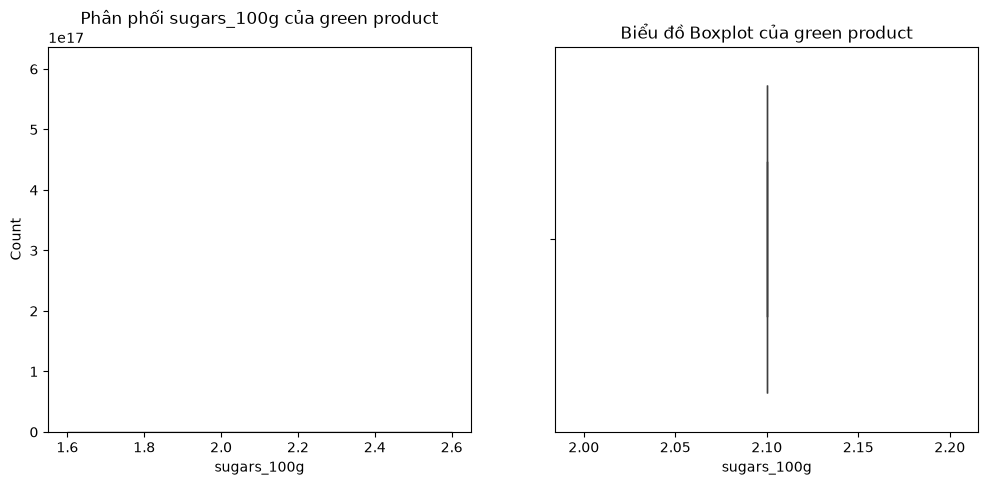

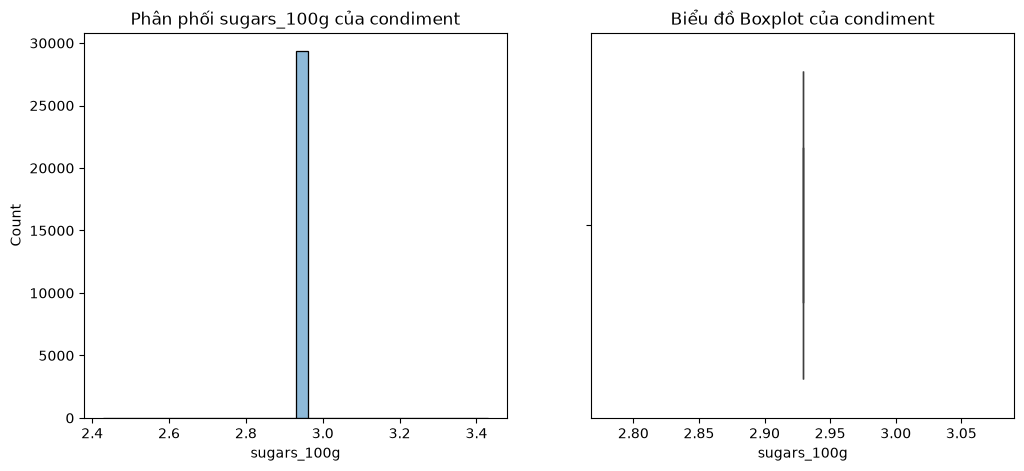

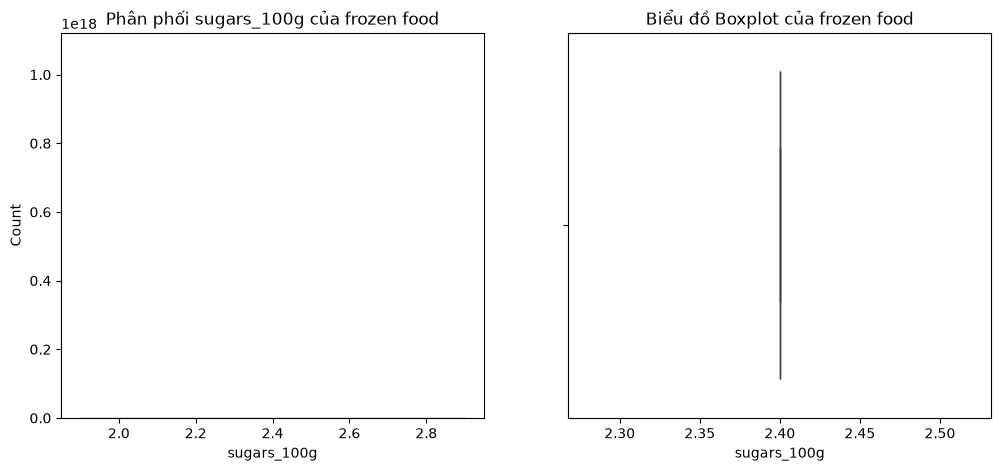

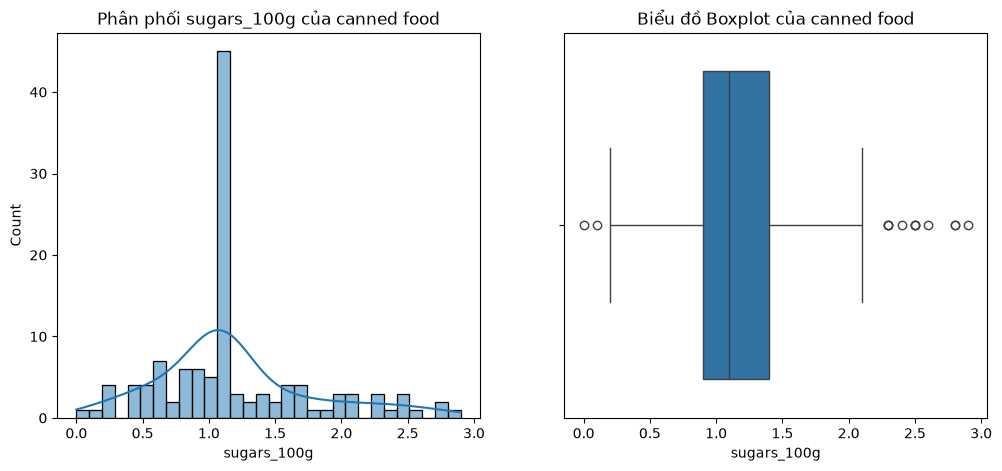

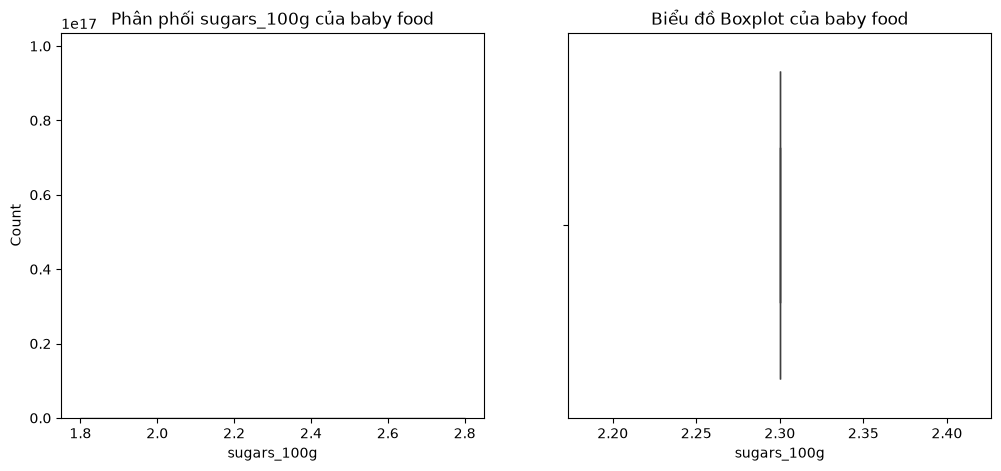

In [179]:
### Lọc outlier của sugars_100g

def remove_nova_outliers_per_category(df):
    initial_count = len(df)

    # Tính Q1, Q3 cho sugars_100g theo từng nhóm
    groups = df.groupby('general_category')['sugars_100g']

    q1 = groups.transform(lambda x: x.quantile(0.25))
    q3 = groups.transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Lọc DataFrame
    df_filtered = df[(df['sugars_100g'] >= lower_bound) & (df['sugars_100g'] <= upper_bound)]

    print(f"Số lượng bản ghi trước khi lọc: {initial_count}")
    print(f"Số lượng bản ghi sau khi lọc sugars_100g outlier: {len(df_filtered)}")
    print(f"Đã loại bỏ: {initial_count - len(df_filtered)} sản phẩm có mức sugars_100g ngoại lai theo từng nhóm.")

    return df_filtered

# Thực thi
df_categorize = remove_nova_outliers_per_category(df_categorize)

#### biến sugars_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'sugars_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['sugars_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối sugars_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['sugars_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

## fiber_100g

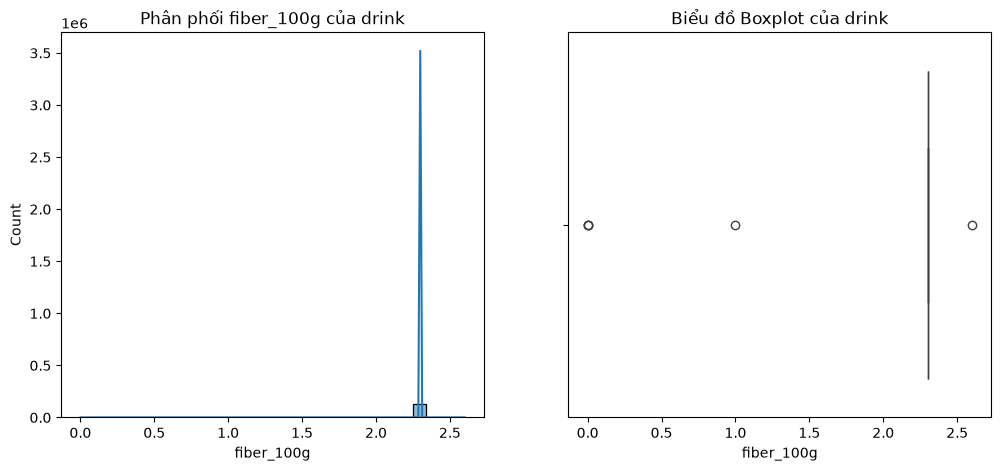

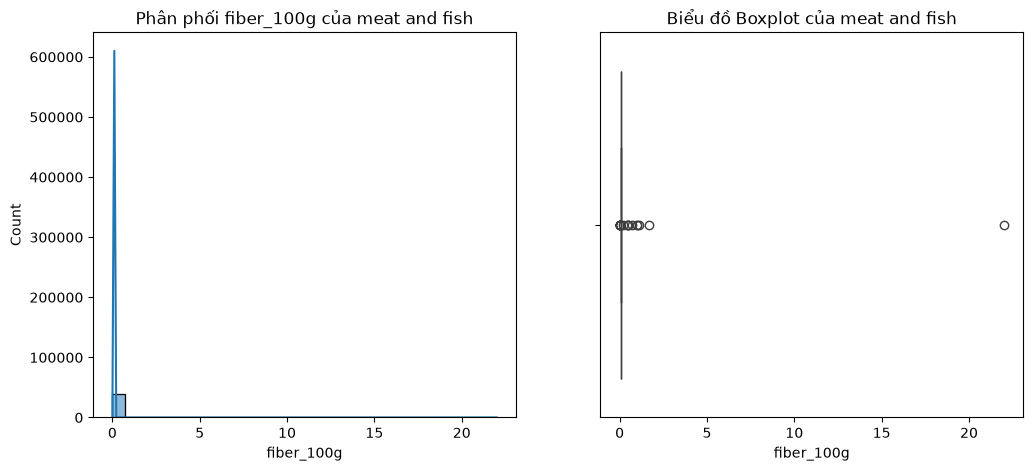

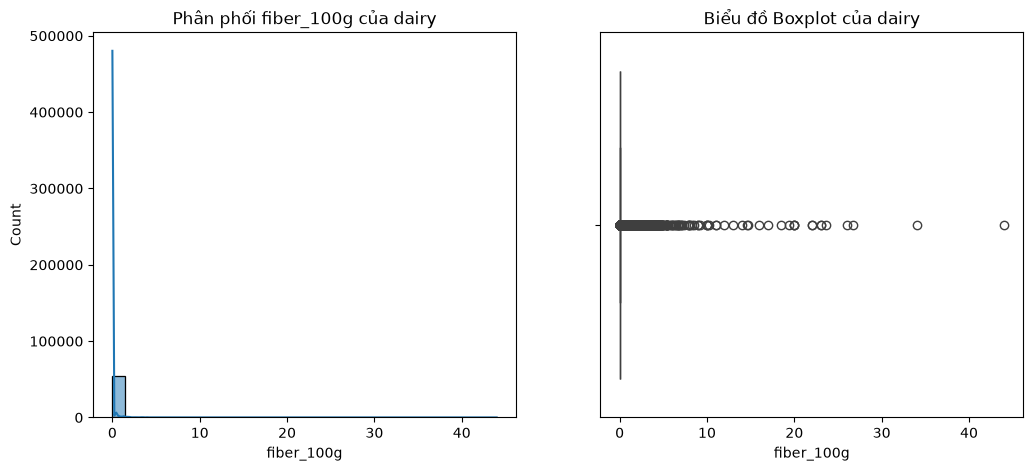

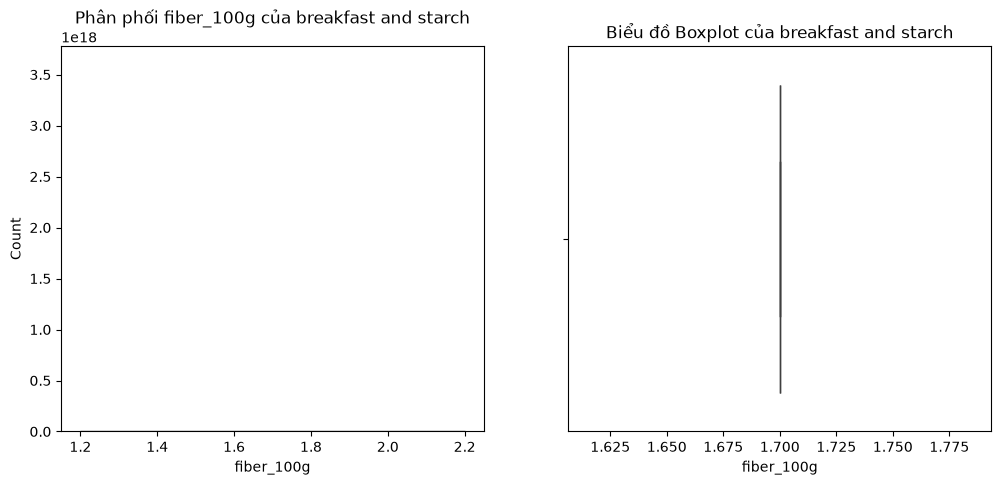

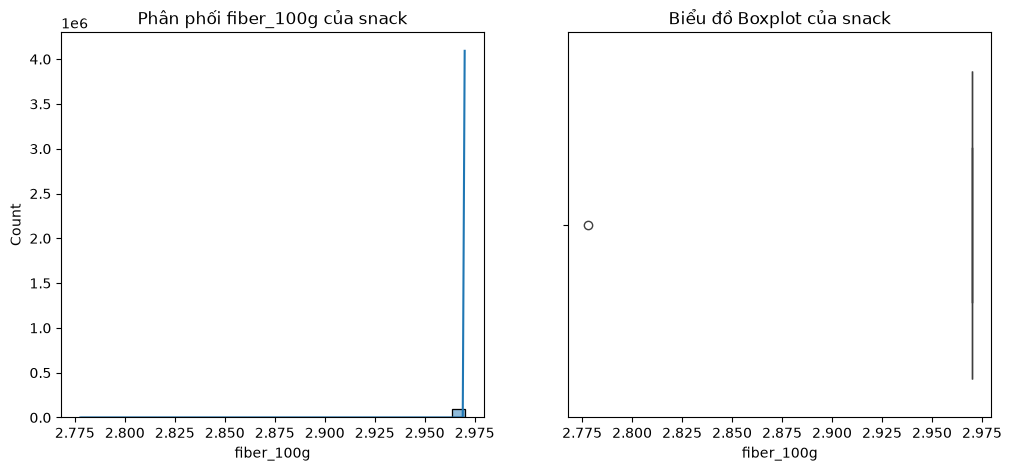

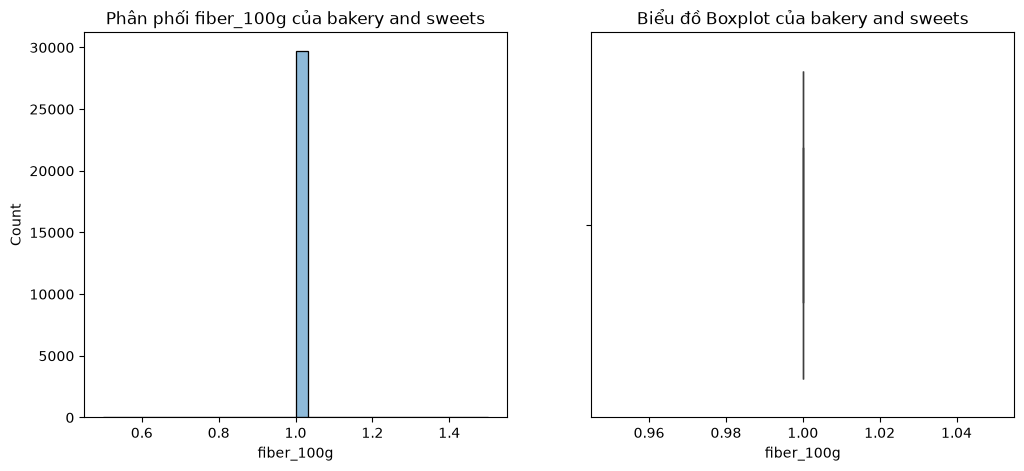

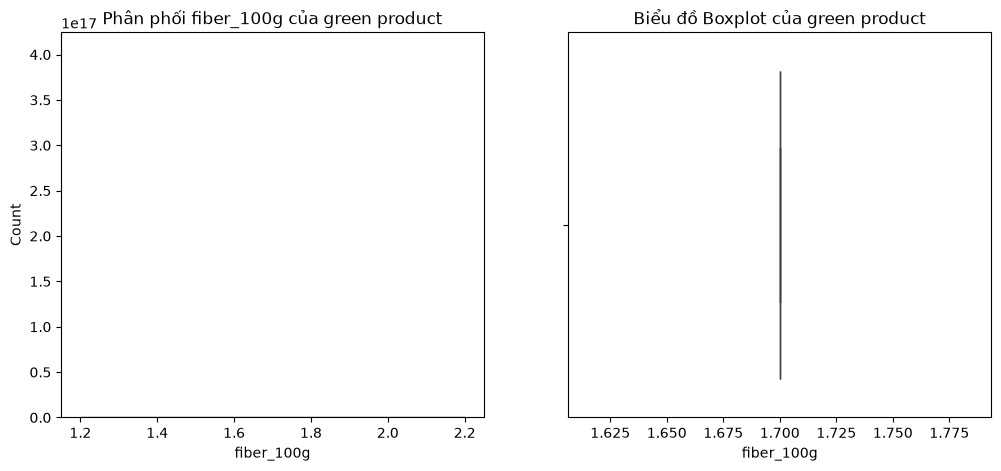

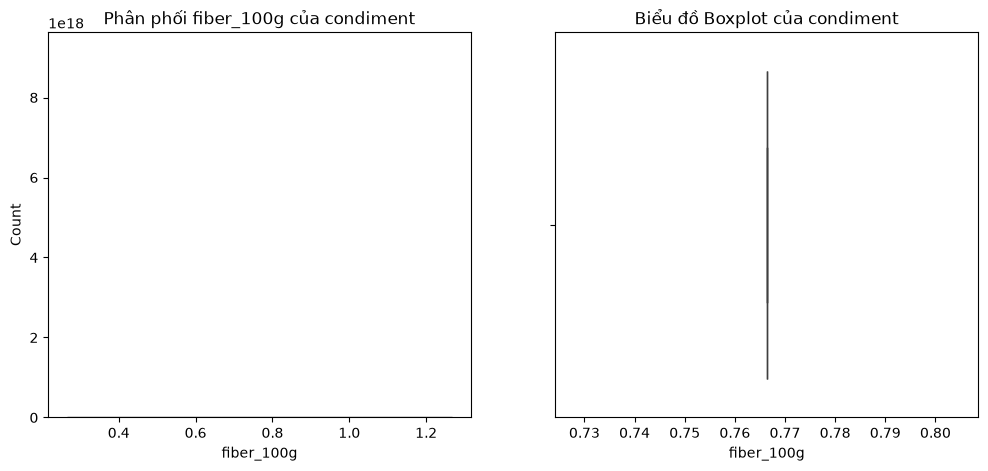

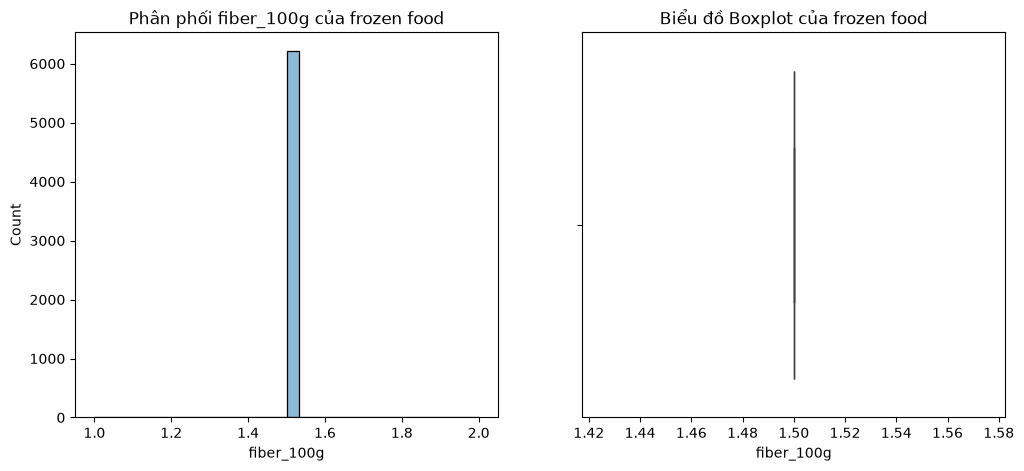

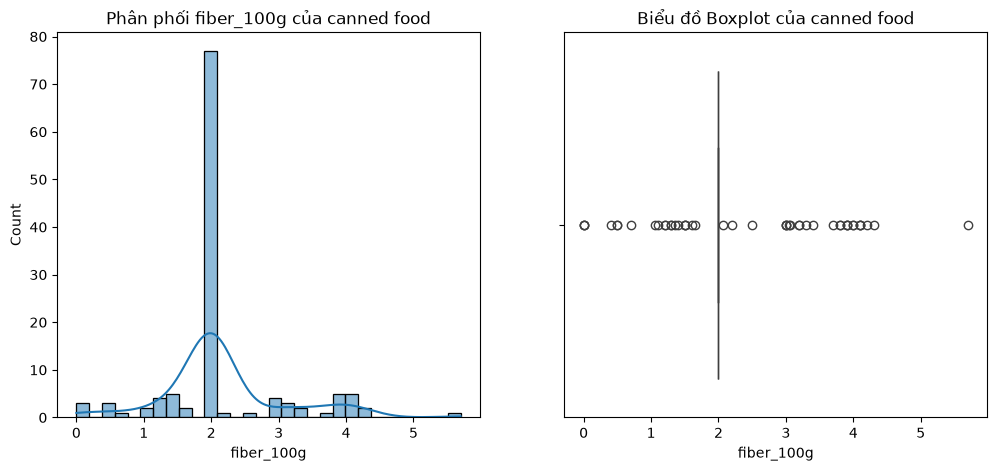

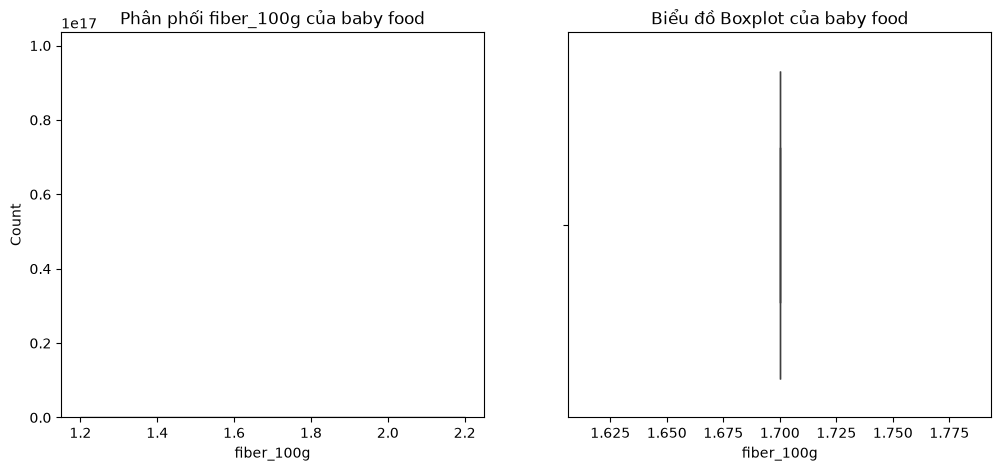

In [180]:
#### biến fiber_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'fiber_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['fiber_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối fiber_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['fiber_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

Số lượng bản ghi trước khi lọc: 398262
Số lượng bản ghi sau khi lọc fiber_100g outlier: 395136
Đã loại bỏ: 3126 sản phẩm có mức fiber_100g ngoại lai theo từng nhóm.


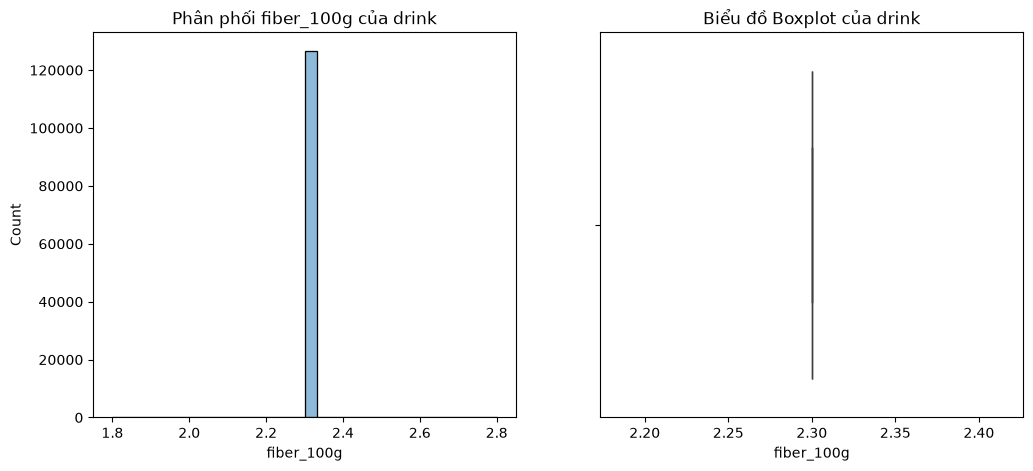

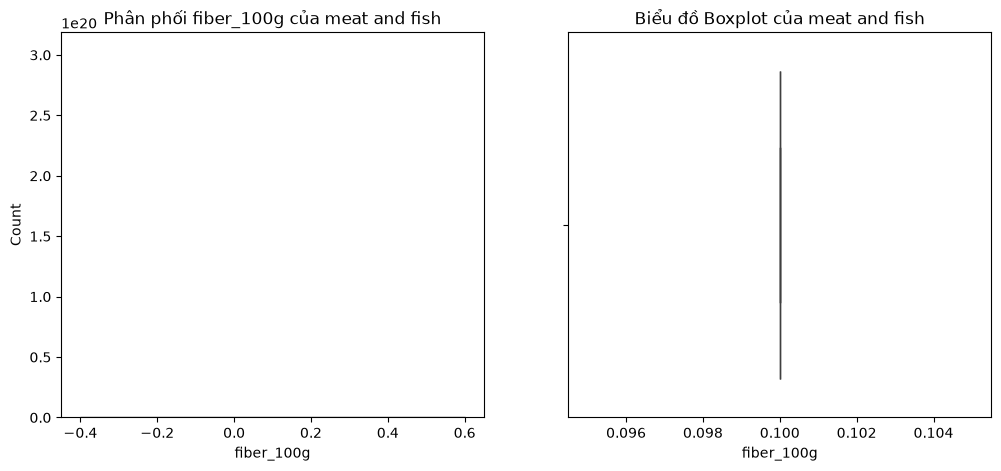

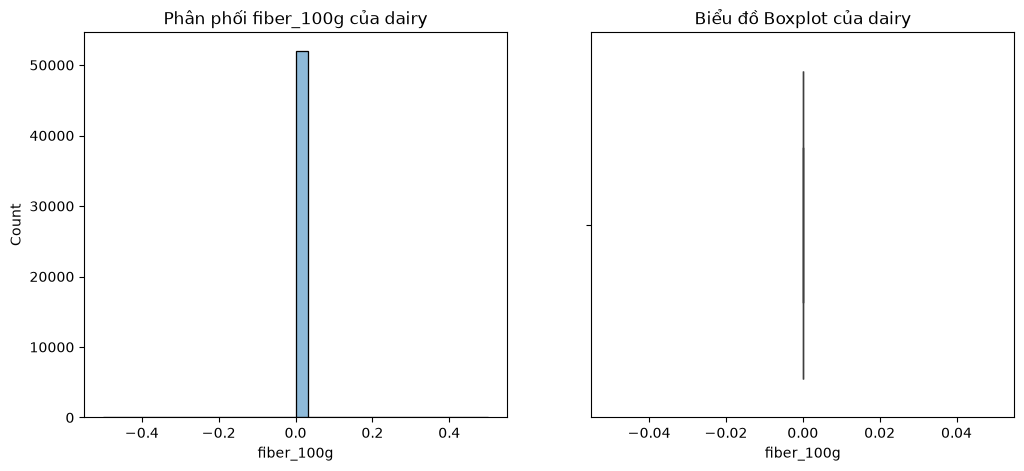

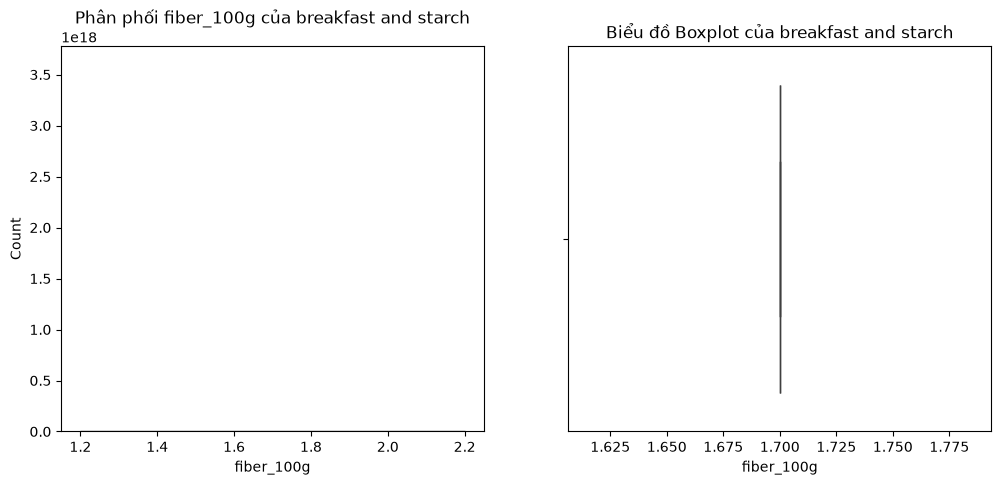

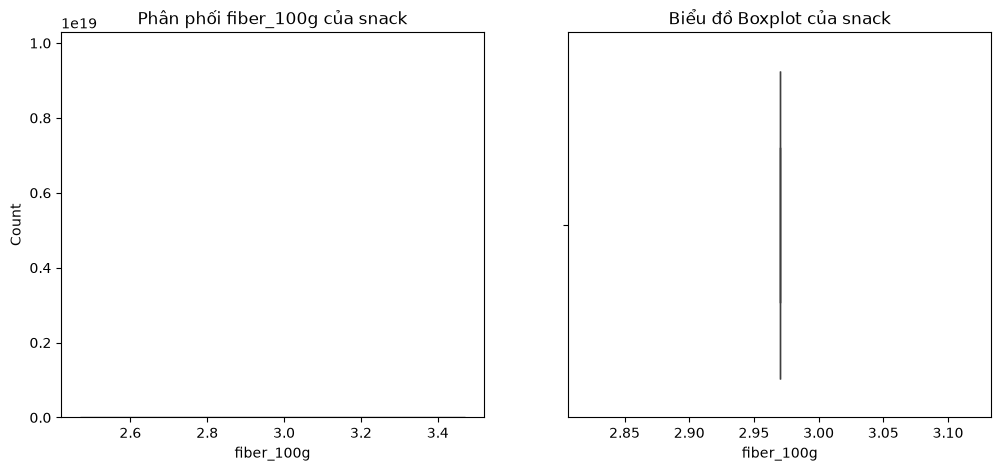

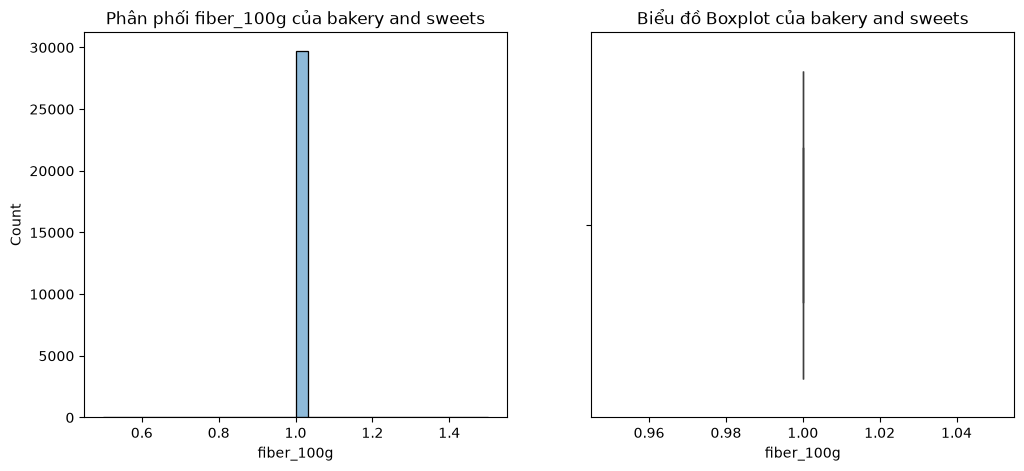

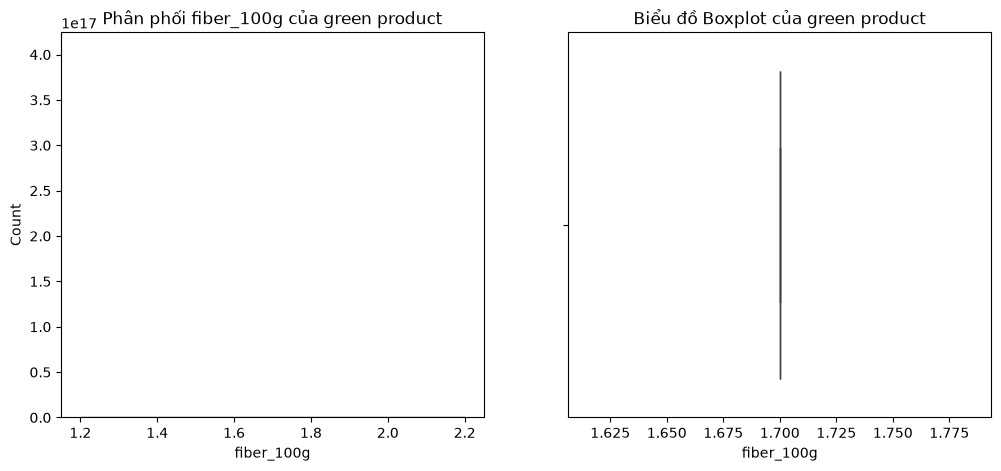

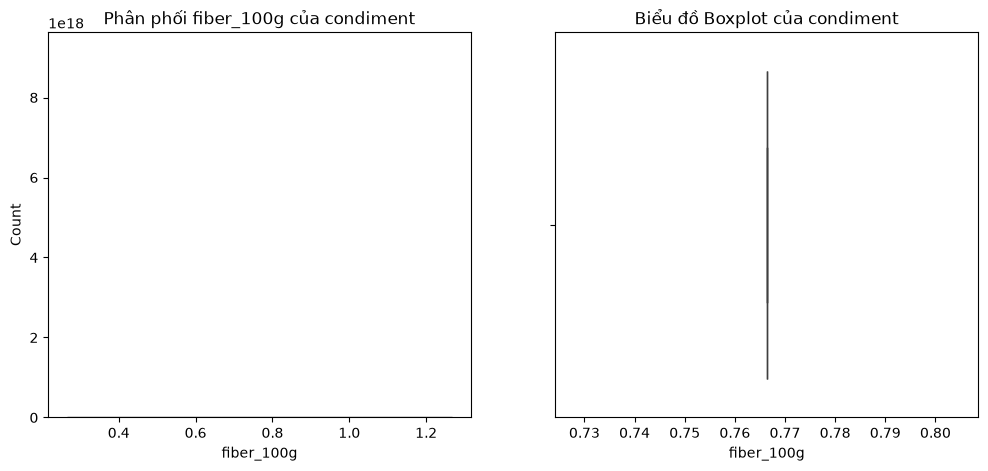

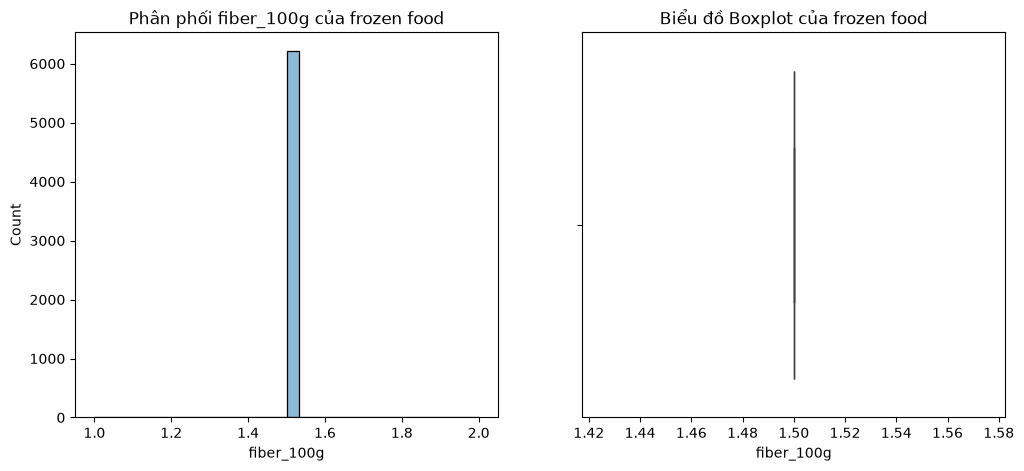

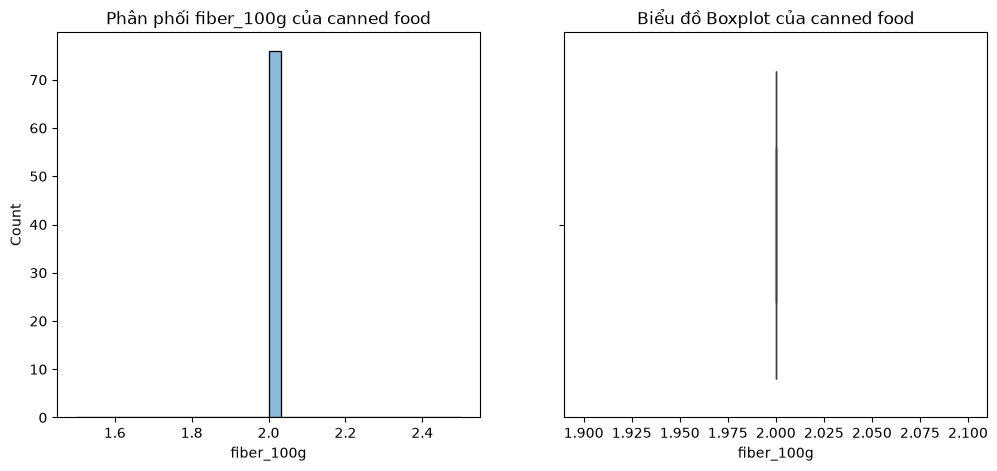

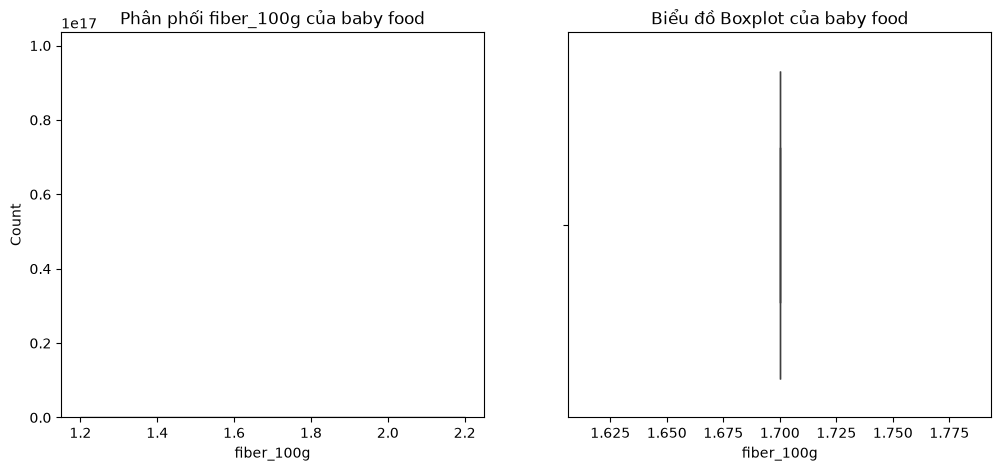

In [181]:
### Lọc outlier của fiber_100g

def remove_nova_outliers_per_category(df):
    initial_count = len(df)

    # Tính Q1, Q3 cho fiber_100g theo từng nhóm
    groups = df.groupby('general_category')['fiber_100g']

    q1 = groups.transform(lambda x: x.quantile(0.25))
    q3 = groups.transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Lọc DataFrame
    df_filtered = df[(df['fiber_100g'] >= lower_bound) & (df['fiber_100g'] <= upper_bound)]

    print(f"Số lượng bản ghi trước khi lọc: {initial_count}")
    print(f"Số lượng bản ghi sau khi lọc fiber_100g outlier: {len(df_filtered)}")
    print(f"Đã loại bỏ: {initial_count - len(df_filtered)} sản phẩm có mức fiber_100g ngoại lai theo từng nhóm.")

    return df_filtered

# Thực thi
df_categorize = remove_nova_outliers_per_category(df_categorize)

#### biến fiber_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'fiber_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['fiber_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối fiber_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['fiber_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

## proteins_100g

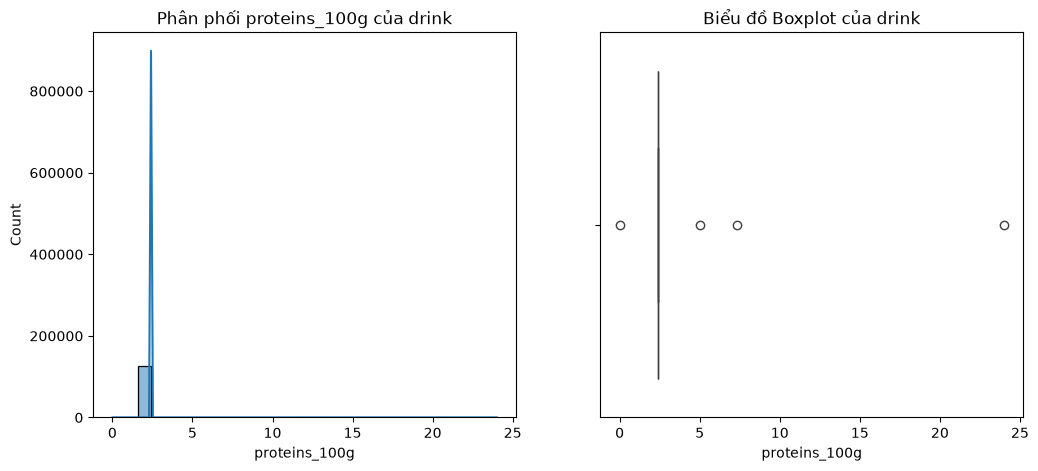

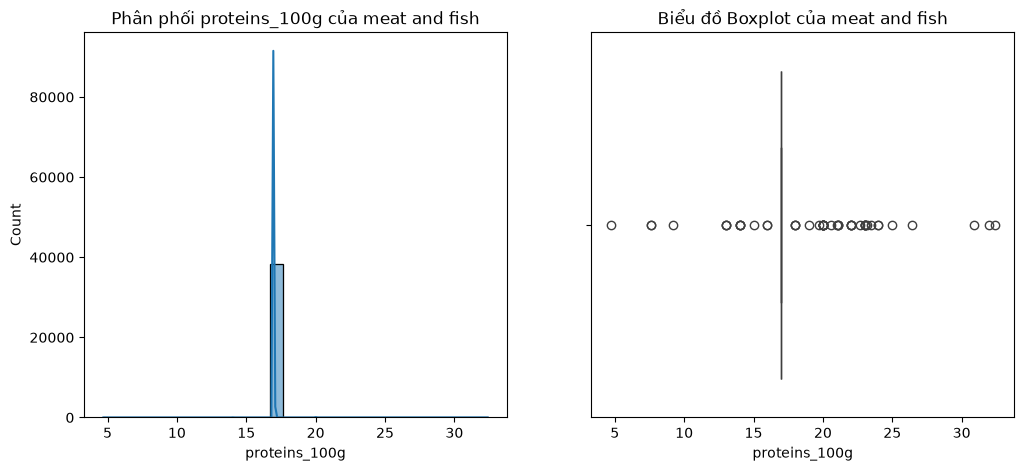

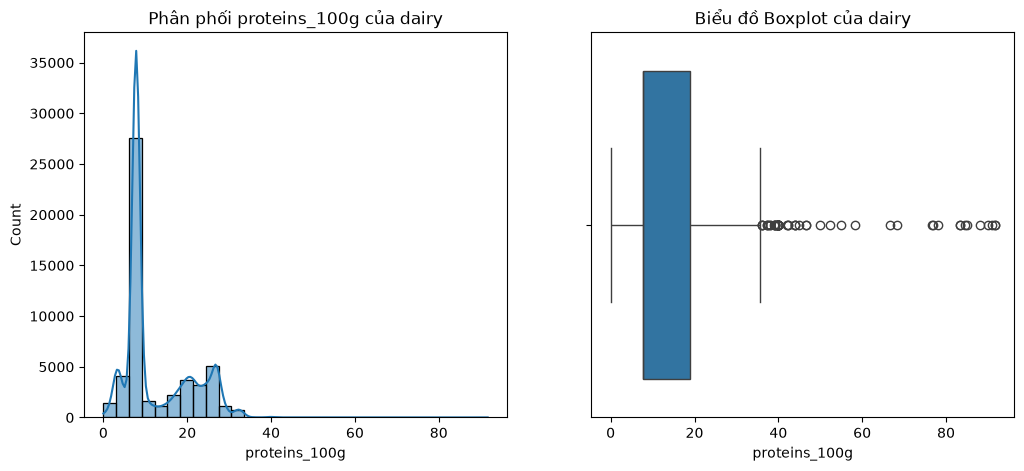

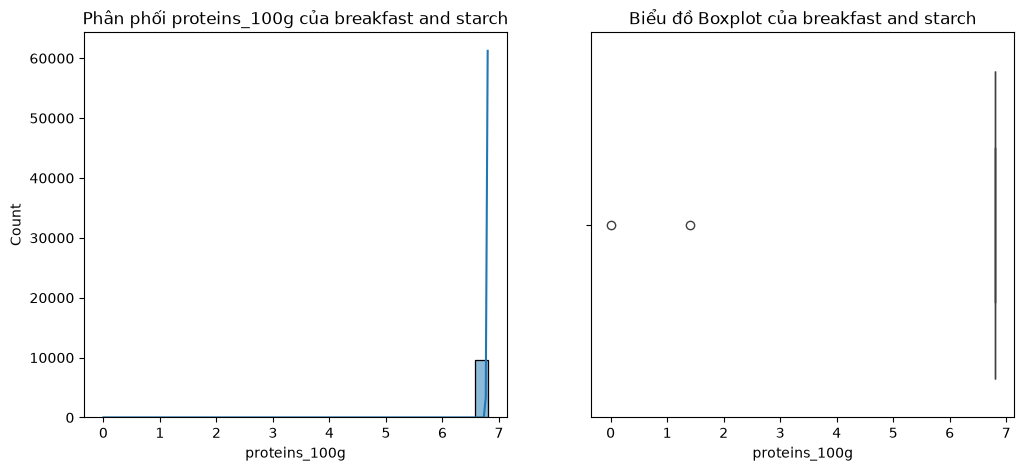

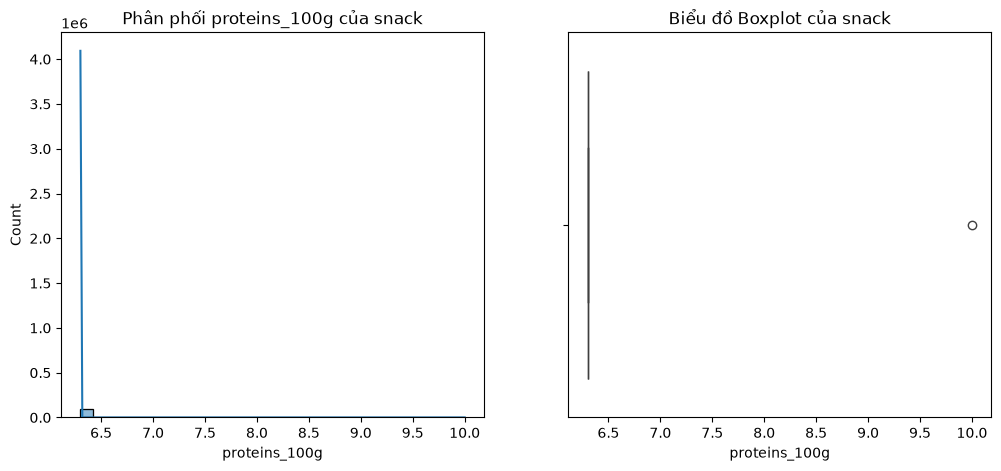

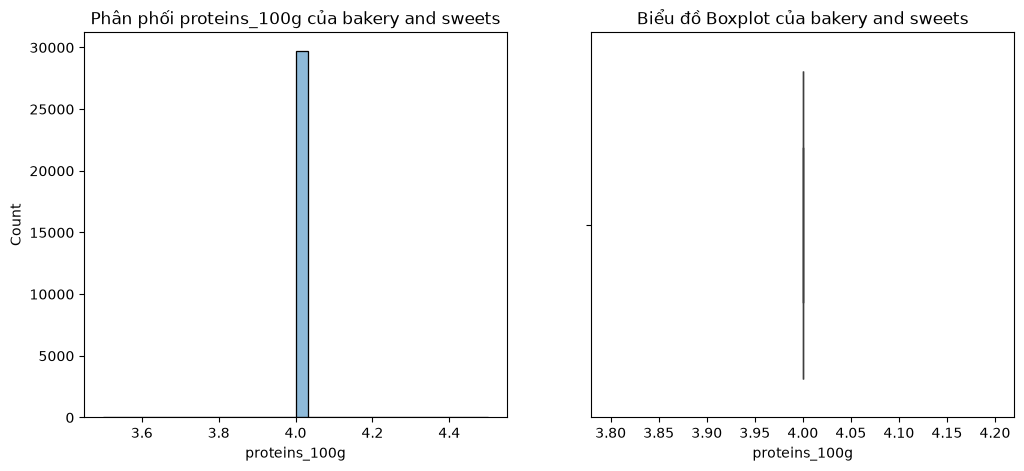

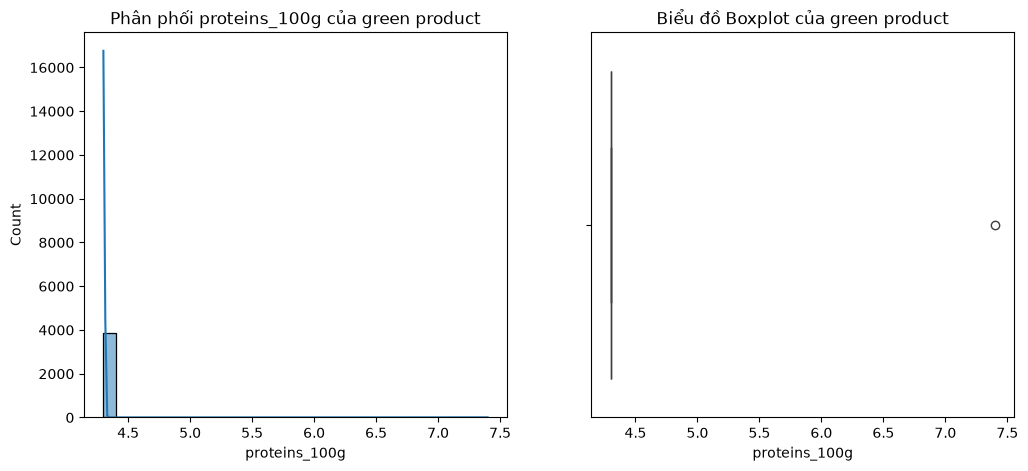

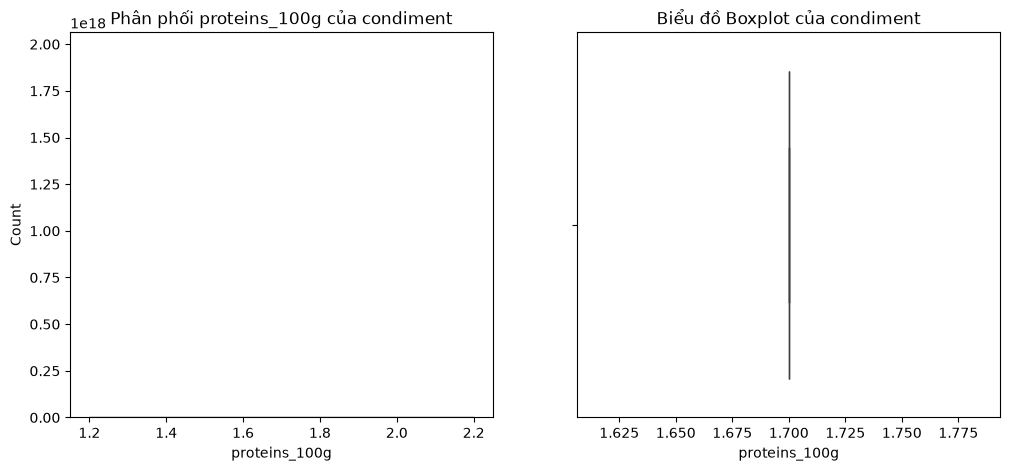

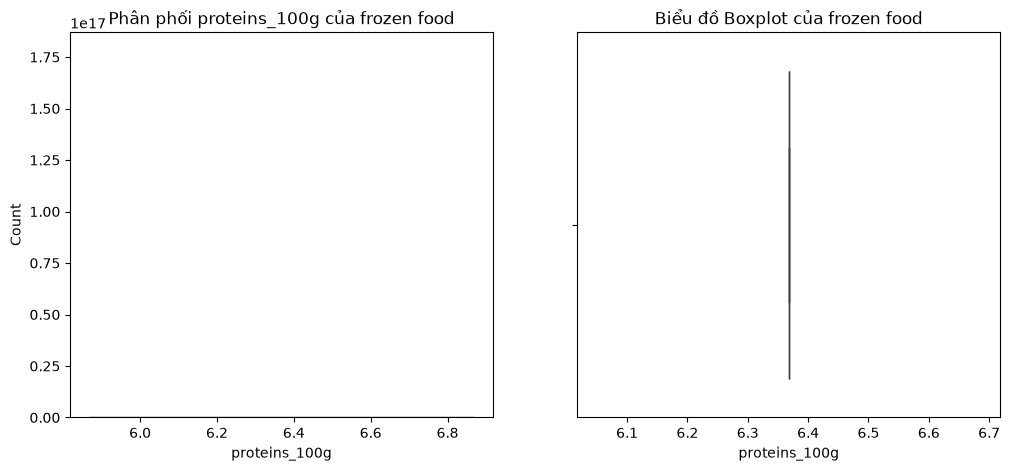

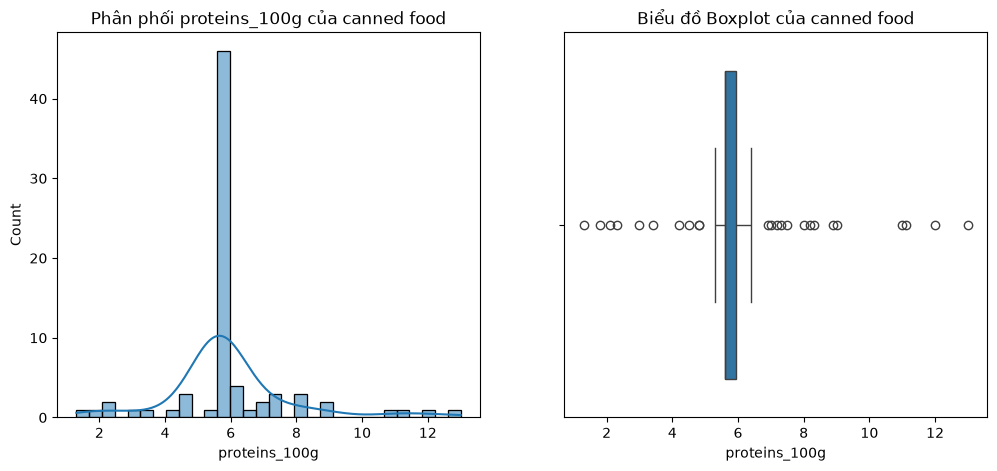

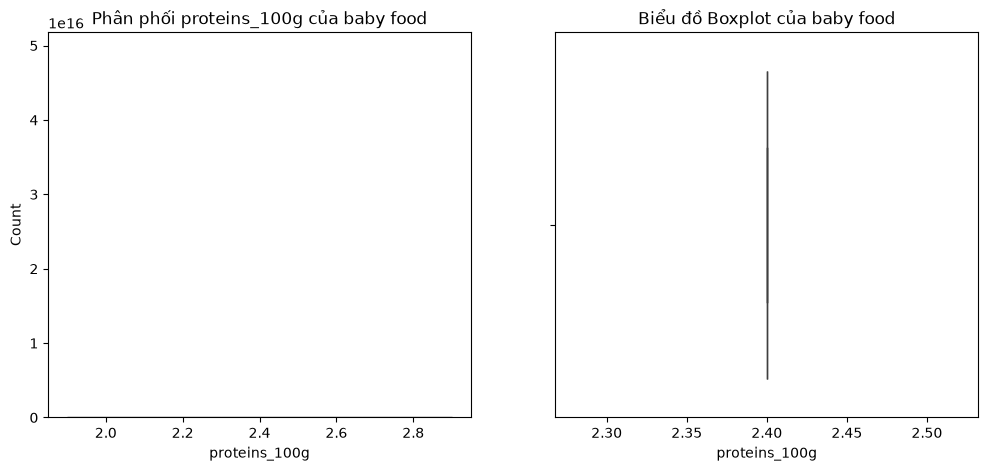

In [182]:
#### biến proteins_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'proteins_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['proteins_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối proteins_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['proteins_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

Số lượng bản ghi trước khi lọc: 395136
Số lượng bản ghi sau khi lọc proteins_100g outlier: 394975
Đã loại bỏ: 161 sản phẩm có mức proteins_100g ngoại lai theo từng nhóm.


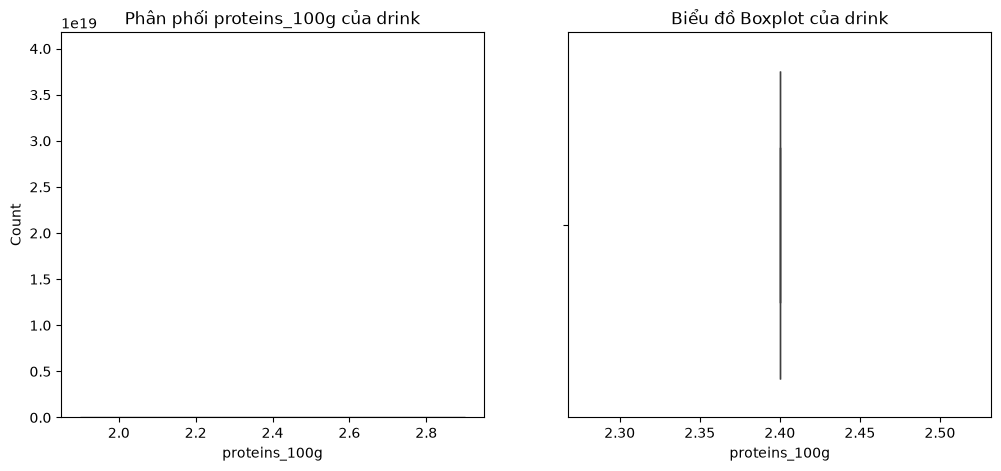

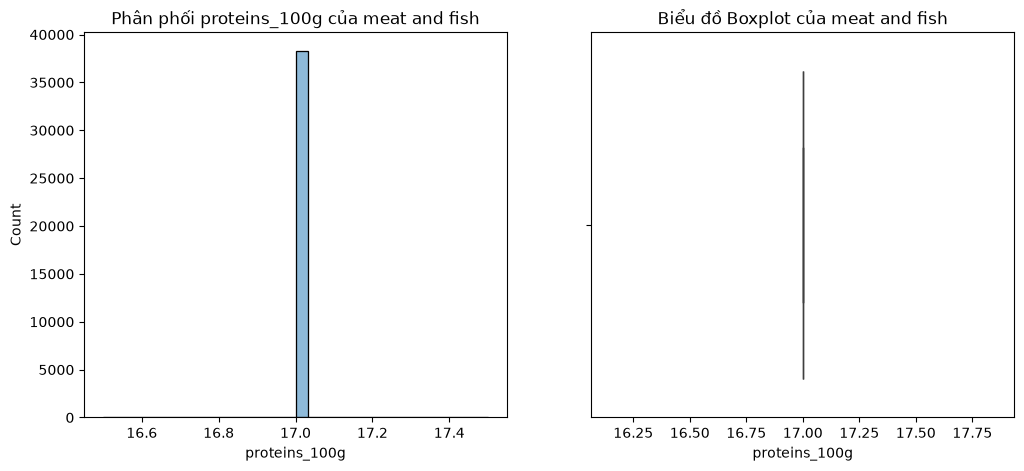

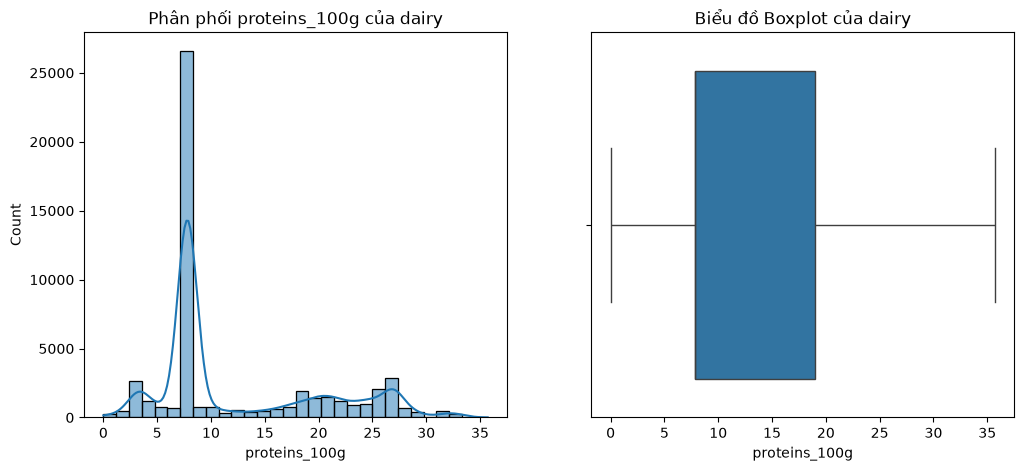

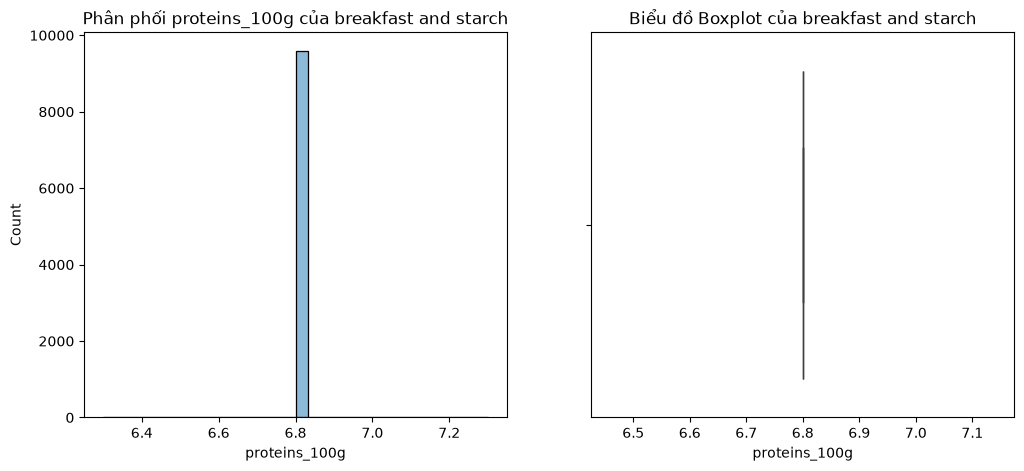

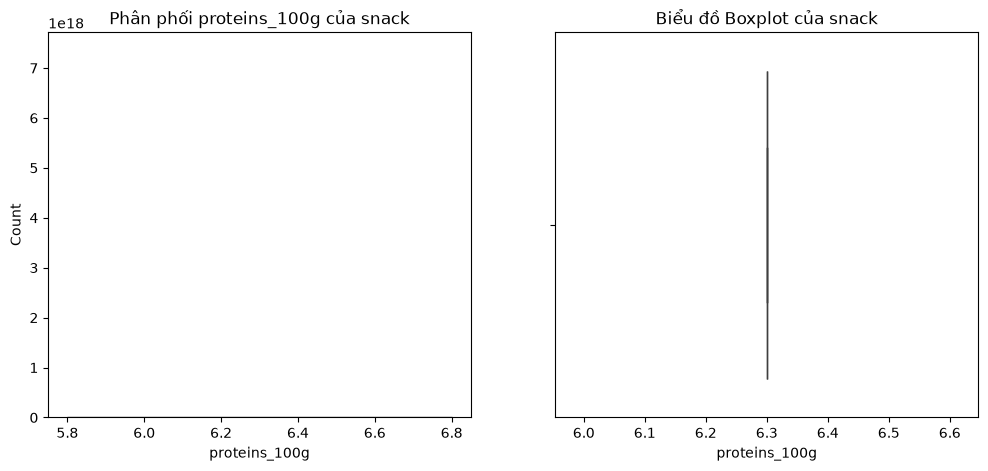

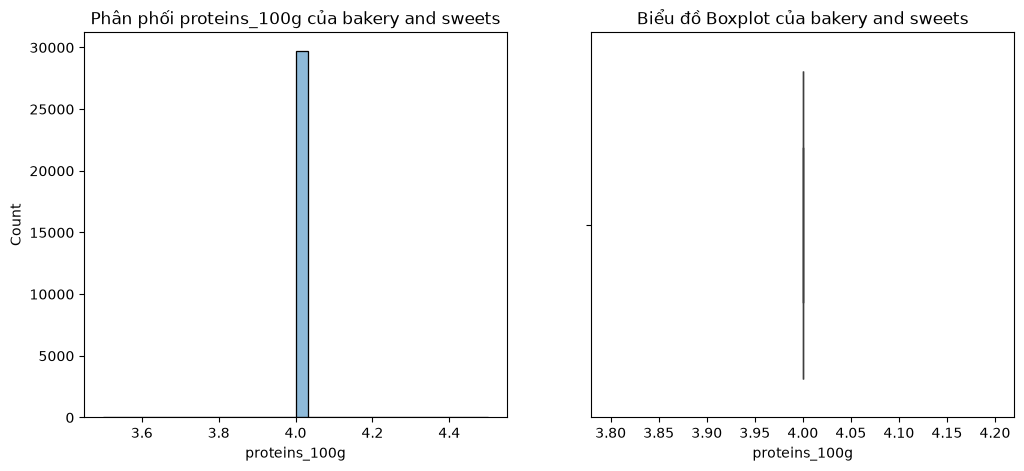

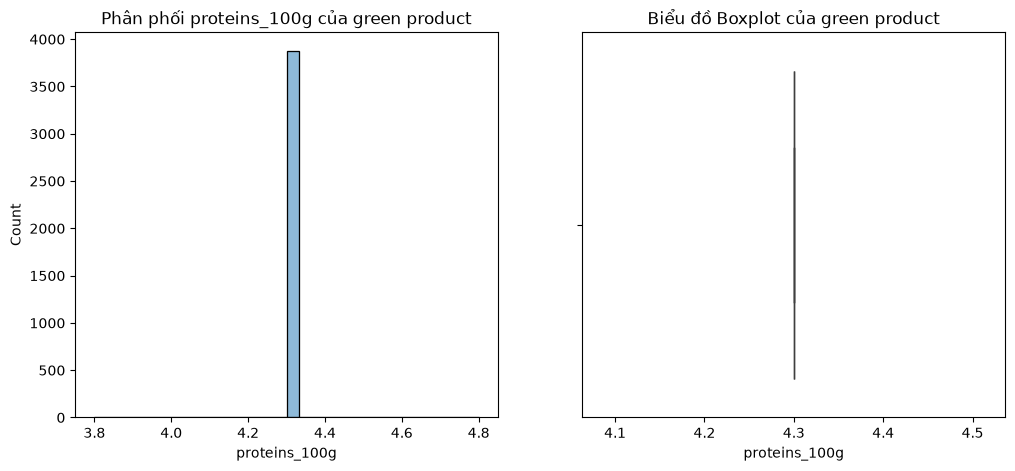

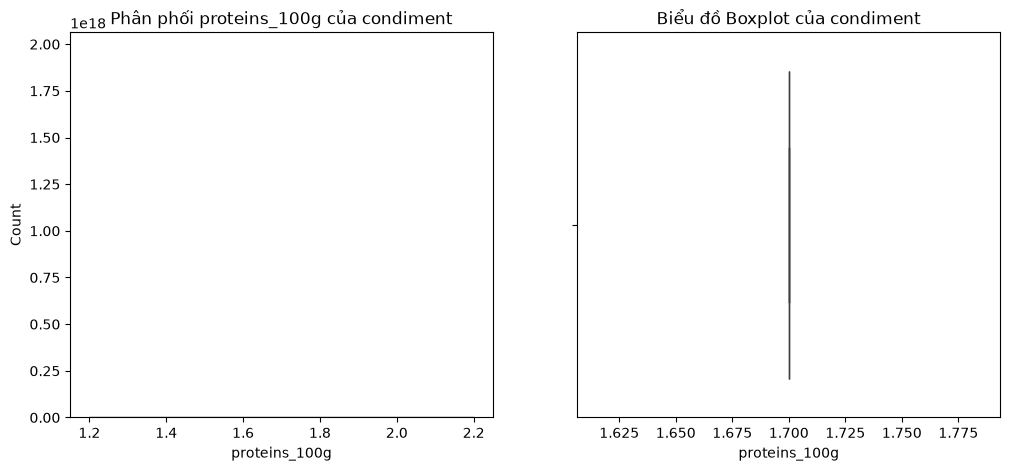

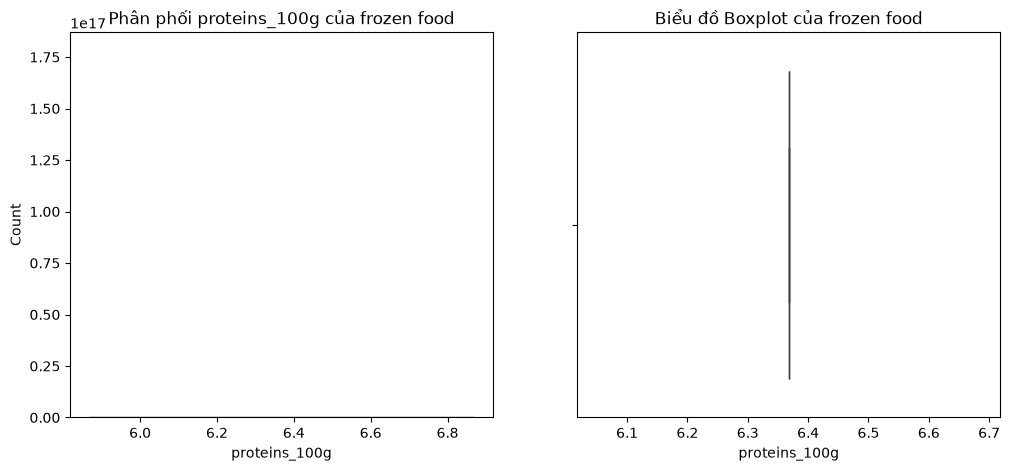

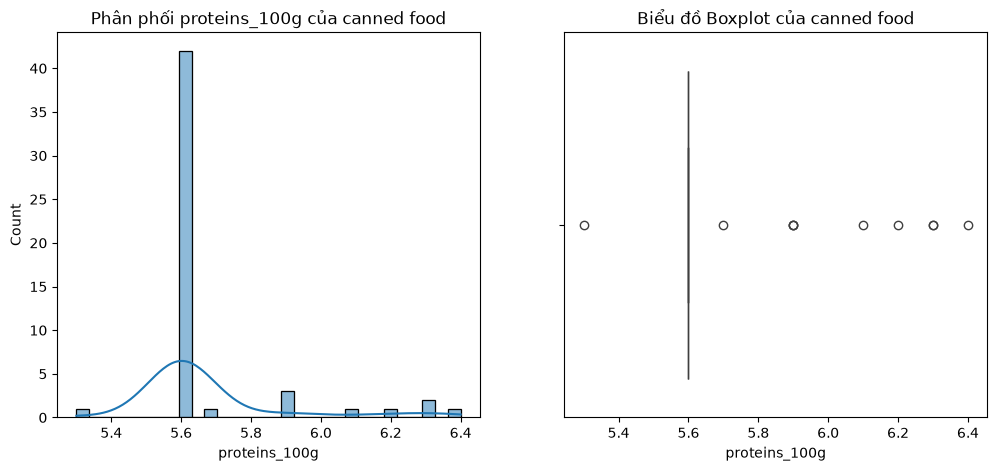

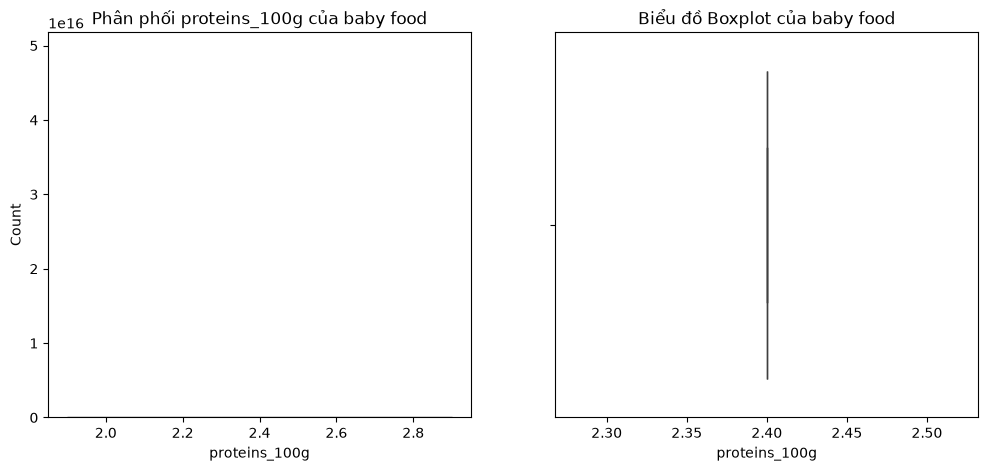

In [183]:
### Lọc outlier của proteins_100g

def remove_nova_outliers_per_category(df):
    initial_count = len(df)

    # Tính Q1, Q3 cho proteins_100g theo từng nhóm
    groups = df.groupby('general_category')['proteins_100g']

    q1 = groups.transform(lambda x: x.quantile(0.25))
    q3 = groups.transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Lọc DataFrame
    df_filtered = df[(df['proteins_100g'] >= lower_bound) & (df['proteins_100g'] <= upper_bound)]

    print(f"Số lượng bản ghi trước khi lọc: {initial_count}")
    print(f"Số lượng bản ghi sau khi lọc proteins_100g outlier: {len(df_filtered)}")
    print(f"Đã loại bỏ: {initial_count - len(df_filtered)} sản phẩm có mức proteins_100g ngoại lai theo từng nhóm.")

    return df_filtered

# Thực thi
df_categorize = remove_nova_outliers_per_category(df_categorize)

#### biến proteins_100g
# 1. Xác định cột dinh dưỡng mục tiêu
target_nutr = 'proteins_100g' # Bạn có thể đổi thành 'fat_100g', 'salt_100g', v.v.

# 2. Lấy danh sách các nhóm duy nhất
categories = df_categorize['general_category'].unique()

# 3. Lặp qua từng nhóm và vẽ biểu đồ riêng biệt
for cat_name in categories:
    # Lọc dữ liệu cho nhóm hiện tại
    df_group = df_categorize[df_categorize['general_category'] == cat_name]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_group['proteins_100g'].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối proteins_100g của {cat_name}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_group['proteins_100g'])
    plt.title(f'Biểu đồ Boxplot của {cat_name}')
    plt.show()

In [184]:
df_categorize

,code,categories_en,countries_en,additives_n,nutriscore_score,nutriscore_grade,nova_group,unique_scans_n,completeness,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,general_category
0,3760250740312,"Beverages,Alcoholic beverages,Beers,Artisan pr...",France,0.0,NaN,not-applicable,3.0,0,0.8875,885.0,1.2,0.200000,15.30375,4.0,2.30,2.40000,drink
3,3596710437139,"Plant-based foods and beverages,Plant-based fo...",France,0.0,-4.0,a,1.0,1,0.7875,885.0,1.2,0.200000,15.30375,4.0,2.30,2.40000,drink
4,20240028,"Plant-based foods and beverages,Plant-based fo...",France,0.0,NaN,unknown,4.0,1,0.9750,885.0,1.2,0.200000,15.30375,4.0,2.30,2.40000,drink
5,3596710479047,"Farming products,Eggs,Chicken eggs,Cage chicke...",France,0.0,-1.0,a,1.0,1,0.8750,767.0,10.0,2.800000,1.10000,0.5,0.10,17.00000,meat and fish
11,3248340052571,"Dairies,Milks",France,0.0,-1.0,b,4.0,1,0.4875,195.2,1.6,1.000000,4.80000,4.8,0.00,3.20000,dairy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730345,25713919708,"Beverages,Carbonated drinks,Sodas",United States,4.0,4.0,c,4.0,1,0.4750,885.0,1.2,0.200000,15.30375,4.0,2.30,2.40000,drink
730347,17077317061,"Dairies,Fermented foods,Fermented milk product...",United States,2.0,-3.0,a,4.0,0,0.4000,975.3,13.0,7.800000,4.80000,3.3,0.00,7.80000,dairy
730348,31506689307,"Meats and their products,Prepared meats",United States,0.0,34.0,e,4.0,0,0.6000,767.0,10.0,2.800000,1.10000,0.5,0.10,17.00000,meat and fish
730349,70152400027,Salted-snacks,United States,4.0,16.0,d,4.0,0,0.5000,1832.0,20.0,6.300000,54.00000,27.0,2.97,6.30000,snack


In [185]:
def compute_nutriscore_score(row):
    def score_energy(kj):
        return min(int(kj // 335), 10)

    def score_sugars(g):
        return min(int(g // 4.5), 10)

    def score_satfat(g):
        return min(int(g // 1), 10)

    def score_sodium(mg):
        return min(int(mg // 90), 10)

    def score_fiber(g):
        if g <= 0.9: return 0
        elif g <= 1.9: return 1
        elif g <= 2.8: return 2
        elif g <= 3.7: return 3
        elif g <= 4.7: return 4
        else: return 5

    def score_protein(g):
        if g <= 1.6: return 0
        elif g <= 3.2: return 1
        elif g <= 4.8: return 2
        elif g <= 6.4: return 3
        elif g <= 8.0: return 4
        else: return 5

    A = (
        score_energy(row['energy_100g']) +
        score_sugars(row['sugars_100g']) +
        score_satfat(row['saturated-fat_100g']) +
        score_sodium(row.get('sodium_100g', 0))
    )
    C = score_fiber(row['fiber_100g']) + score_protein(row['proteins_100g'])

    score = A - C
    return score

In [186]:
df_categorize['nutriscore_score_filled'] = df_categorize['nutriscore_score']

mask_missing = df_categorize['nutriscore_score'].isna()

df_categorize.loc[mask_missing, 'nutriscore_score_filled'] = df_categorize[mask_missing].apply(
    compute_nutriscore_score,
    axis=1
)

In [187]:
def score_to_grade(score):
    if score <= -1: return "a"
    elif score <= 2: return "b"
    elif score <= 10: return "c"
    elif score <= 18: return "d"
    else: return "e"

In [188]:
df_categorize['nutriscore_grade_calc'] = df_categorize['nutriscore_score_filled'].apply(score_to_grade)

In [189]:
mask_valid = df_categorize['nutriscore_grade_calc'] == df_categorize['nutriscore_grade']

In [190]:
df_categorize = df_categorize[mask_valid].copy()

In [191]:
df_categorize

,code,categories_en,countries_en,additives_n,nutriscore_score,nutriscore_grade,nova_group,unique_scans_n,completeness,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,general_category,nutriscore_score_filled,nutriscore_grade_calc
3,3596710437139,"Plant-based foods and beverages,Plant-based fo...",France,0.0,-4.0,a,1.0,1,0.7875,885.0,1.2,0.200000,15.30375,4.0,2.30,2.40000,drink,-4.0,a
5,3596710479047,"Farming products,Eggs,Chicken eggs,Cage chicke...",France,0.0,-1.0,a,1.0,1,0.8750,767.0,10.0,2.800000,1.10000,0.5,0.10,17.00000,meat and fish,-1.0,a
22,3272770014359,"Dairies,Fermented foods,Fermented milk product...",France,0.0,17.0,d,4.0,1,0.6750,1416.0,34.0,24.000000,2.30000,2.3,0.00,7.00000,dairy,17.0,d
51,3560070432578,"Dairies,Fermented foods,Fermented milk product...",France,0.0,15.0,d,3.0,0,0.8625,1336.0,26.0,18.000000,1.00000,0.5,0.00,21.00000,dairy,15.0,d
52,3278692600021,"Dairies,Fermented foods,Fermented milk product...",France,0.0,16.0,d,4.0,1,0.7875,1196.7,30.0,22.000000,2.80000,2.8,0.00,2.30000,dairy,16.0,d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730345,25713919708,"Beverages,Carbonated drinks,Sodas",United States,4.0,4.0,c,4.0,1,0.4750,885.0,1.2,0.200000,15.30375,4.0,2.30,2.40000,drink,4.0,c
730347,17077317061,"Dairies,Fermented foods,Fermented milk product...",United States,2.0,-3.0,a,4.0,0,0.4000,975.3,13.0,7.800000,4.80000,3.3,0.00,7.80000,dairy,-3.0,a
730348,31506689307,"Meats and their products,Prepared meats",United States,0.0,34.0,e,4.0,0,0.6000,767.0,10.0,2.800000,1.10000,0.5,0.10,17.00000,meat and fish,34.0,e
730349,70152400027,Salted-snacks,United States,4.0,16.0,d,4.0,0,0.5000,1832.0,20.0,6.300000,54.00000,27.0,2.97,6.30000,snack,16.0,d


In [192]:
df_categorize.drop(columns=['nutriscore_grade_calc'], inplace=True)

In [193]:
df_categorize.drop(columns=['nutriscore_score_filled'], inplace=True)

In [194]:
df_categorize.reset_index(drop=True, inplace=True)

In [195]:
df_categorize

,code,categories_en,countries_en,additives_n,nutriscore_score,nutriscore_grade,nova_group,unique_scans_n,completeness,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,general_category
0,3596710437139,"Plant-based foods and beverages,Plant-based fo...",France,0.0,-4.0,a,1.0,1,0.7875,885.0,1.2,0.200000,15.30375,4.0,2.30,2.40000,drink
1,3596710479047,"Farming products,Eggs,Chicken eggs,Cage chicke...",France,0.0,-1.0,a,1.0,1,0.8750,767.0,10.0,2.800000,1.10000,0.5,0.10,17.00000,meat and fish
2,3272770014359,"Dairies,Fermented foods,Fermented milk product...",France,0.0,17.0,d,4.0,1,0.6750,1416.0,34.0,24.000000,2.30000,2.3,0.00,7.00000,dairy
3,3560070432578,"Dairies,Fermented foods,Fermented milk product...",France,0.0,15.0,d,3.0,0,0.8625,1336.0,26.0,18.000000,1.00000,0.5,0.00,21.00000,dairy
4,3278692600021,"Dairies,Fermented foods,Fermented milk product...",France,0.0,16.0,d,4.0,1,0.7875,1196.7,30.0,22.000000,2.80000,2.8,0.00,2.30000,dairy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265038,25713919708,"Beverages,Carbonated drinks,Sodas",United States,4.0,4.0,c,4.0,1,0.4750,885.0,1.2,0.200000,15.30375,4.0,2.30,2.40000,drink
265039,17077317061,"Dairies,Fermented foods,Fermented milk product...",United States,2.0,-3.0,a,4.0,0,0.4000,975.3,13.0,7.800000,4.80000,3.3,0.00,7.80000,dairy
265040,31506689307,"Meats and their products,Prepared meats",United States,0.0,34.0,e,4.0,0,0.6000,767.0,10.0,2.800000,1.10000,0.5,0.10,17.00000,meat and fish
265041,70152400027,Salted-snacks,United States,4.0,16.0,d,4.0,0,0.5000,1832.0,20.0,6.300000,54.00000,27.0,2.97,6.30000,snack


In [196]:
df_categorize['energy_100g'] = df_categorize['energy_100g'].round(2)
df_categorize['fat_100g'] = df_categorize['fat_100g'].round(2)
df_categorize['saturated-fat_100g'] = df_categorize['saturated-fat_100g'].round(2)
df_categorize['carbohydrates_100g'] = df_categorize['carbohydrates_100g'].round(2)
df_categorize['sugars_100g'] = df_categorize['sugars_100g'].round(2)
df_categorize['proteins_100g'] = df_categorize['proteins_100g'].round(2)
df_categorize['fiber_100g'] = df_categorize['fiber_100g'].round(2)


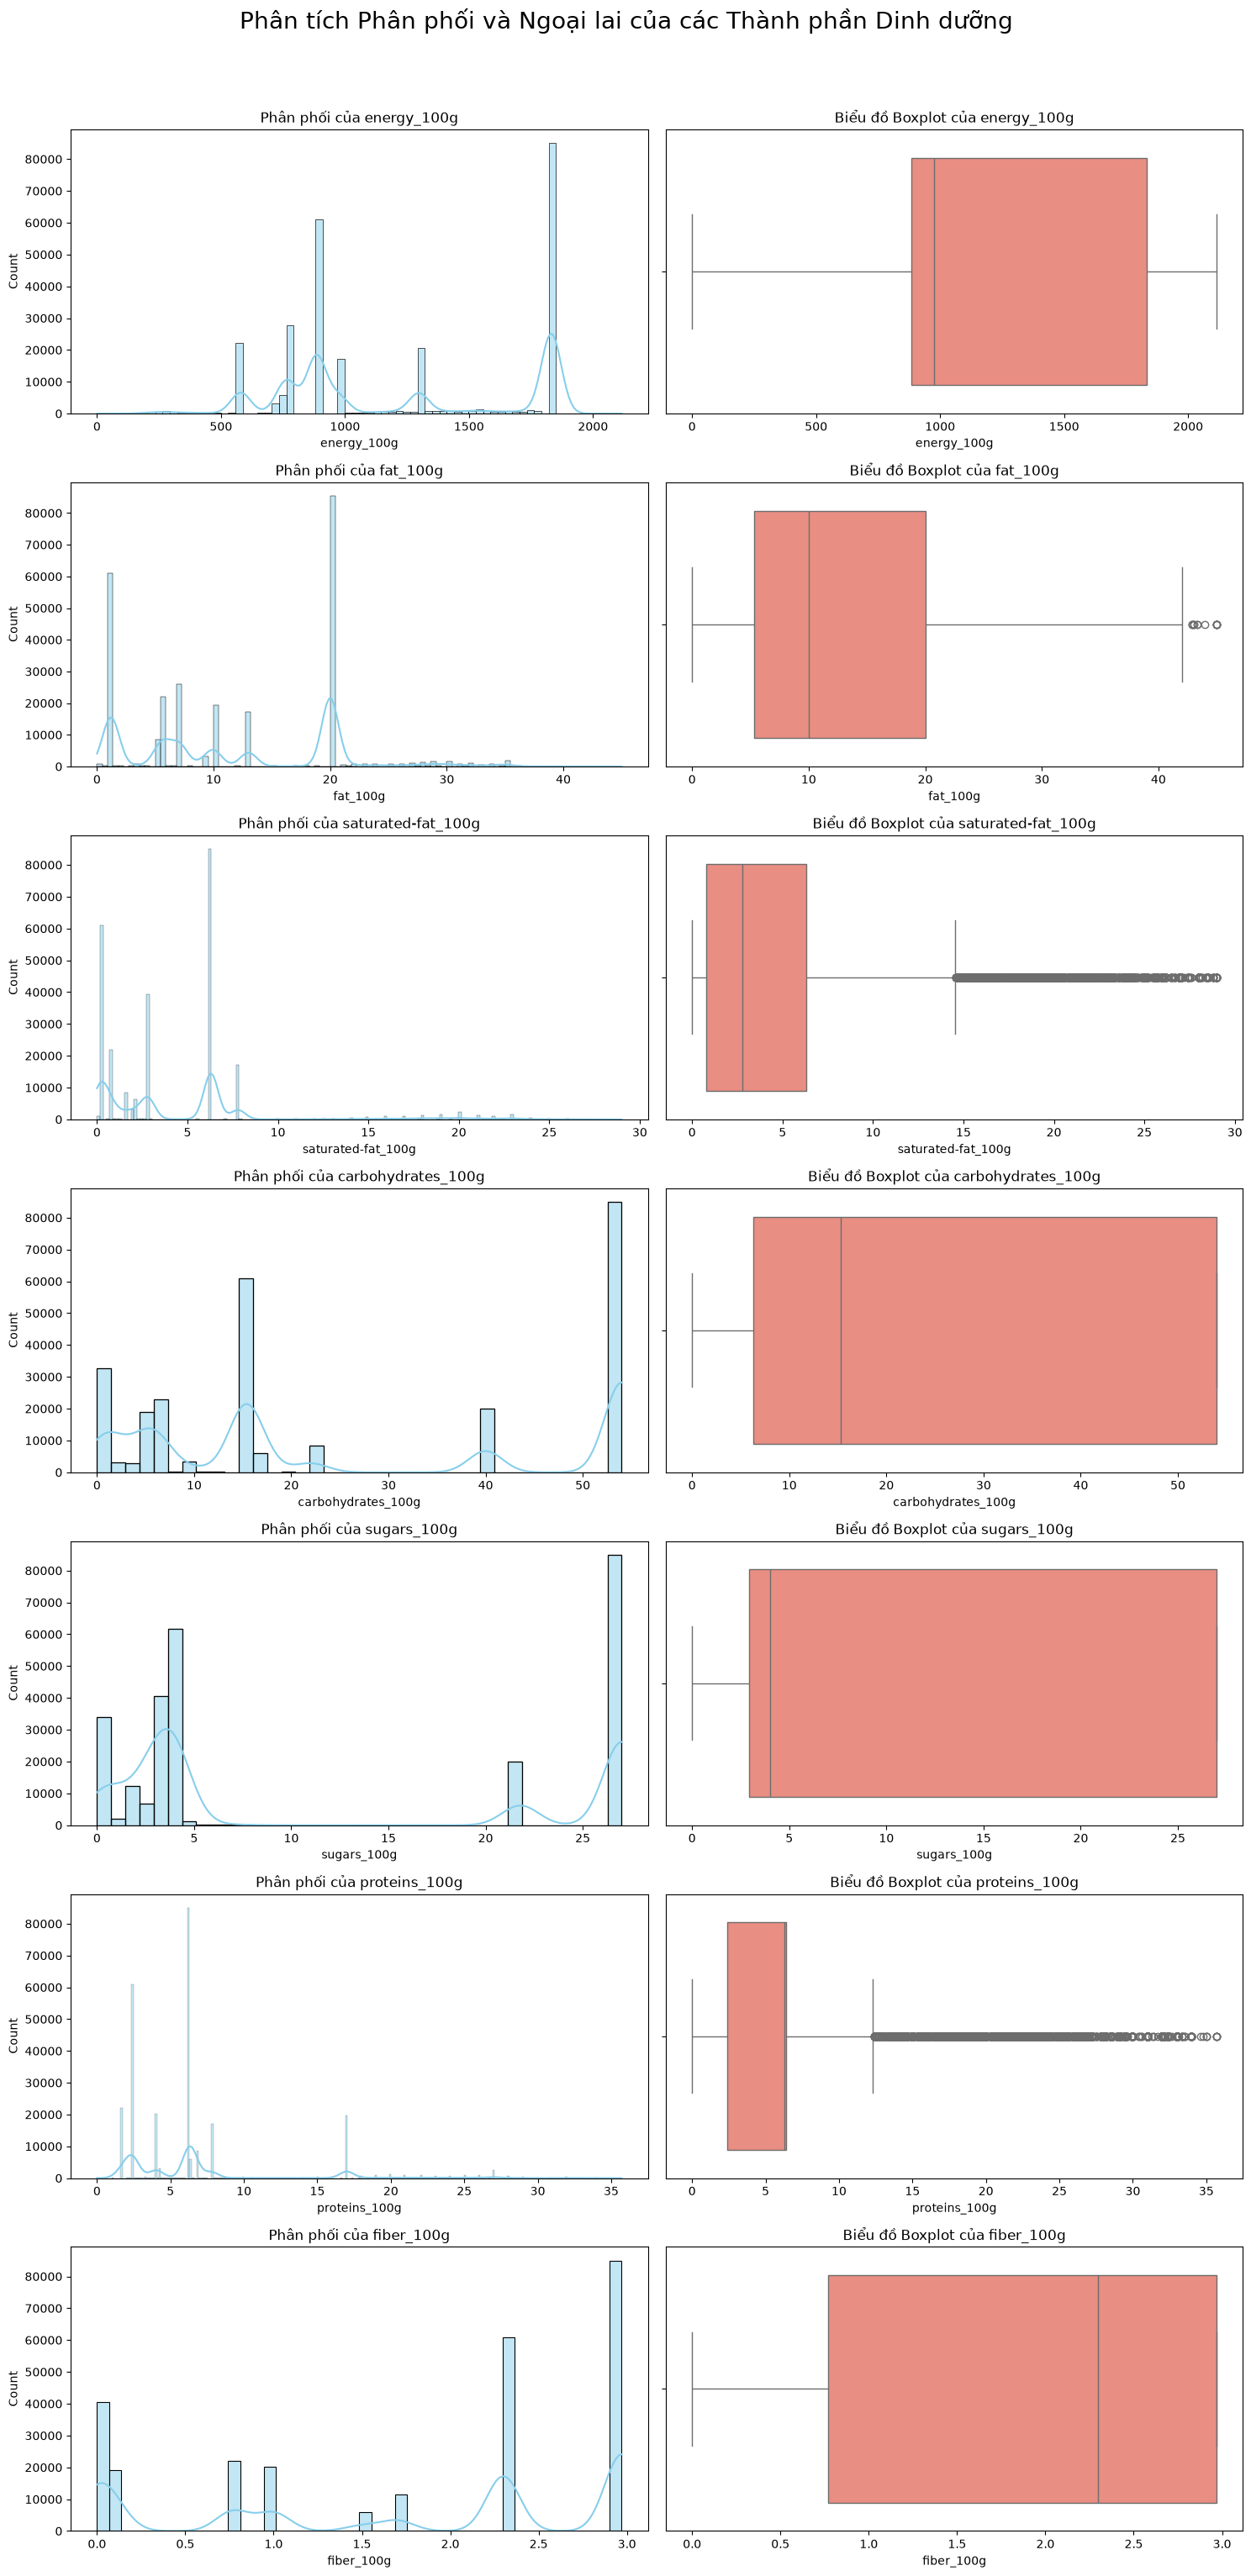

In [200]:
import matplotlib.pyplot as plt

# Danh sách các cột cần vẽ
nutr_cols = ['energy_100g', 'fat_100g', 'saturated-fat_100g',
             'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'fiber_100g']

# Thiết lập lưới biểu đồ: 7 hàng, 2 cột (mỗi hàng cho 1 thành phần)
fig, axes = plt.subplots(nrows=len(nutr_cols), ncols=2, figsize=(15, 30))
fig.suptitle('Phân tích Phân phối và Ngoại lai của các Thành phần Dinh dưỡng', fontsize=20, y=1.02)

for i, col in enumerate(nutr_cols):
    # Vẽ Histogram + KDE (Cột bên trái)
    sns.histplot(df_categorize[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Phân phối của {col}')

    # Vẽ Box plot (Cột bên phải)
    sns.boxplot(x=df_categorize[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Biểu đồ Boxplot của {col}')

plt.tight_layout()
plt.show()

In [201]:
df_validate = df_categorize.copy()

In [202]:
df_validate.info()

<class 'pandas.DataFrame'>
RangeIndex: 265043 entries, 0 to 265042
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   code                265043 non-null  object 
 1   categories_en       265043 non-null  str    
 2   countries_en        265043 non-null  str    
 3   additives_n         265043 non-null  float64
 4   nutriscore_score    265043 non-null  float64
 5   nutriscore_grade    265043 non-null  str    
 6   nova_group          265043 non-null  float64
 7   unique_scans_n      265043 non-null  int64  
 8   completeness        265043 non-null  float64
 9   energy_100g         265043 non-null  float64
 10  fat_100g            265043 non-null  float64
 11  saturated-fat_100g  265043 non-null  float64
 12  carbohydrates_100g  265043 non-null  float64
 13  sugars_100g         265043 non-null  float64
 14  fiber_100g          265043 non-null  float64
 15  proteins_100g       265043 non-null  float64


In [203]:
df_validate.head(1)

,code,categories_en,countries_en,additives_n,nutriscore_score,nutriscore_grade,nova_group,unique_scans_n,completeness,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,general_category
0,3596710437139,"Plant-based foods and beverages,Plant-based fo...",France,0.0,-4.0,a,1.0,1,0.7875,885.0,1.2,0.2,15.3,4.0,2.3,2.4,drink


In [205]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.3 MB 2.0 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.3 MB 2.1 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.3 MB 2.3 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.3 MB 2.5 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.3 MB 2.4 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.3 MB 2.5 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.3 MB 2.5 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 2.5 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.3 MB 2.5 MB/s eta 0:00:02
   ----------------------------- ---------- 6.0/8.3 MB 2.6 MB/s eta 0:00:01
   -----------------------

In [206]:
from sklearn.preprocessing import StandardScaler

# 1. Chọn các cột dinh dưỡng cần chuẩn hóa
nutr_cols = ['energy_100g', 'fat_100g', 'saturated-fat_100g',
             'carbohydrates_100g', 'sugars_100g', 'proteins_100g',
             'fiber_100g']

# 2. Khởi tạo StandardScaler
scaler = StandardScaler()

# 3. Thực hiện chuẩn hóa
# Lưu ý: fit_transform trả về mảng Numpy, ta cần chuyển lại về DataFrame

df_validate[nutr_cols] = scaler.fit_transform(df_validate[nutr_cols])

# Kiểm tra kết quả (Mean ~ 0, Std ~ 1)
print(df_validate[nutr_cols].describe().round(2))

       energy_100g   fat_100g  saturated-fat_100g  carbohydrates_100g  \
count    265043.00  265043.00           265043.00           265043.00   
mean         -0.00      -0.00                0.00               -0.00   
std           1.00       1.00                1.00                1.00   
min          -2.51      -1.35               -0.93               -1.23   
25%          -0.68      -0.74               -0.77               -0.93   
50%          -0.49      -0.20               -0.36               -0.51   
75%           1.28       0.94                0.36                1.31   
max           1.87       3.81                5.02                1.31   

       sugars_100g  proteins_100g  fiber_100g  
count    265043.00      265043.00   265043.00  
mean          0.00           0.00        0.00  
std           1.00           1.00        1.00  
min          -1.04          -1.18       -1.50  
25%          -0.79          -0.76       -0.83  
50%          -0.69          -0.08        0.49  
75%   

In [207]:
df_validate

,code,categories_en,countries_en,additives_n,nutriscore_score,nutriscore_grade,nova_group,unique_scans_n,completeness,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,general_category
0,3596710437139,"Plant-based foods and beverages,Plant-based fo...",France,0.0,-4.0,a,1.0,1,0.7875,-0.676708,-1.208784,-0.892750,-0.509147,-0.694256,0.489354,-0.760959,drink
1,3596710479047,"Farming products,Eggs,Chicken eggs,Cage chicke...",France,0.0,-1.0,a,1.0,1,0.8750,-0.920881,-0.200858,-0.359019,-1.174863,-0.998720,-1.413661,1.787723,meat and fish
2,3272770014359,"Dairies,Fermented foods,Fermented milk product...",France,0.0,17.0,d,4.0,1,0.6750,0.422068,2.548033,3.992939,-1.118605,-0.842138,-1.500162,0.042050,dairy
3,3560070432578,"Dairies,Fermented foods,Fermented milk product...",France,0.0,15.0,d,3.0,0,0.8625,0.256527,1.631736,2.761253,-1.179551,-0.998720,-1.500162,2.485992,dairy
4,3278692600021,"Dairies,Fermented foods,Fermented milk product...",France,0.0,16.0,d,4.0,1,0.7875,-0.031721,2.089884,3.582377,-1.095165,-0.798643,-1.500162,-0.778416,dairy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265038,25713919708,"Beverages,Carbonated drinks,Sodas",United States,4.0,4.0,c,4.0,1,0.4750,-0.676708,-1.208784,-0.892750,-0.509147,-0.694256,0.489354,-0.760959,drink
265039,17077317061,"Dairies,Fermented foods,Fermented milk product...",United States,2.0,-3.0,a,4.0,0,0.4000,-0.489854,0.142753,0.667386,-1.001402,-0.755149,-1.500162,0.181704,dairy
265040,31506689307,"Meats and their products,Prepared meats",United States,0.0,34.0,e,4.0,0,0.6000,-0.920881,-0.200858,-0.359019,-1.174863,-0.998720,-1.413661,1.787723,meat and fish
265041,70152400027,Salted-snacks,United States,4.0,16.0,d,4.0,0,0.5000,1.282879,0.944513,0.359464,1.305164,1.306507,1.068909,-0.080147,snack


In [208]:
df_categorize.drop(columns=['completeness'], inplace=True)


In [209]:
df_categorize

,code,categories_en,countries_en,additives_n,nutriscore_score,nutriscore_grade,nova_group,unique_scans_n,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,general_category
0,3596710437139,"Plant-based foods and beverages,Plant-based fo...",France,0.0,-4.0,a,1.0,1,885.0,1.2,0.20,15.3,4.0,2.30,2.40,drink
1,3596710479047,"Farming products,Eggs,Chicken eggs,Cage chicke...",France,0.0,-1.0,a,1.0,1,767.0,10.0,2.80,1.1,0.5,0.10,17.00,meat and fish
2,3272770014359,"Dairies,Fermented foods,Fermented milk product...",France,0.0,17.0,d,4.0,1,1416.0,34.0,24.00,2.3,2.3,0.00,7.00,dairy
3,3560070432578,"Dairies,Fermented foods,Fermented milk product...",France,0.0,15.0,d,3.0,0,1336.0,26.0,18.00,1.0,0.5,0.00,21.00,dairy
4,3278692600021,"Dairies,Fermented foods,Fermented milk product...",France,0.0,16.0,d,4.0,1,1196.7,30.0,22.00,2.8,2.8,0.00,2.30,dairy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265038,25713919708,"Beverages,Carbonated drinks,Sodas",United States,4.0,4.0,c,4.0,1,885.0,1.2,0.20,15.3,4.0,2.30,2.40,drink
265039,17077317061,"Dairies,Fermented foods,Fermented milk product...",United States,2.0,-3.0,a,4.0,0,975.3,13.0,7.80,4.8,3.3,0.00,7.80,dairy
265040,31506689307,"Meats and their products,Prepared meats",United States,0.0,34.0,e,4.0,0,767.0,10.0,2.80,1.1,0.5,0.10,17.00,meat and fish
265041,70152400027,Salted-snacks,United States,4.0,16.0,d,4.0,0,1832.0,20.0,6.30,54.0,27.0,2.97,6.30,snack


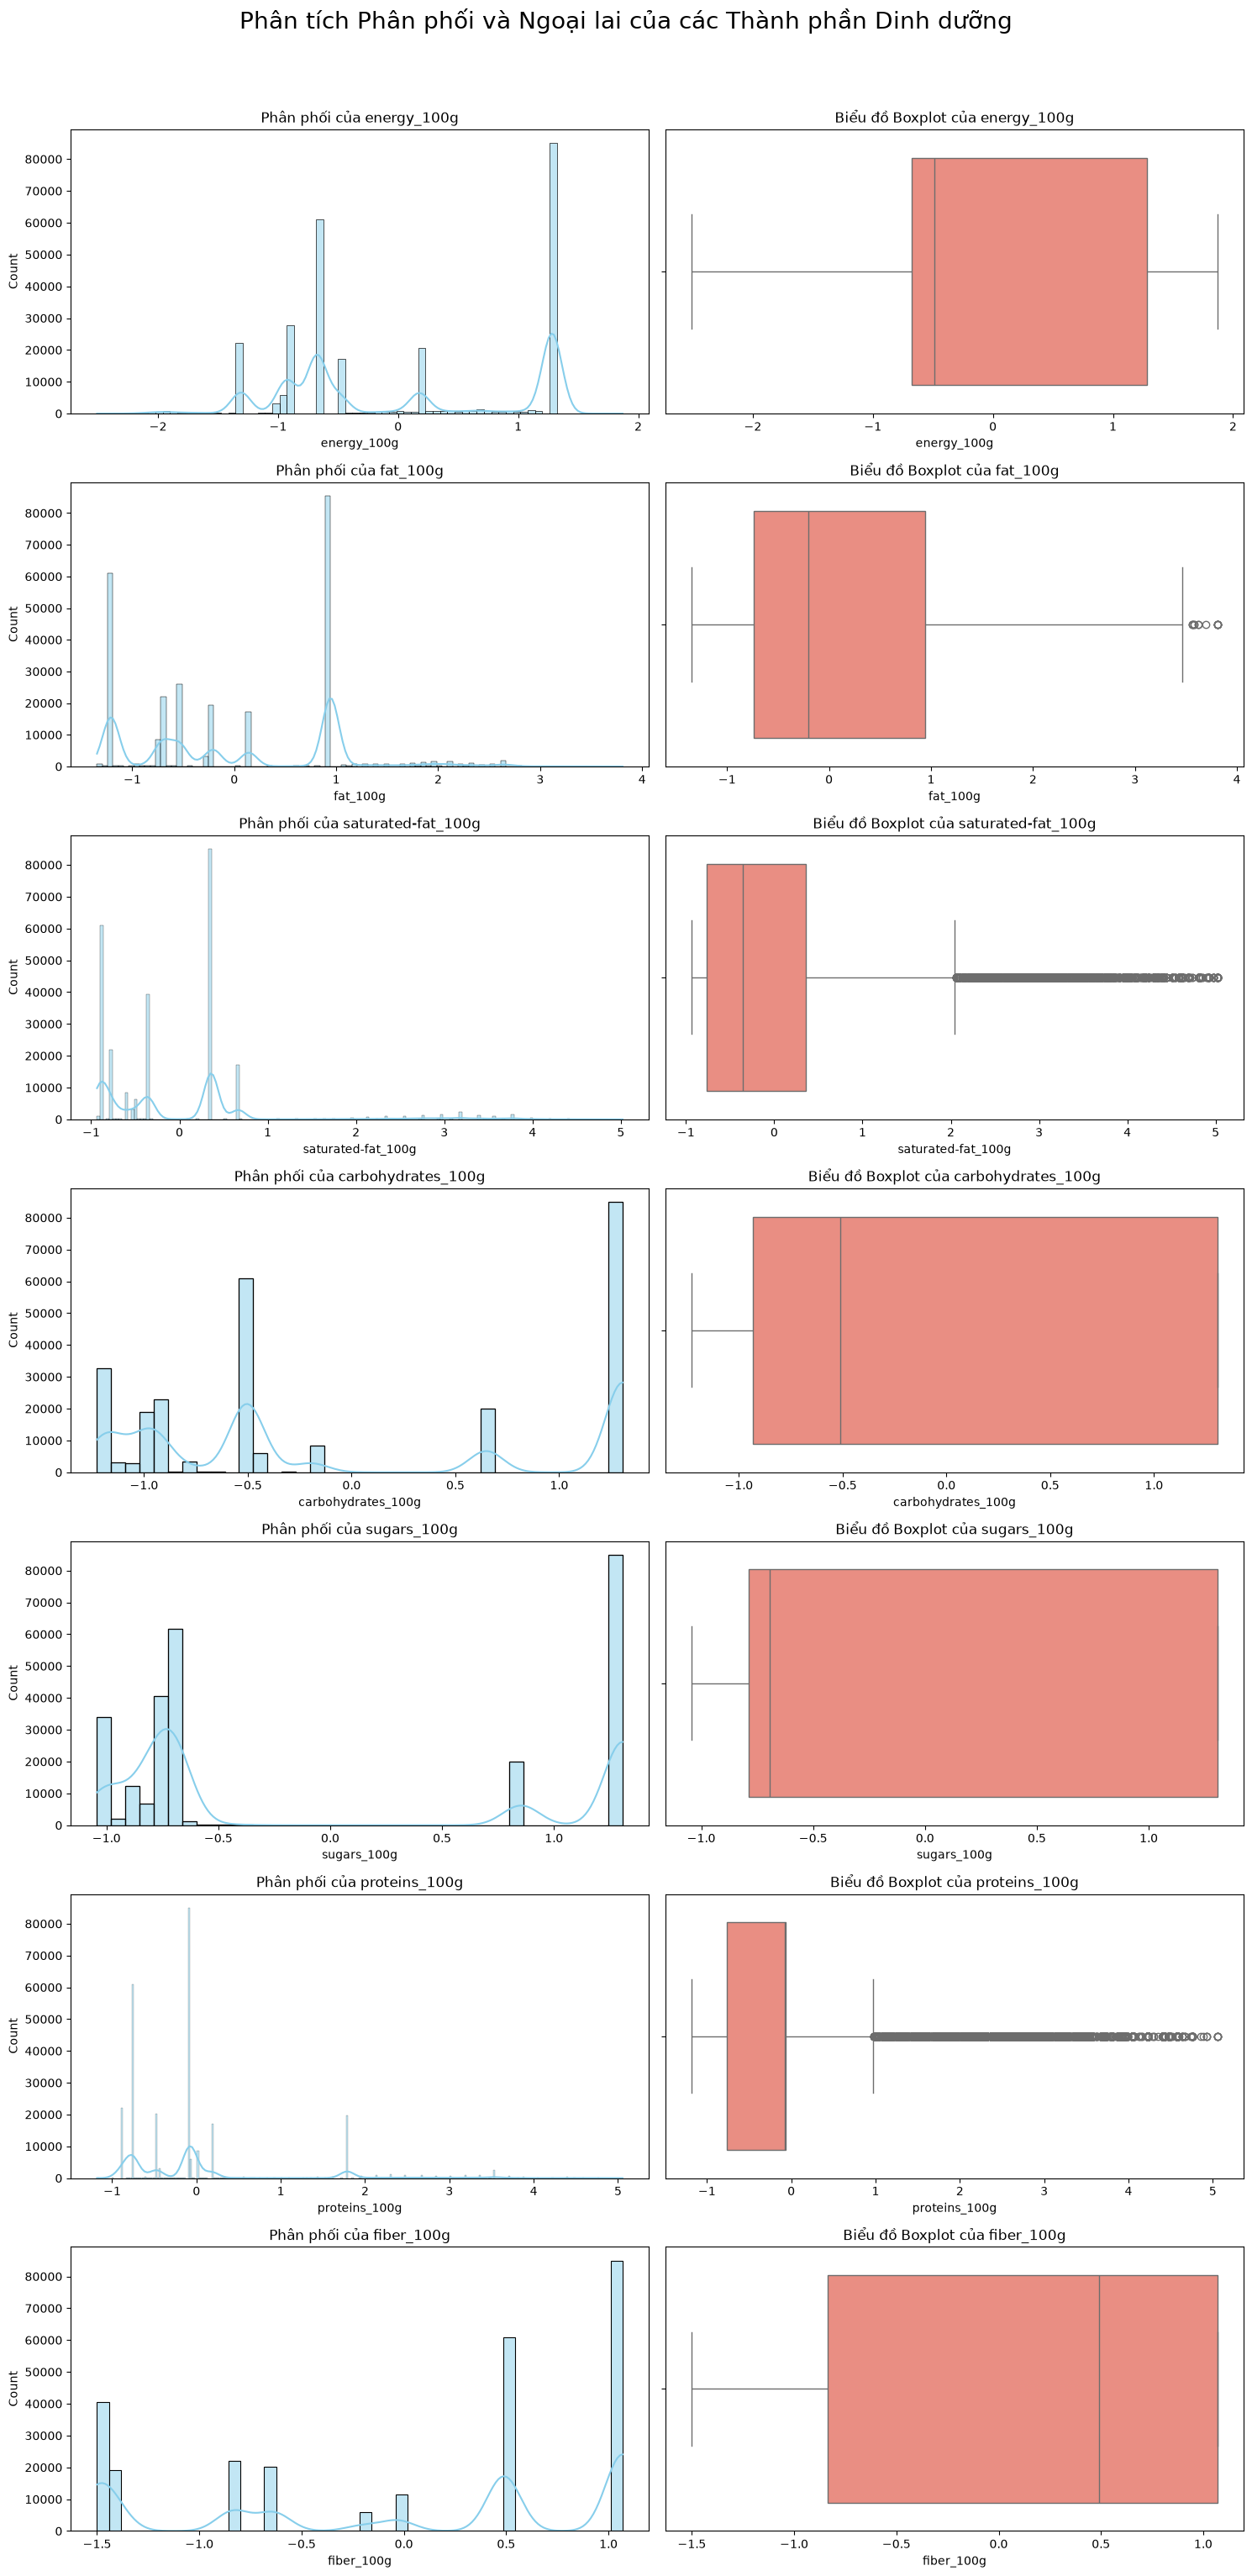

In [210]:


# Danh sách các cột cần vẽ
nutr_cols = ['energy_100g', 'fat_100g', 'saturated-fat_100g',
             'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'fiber_100g']

# Thiết lập lưới biểu đồ: 7 hàng, 2 cột (mỗi hàng cho 1 thành phần)
fig, axes = plt.subplots(nrows=len(nutr_cols), ncols=2, figsize=(15, 30))
fig.suptitle('Phân tích Phân phối và Ngoại lai của các Thành phần Dinh dưỡng', fontsize=20, y=1.02)

for i, col in enumerate(nutr_cols):
    # Vẽ Histogram + KDE (Cột bên trái)
    sns.histplot(df_validate[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Phân phối của {col}')

    # Vẽ Box plot (Cột bên phải)
    sns.boxplot(x=df_validate[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Biểu đồ Boxplot của {col}')

plt.tight_layout()
plt.show()

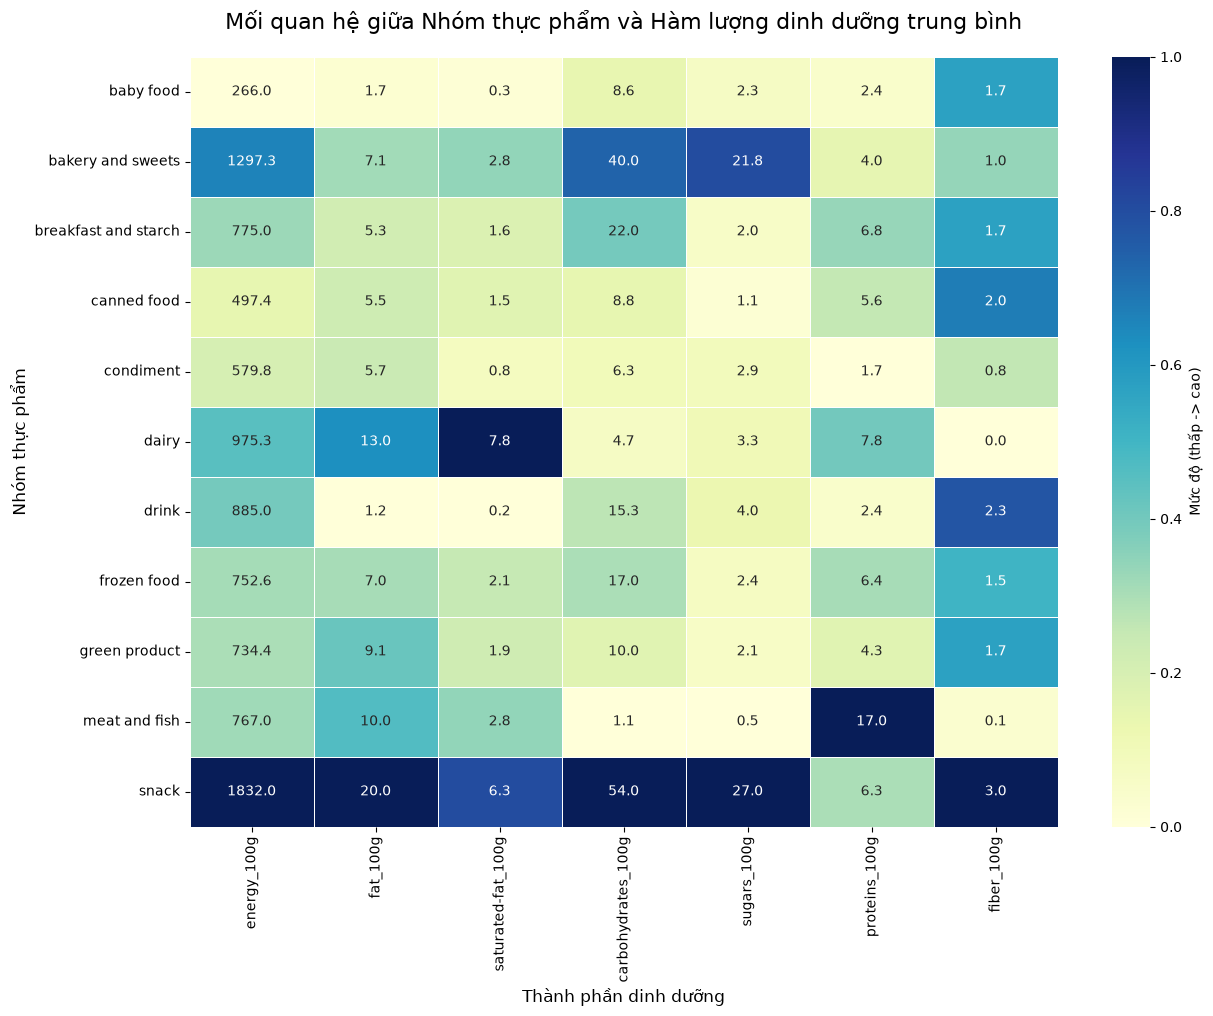

In [211]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Danh sách các cột dinh dưỡng
nutr_cols = ['energy_100g', 'fat_100g', 'saturated-fat_100g',
             'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'fiber_100g']

# 2. Tính giá trị trung bình theo từng nhóm
df_heatmap = df_categorize.groupby('general_category')[nutr_cols].median()

# 3. Chuẩn hóa Min-Max (để đưa về thang đo 0-1 giúp Heatmap hiển thị màu sắc đúng)
scaler = MinMaxScaler()
df_heatmap_scaled = pd.DataFrame(
    scaler.fit_transform(df_heatmap),
    columns=df_heatmap.columns,
    index=df_heatmap.index
)

# 4. Vẽ Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_heatmap_scaled,
    annot=df_heatmap.round(1), # Hiển thị giá trị thực (chưa chuẩn hóa) lên ô màu
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Mức độ (thấp -> cao)'}
)

plt.title('Mối quan hệ giữa Nhóm thực phẩm và Hàm lượng dinh dưỡng trung bình', fontsize=16, pad=20)
plt.xlabel('Thành phần dinh dưỡng', fontsize=12)
plt.ylabel('Nhóm thực phẩm', fontsize=12)
plt.show()

# VISUALIZATION

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15052\3012647567.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


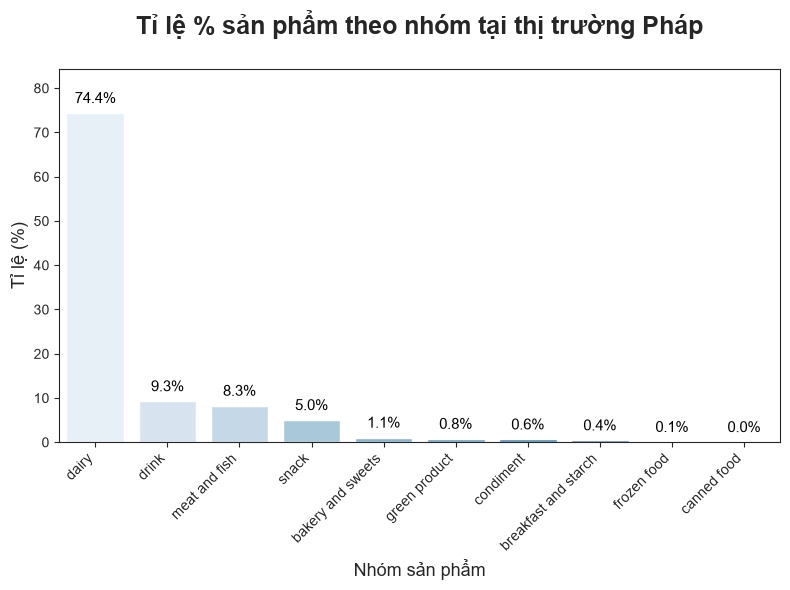

In [212]:


# 1. Lọc dữ liệu cho thị trường Pháp
df_france = df_categorize[df_categorize['countries_en'] == 'France'].copy()

# 2. Tính toán số lượng và tỉ lệ phần trăm
# normalize=True sẽ tính tỉ lệ (0 -> 1), sau đó nhân 100 để ra %
stats_france = df_france['general_category'].value_counts(normalize=True).reset_index()
stats_france.columns = ['general_category', 'percentage']
stats_france['percentage'] = stats_france['percentage'] * 100

# 3. Cấu hình giao diện biểu đồ
plt.figure(figsize=(8,6))
sns.set_style("ticks") # Thêm lưới cho dễ nhìn

# 4. Vẽ biểu đồ cột sử dụng barplot
ax = sns.barplot(
    data=stats_france,
    x='general_category',
    y='percentage',
    palette='Blues' # Màu sắc chuyên nghiệp
)

# 5. Thêm con số tỉ lệ % trên đầu mỗi cột
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=11,
        color='black'
    )

# 6. Tinh chỉnh tiêu đề và nhãn
plt.title('Tỉ lệ % sản phẩm theo nhóm tại thị trường Pháp', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Nhóm sản phẩm', fontsize=13)
plt.ylabel('Tỉ lệ (%)', fontsize=13)
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục X để không bị đè chữ
plt.ylim(0, stats_france['percentage'].max() + 10) # Tạo khoảng trống phía trên cho label

# 7. Hiển thị
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15052\1322340848.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


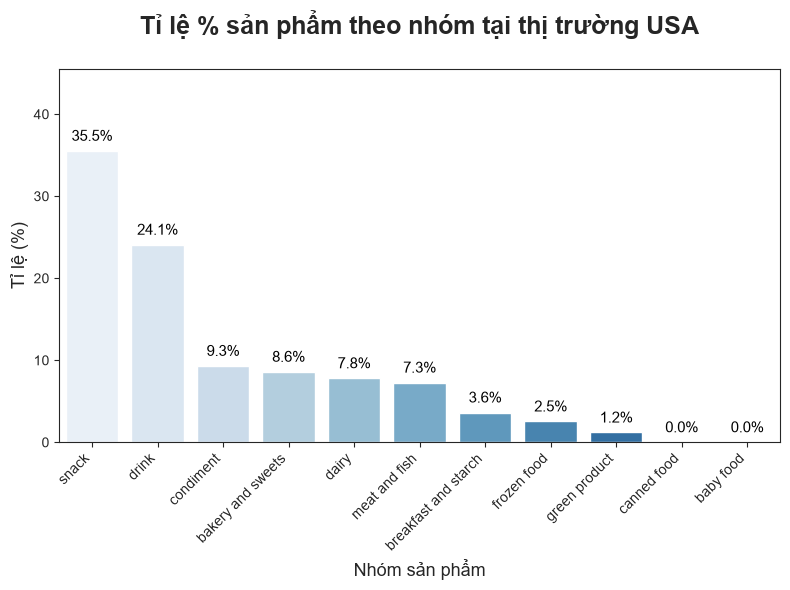

In [213]:
# 1. Lọc dữ liệu cho thị trường Pháp
df_usa = df_categorize[df_categorize['countries_en'] == 'United States'].copy()

# 2. Tính toán số lượng và tỉ lệ phần trăm
# normalize=True sẽ tính tỉ lệ (0 -> 1), sau đó nhân 100 để ra %
stats_usa = df_usa['general_category'].value_counts(normalize=True).reset_index()
stats_usa.columns = ['general_category', 'percentage']
stats_usa['percentage'] = stats_usa['percentage'] * 100

# 3. Cấu hình giao diện biểu đồ
plt.figure(figsize=(8,6))
sns.set_style("ticks") # Thêm lưới cho dễ nhìn

# 4. Vẽ biểu đồ cột sử dụng barplot
ax = sns.barplot(
    data=stats_usa,
    x='general_category',
    y='percentage',
    palette='Blues' # Màu sắc chuyên nghiệp
)

# 5. Thêm con số tỉ lệ % trên đầu mỗi cột
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=11,
        color='black'
    )

# 6. Tinh chỉnh tiêu đề và nhãn
plt.title('Tỉ lệ % sản phẩm theo nhóm tại thị trường USA', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Nhóm sản phẩm', fontsize=13)
plt.ylabel('Tỉ lệ (%)', fontsize=13)
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục X để không bị đè chữ
plt.ylim(0, stats_usa['percentage'].max() + 10) # Tạo khoảng trống phía trên cho label

# 7. Hiển thị
plt.tight_layout()
plt.show()

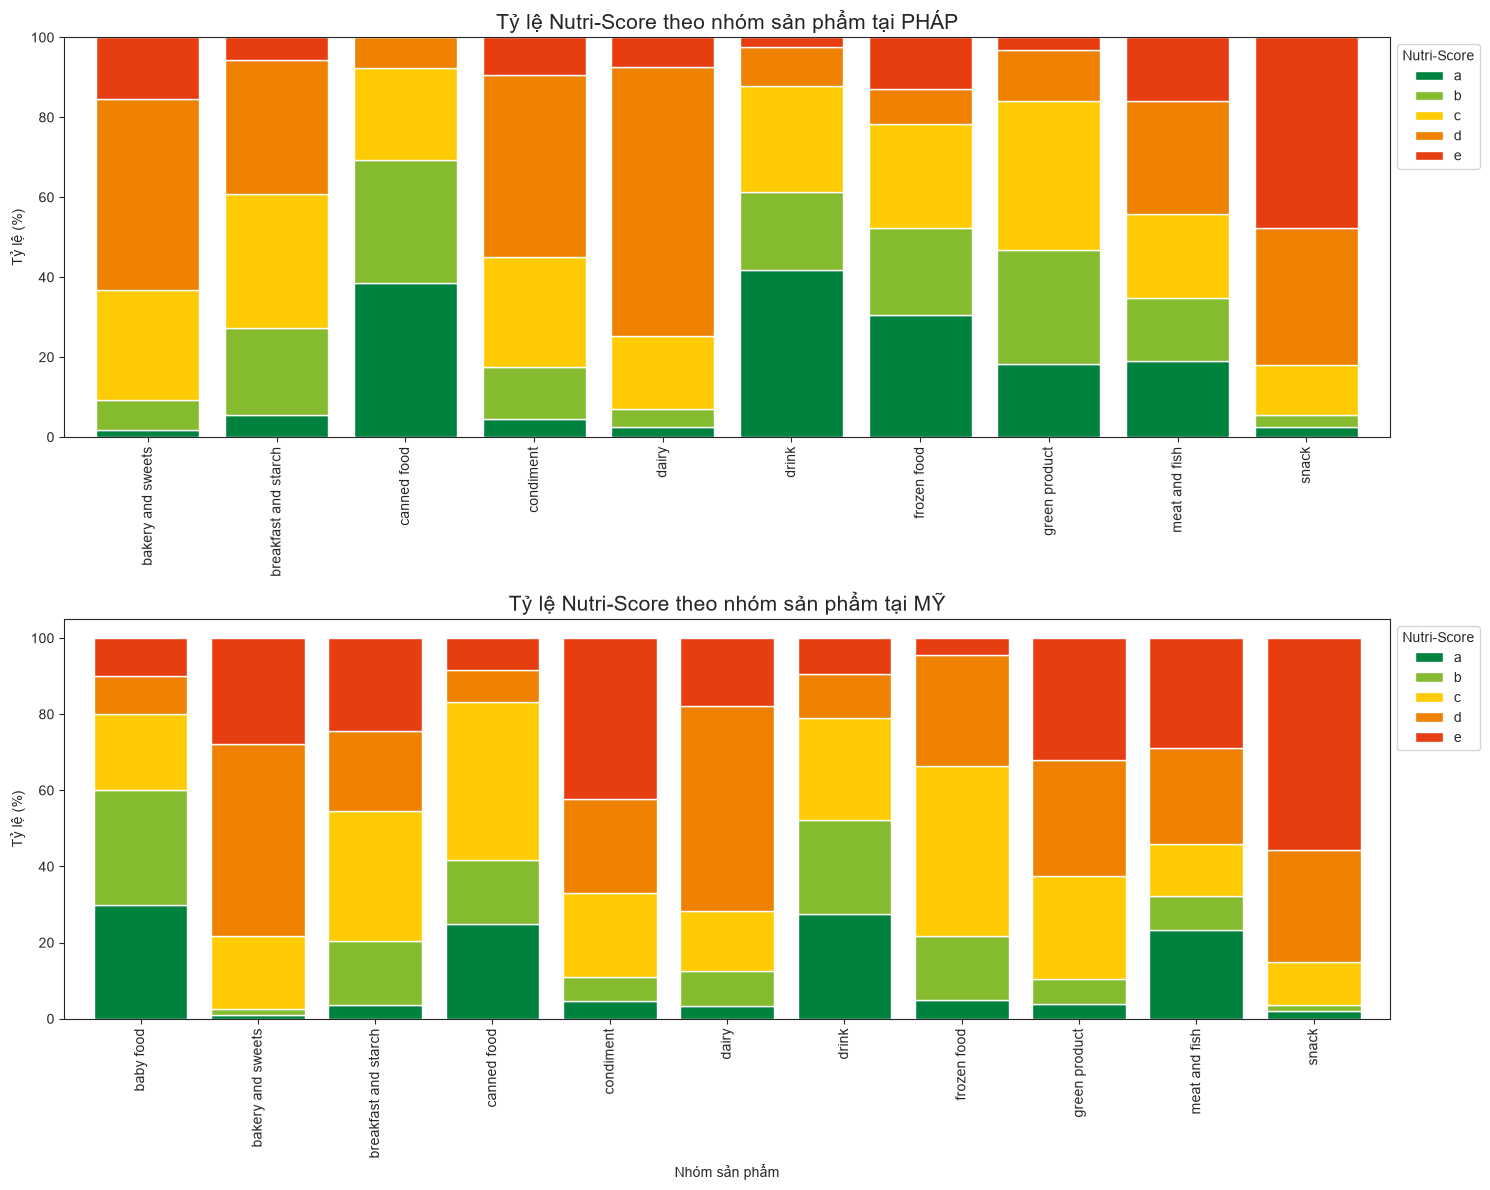

In [214]:


# 1. Chuẩn bị dữ liệu và màu sắc
nutri_colors = ['#00823F', '#85BB2F', '#FECB02', '#EE8100', '#E63E11']
countries = ['France', 'United States']

# Lọc và làm sạch dữ liệu
df_clean = df_categorize[df_categorize['countries_en'].isin(countries)].copy()
df_clean = df_clean.dropna(subset=['nutriscore_grade', 'general_category'])

# 2. Khởi tạo Subplots (2 hàng, 1 cột)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# --- BIỂU ĐỒ 1: FRANCE ---
df_fr = df_clean[df_clean['countries_en'] == 'France']
fr_counts = df_fr.groupby(['general_category', 'nutriscore_grade']).size().unstack(fill_value=0)
fr_pct = fr_counts.div(fr_counts.sum(axis=1), axis=0) * 100

fr_pct.plot(kind='bar', stacked=True, color=nutri_colors, ax=ax1, width=0.8)
ax1.set_title('Tỷ lệ Nutri-Score theo nhóm sản phẩm tại PHÁP', fontsize=15)
ax1.set_ylabel('Tỷ lệ (%)')
ax1.set_xlabel('')
ax1.grid(False) # Xóa dòng kẻ
ax1.legend(title='Nutri-Score', bbox_to_anchor=(1, 1))

# --- BIỂU ĐỒ 2: UNITED STATES ---
df_us = df_clean[df_clean['countries_en'] == 'United States']
us_counts = df_us.groupby(['general_category', 'nutriscore_grade']).size().unstack(fill_value=0)
us_pct = us_counts.div(us_counts.sum(axis=1), axis=0) * 100

us_pct.plot(kind='bar', stacked=True, color=nutri_colors, ax=ax2, width=0.8)
ax2.set_title('Tỷ lệ Nutri-Score theo nhóm sản phẩm tại MỸ', fontsize=15)
ax2.set_ylabel('Tỷ lệ (%)')
ax2.set_xlabel('Nhóm sản phẩm')
ax2.grid(False) # Xóa dòng kẻ
ax2.legend(title='Nutri-Score', bbox_to_anchor=(1, 1))

# 3. Tinh chỉnh khoảng cách và hiển thị
plt.tight_layout()
plt.show()

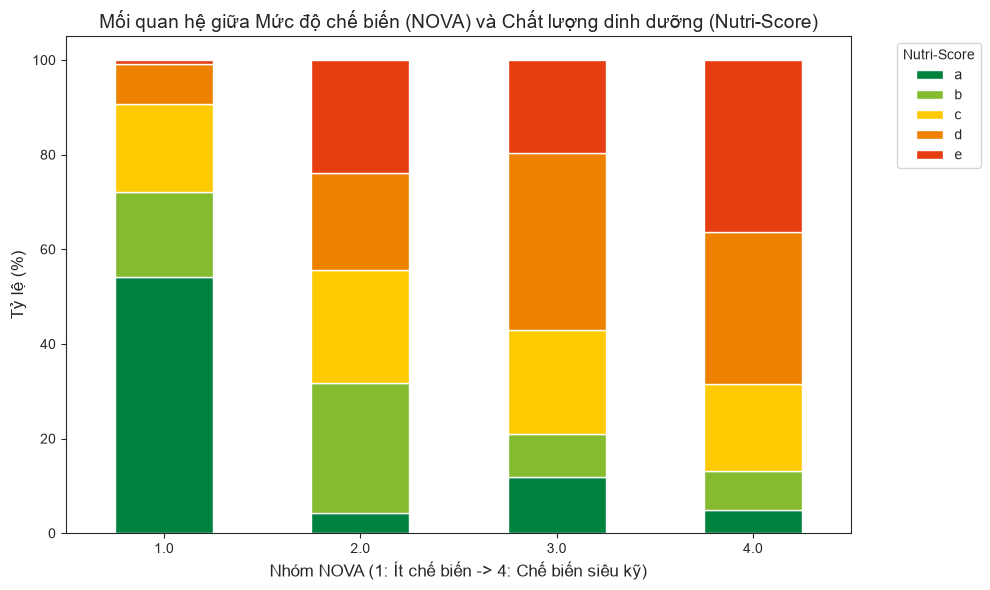

In [215]:
# 1. Chuẩn bị dữ liệu cho NOVA và Nutri-Score
df_nova_nutri = df_categorize.dropna(subset=['nova_group', 'nutriscore_grade']).copy()

# 2. Tính tỷ lệ 100%
nova_nutri_counts = df_nova_nutri.groupby(['nova_group', 'nutriscore_grade']).size().unstack(fill_value=0)
nova_nutri_pct = nova_nutri_counts.div(nova_nutri_counts.sum(axis=1), axis=0) * 100

# 3. Vẽ biểu đồ
ax = nova_nutri_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=nutri_colors)

# 4. Thêm chú thích
plt.title('Mối quan hệ giữa Mức độ chế biến (NOVA) và Chất lượng dinh dưỡng (Nutri-Score)', fontsize=14)
plt.xlabel('Nhóm NOVA (1: Ít chế biến -> 4: Chế biến siêu kỹ)', fontsize=12)
plt.ylabel('Tỷ lệ (%)', fontsize=12)
plt.legend(title='Nutri-Score', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

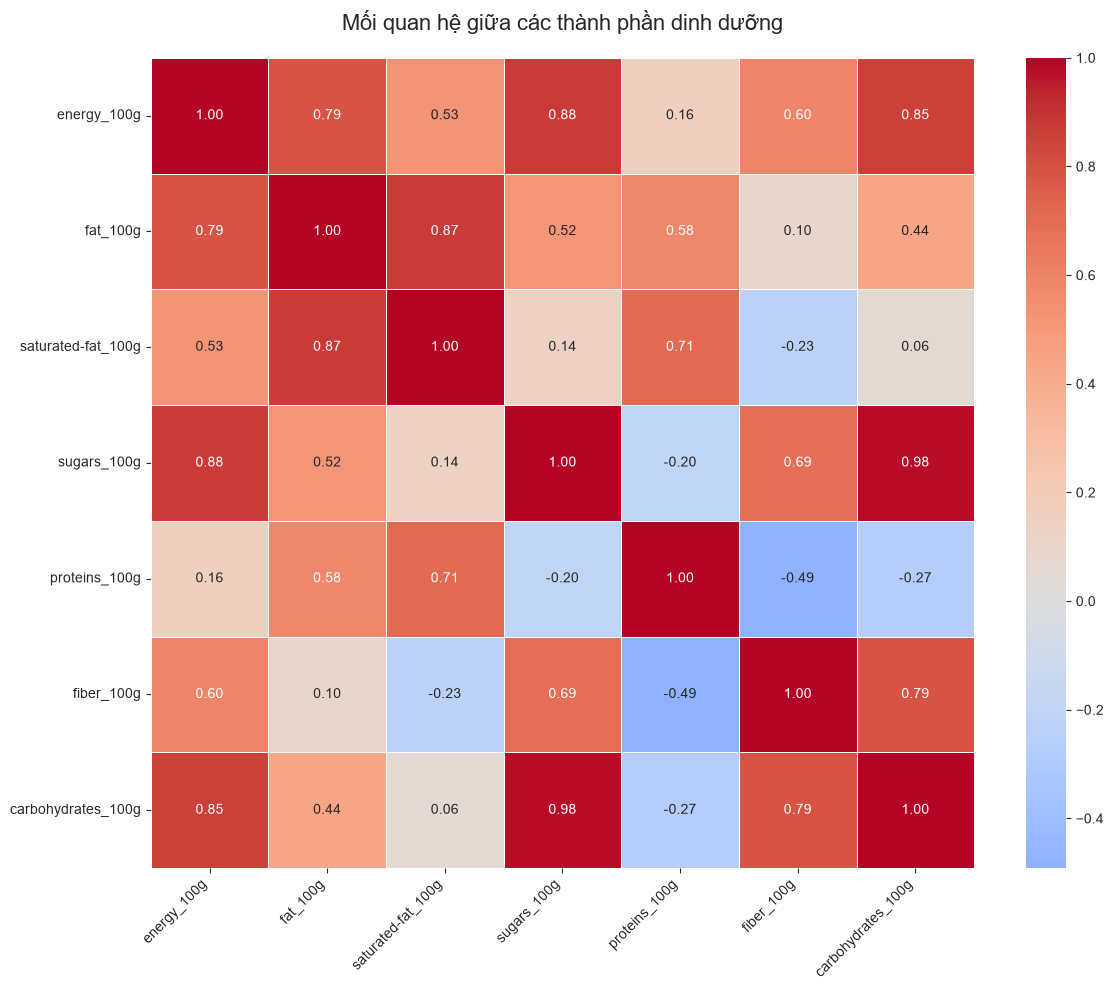

In [216]:

# 1. Chọn các cột cần tính tương quan
columns_of_interest = ['energy_100g', 'fat_100g', 'saturated-fat_100g', 'sugars_100g', 'proteins_100g', 'fiber_100g', 'carbohydrates_100g']

# Lưu ý: Hãy đảm bảo tên cột trong dataset của bạn khớp với danh sách này
# (Ví dụ: 'energy_100g' hay chỉ là 'energy')
df_corr = df_categorize[columns_of_interest].copy()

# 2. Tính toán ma trận tương quan Pearson
corr_matrix = df_corr.corr(method='pearson')

# 3. Vẽ biểu đồ Heatmap
plt.figure(figsize=(12, 10))

# Sử dụng bảng màu coolwarm để phân biệt rõ âm/dương
# annot=True để hiển thị con số cụ thể trên từng ô
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5,
            center=0)

# 4. Tinh chỉnh tiêu đề và nhãn
plt.title('Mối quan hệ giữa các thành phần dinh dưỡng', fontsize=16,pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 5. Hiển thị
plt.tight_layout()
plt.show()

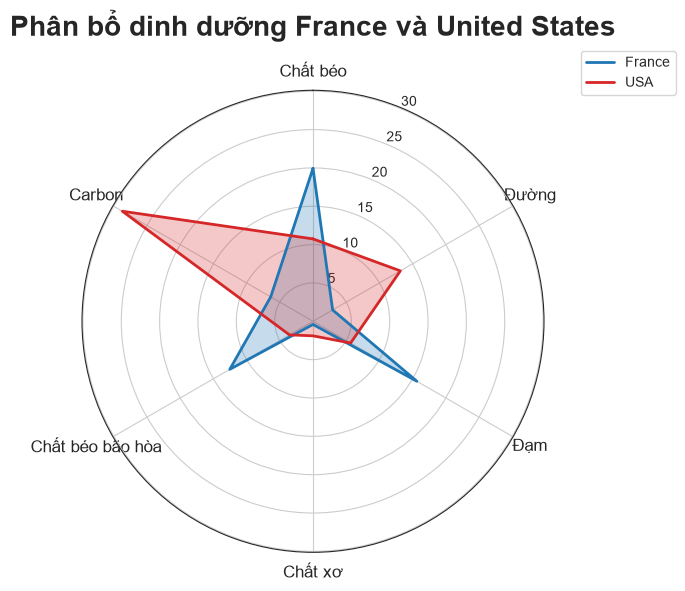

In [217]:
import numpy as np


# 1. Chọn các chỉ số dinh dưỡng để so sánh (nên cùng đơn vị gram/100g)
# Chúng ta không chọn 'energy' vì giá trị nó quá lớn so với các chất khác
categories = ['fat_100g', 'sugars_100g', 'proteins_100g', 'fiber_100g', 'saturated-fat_100g', 'carbohydrates_100g']
labels = ['Chất béo', 'Đường', 'Đạm', 'Chất xơ', 'Chất béo bão hòa', 'Carbon']
num_vars = len(categories)

# 2. Tính giá trị trung bình cho Pháp và Mỹ
stats_fr = df_categorize[df_categorize['countries_en'] == 'France'][categories].mean().tolist()
stats_us = df_categorize[df_categorize['countries_en'] == 'United States'][categories].mean().tolist()

# Để biểu đồ khép kín, ta cần lặp lại giá trị đầu tiên ở cuối danh sách
stats_fr += stats_fr[:1]
stats_us += stats_us[:1]

# 3. Tính toán góc cho từng trục
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Khép kín vòng tròn góc

# 4. Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Vẽ đường cho Pháp
ax.plot(angles, stats_fr, color='#1f77b4', linewidth=2, label='France')
ax.fill(angles, stats_fr, color='#1f77b4', alpha=0.25)

# Vẽ đường cho Mỹ
ax.plot(angles, stats_us, color='#d62728', linewidth=2, label='USA')
ax.fill(angles, stats_us, color='#d62728', alpha=0.25)

# 5. Tinh chỉnh nhãn và giao diện
ax.set_theta_offset(np.pi / 2) # Xoay trục đầu tiên lên đỉnh
ax.set_theta_direction(-1)     # Vẽ theo chiều kim đồng hồ

# Gán nhãn cho các trục
plt.xticks(angles[:-1], labels, fontsize=12)

# Tiêu đề và chú thích
plt.title('Phân bổ dinh dưỡng France và United States', size=20, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

Càng ở xa tâm biểu đồ, giá trị của thành phần đó càng cao. Ngược lại, điểm càng gần tâm thì giá trị càng thấp.

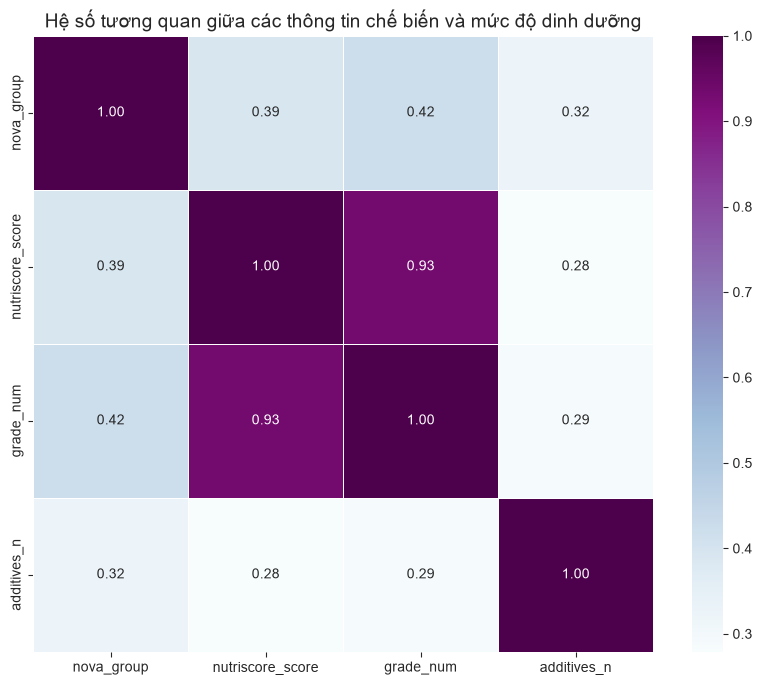

In [221]:
# Chuyển đổi grade sang số để tính tương quan
grade_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
df_categorize['grade_num'] = df_categorize['nutriscore_grade'].map(grade_map)

# Tính ma trận tương quan cho các cột số
corr_matrix = df_categorize[['nova_group', 'nutriscore_score', 'grade_num', 'additives_n']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='BuPu', fmt=".2f", linewidths=0.5)

plt.title('Hệ số tương quan giữa các thông tin chế biến và mức độ dinh dưỡng', fontsize=14)
plt.show()

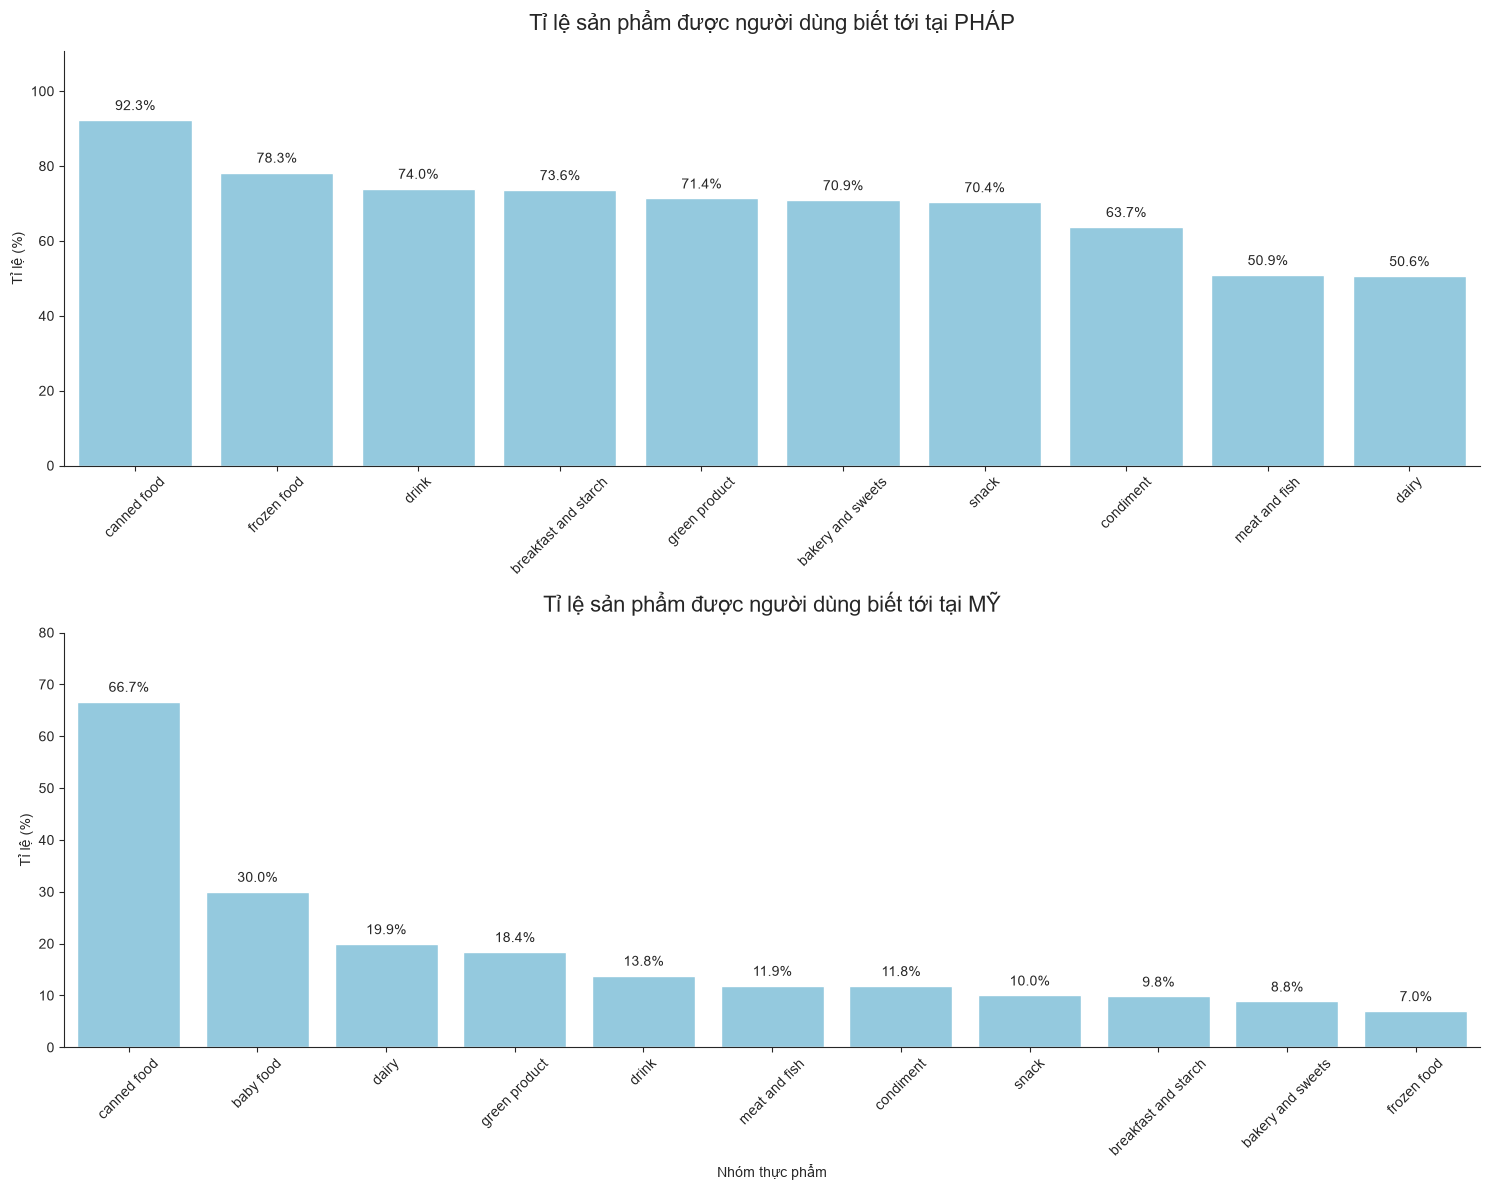

In [222]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu và tính toán tỉ lệ cho Pháp
df_fr = df_categorize[df_categorize['countries_en'] == 'France'].copy()
stats_fr = df_fr.groupby('general_category')['unique_scans_n'].mean().reset_index()
# Sửa lỗi: Lấy 'unique_scans_n' nhân 100 để tạo cột 'percentage'
stats_fr['percentage'] = stats_fr['unique_scans_n'] * 100
stats_fr = stats_fr.sort_values('percentage', ascending=False) # Sắp xếp giảm dần

# 2. Chuẩn bị dữ liệu và tính toán tỉ lệ cho Mỹ
df_us = df_categorize[df_categorize['countries_en'] == 'United States'].copy()
stats_us = df_us.groupby('general_category')['unique_scans_n'].mean().reset_index()
stats_us['percentage'] = stats_us['unique_scans_n'] * 100
stats_us = stats_us.sort_values('percentage', ascending=False) # Sắp xếp giảm dần

# 3. Khởi tạo Subplots (2 hàng, 1 cột)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
sns.set_style("white")

# Màu sắc tông Skyblue
color_fr = '#87CEEB' # DeepSkyBlue
color_us = '#87CEEB' # SkyBlue

# --- BIỂU ĐỒ 1: PHÁP ---
sns.barplot(data=stats_fr, x='general_category', y='percentage', color=color_fr, ax=ax1)
ax1.set_title('Tỉ lệ sản phẩm được người dùng biết tới tại PHÁP', fontsize=16, pad=15)
ax1.set_ylabel('Tỉ lệ (%)')
ax1.set_xlabel('')
ax1.set_ylim(0, stats_fr['percentage'].max() * 1.2) # Nới rộng trục Y để không mất số

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                fontsize=10)

# --- BIỂU ĐỒ 2: MỸ ---
sns.barplot(data=stats_us, x='general_category', y='percentage', color=color_us, ax=ax2)
ax2.set_title('Tỉ lệ sản phẩm được người dùng biết tới tại MỸ', fontsize=16, pad=15)
ax2.set_ylabel('Tỉ lệ (%)')
ax2.set_xlabel('Nhóm thực phẩm')
ax2.set_ylim(0, stats_us['percentage'].max() * 1.2)

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                fontsize=10)

# 4. Tinh chỉnh chung
for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45)
    sns.despine(ax=ax) # Xóa khung viền trên và phải

plt.tight_layout()
plt.show()

In [223]:
 # ### save dataset
df_validate.to_csv('df_final.csv', index=False)

In [224]:
df_categorize.to_csv('df_final_unscale.csv', index=False)